# Keystroke Dynamics Analysis & Model Development
## Phase 3: Authentication & Authorization Mechanism

---

### 📋 Project Overview

**Dataset**: Keystroke Dynamics Dataset  
**Purpose**: User identification and continuous authentication using typing patterns  
**Models**: User Identification (XGBoost) + Anomaly Detection (Isolation Forest)  
**Training Strategy**: Multi-class classification for user identification (Option A: top-K users only, e.g. K=50, to avoid memory/crash issues)  
**Evaluation Metrics**: Accuracy, Precision, Recall, F1-Score, FAR, FRR, EER  

---

### 🎯 Objectives

1. **Data Analysis**: Analyze keystroke dataset structure (this notebook loads first 50,000 files; full dataset ~168k)
2. **Feature Engineering**: Extract keystroke dynamics features (hold time, flight time, typing speed)
3. **Model Development**: Train user identification and anomaly detection models
4. **Evaluation**: Calculate FAR, FRR, EER metrics for authentication performance
5. **Deployment**: Save models for integration with self-aware bot

---

### 📊 Dataset Information

- **Location**: `datasets/Keystroke_data/`
- **Total Files**: ~168,595 TXT files (notebook loads first 50,000 via `MAX_FILES_TO_LOAD`)
- **Format**: Tab-separated values
- **Columns**: 
  - `PARTICIPANT_ID`: Unique user identifier
  - `TEST_SECTION_ID`: Session identifier
  - `PRESS_TIME`: Timestamp when key was pressed (milliseconds)
  - `RELEASE_TIME`: Timestamp when key was released (milliseconds)
  - `KEYCODE`: Key code identifier
  - `LETTER`: Character pressed
  - `SENTENCE`: Original sentence text
  - `USER_INPUT`: User input text
  - `KEYSTROKE_ID`: Unique keystroke identifier

---

### 📚 Notebook Structure

1. **Environment Setup** - Import libraries, configure paths
2. **Data Loading & Exploration** - Load keystroke files, analyze structure
3. **Feature Engineering** - Extract hold/flight/digraph/pause features (23 features)
4. **Data Preprocessing** - Filter users/sessions, scale, encode; random or temporal split
5. **Model Training - User Identification** - XGBoost (default), optional Random Forest, class weights
6. **Model Training - Anomaly Detection** - Isolation Forest (per user), optional One-Class SVM
7. **Model Evaluation** - Accuracy, FAR/FRR/EER, bootstrap CIs, confusion pairs, session-length analysis
8. **Model & Feature Experiments** - Feature ablation, optional SHAP
9. **Model Deployment** - Save all models and components to `models/`
10. **Summary & Inference Demo** - Results, limitations, load-and-predict demo

---


### ▶ How to run

Run all cells in order from top to bottom. **Approx. time:** 30–60 min for 50k files (data load + feature extraction + training). Ensure `datasets/Keystroke_data/` exists. After training, run the **Save All Model Files** cell so `models/` contains all `keystroke_*` artifacts.

## 1. Environment Setup

Import libraries, set paths, and configure plotting.


In [44]:
# Import Libraries
import os
import warnings
from pathlib import Path
import gc
import time
from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
import joblib
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
# ML Libraries
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc
)
import xgboost as xgb

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
print("Plotting style configured!")

# Suppress warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

# Display system info
print(f"CPU cores available: {cpu_count()}")
print(f"Will use multiprocessing for faster file loading")



Plotting style configured!
Libraries imported successfully!
CPU cores available: 24
Will use multiprocessing for faster file loading


## 2. Data Loading & Exploration

### 2.1. Configure Paths and Directories


In [45]:
# Define paths
DATA_DIR = Path('../datasets/Keystroke_data')
MODELS_DIR = Path('../models')

# Create models directory if it doesn't exist
MODELS_DIR.mkdir(exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")
print(f"Models directory exists: {MODELS_DIR.exists()}")


Data directory: ..\datasets\Keystroke_data
Models directory: ..\models
Data directory exists: True
Models directory exists: True


### Configuration & Constants

Central place for random seed, test size, and environment info for reproducibility.

In [46]:
# Reproducibility and run config
RANDOM_STATE = 42
TEST_SIZE = 0.2
print("Run configuration:")
print(f"  RANDOM_STATE = {RANDOM_STATE}")
print(f"  TEST_SIZE = {TEST_SIZE}")
print("\nEnvironment:")
print(f"  Python: {__import__('sys').version.split()[0]}")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  sklearn: {__import__('sklearn').__version__}")
print(f"  xgboost: {xgb.__version__}")

Run configuration:
  RANDOM_STATE = 42
  TEST_SIZE = 0.2

Environment:
  Python: 3.11.0
  pandas: 2.2.2
  numpy: 1.26.4
  sklearn: 1.5.1
  xgboost: 2.1.1


### 2.2. List Available Keystroke Files

Get list of all keystroke data files in the dataset directory.


In [47]:
# Get list of keystroke files (limit to 50,000 for training)
MAX_FILES_TO_LOAD = 10000
all_keystroke_files = list(DATA_DIR.glob('*.txt'))
keystroke_files = all_keystroke_files[:MAX_FILES_TO_LOAD]
print(f"Total keystroke files available: {len(all_keystroke_files):,}")
print(f"Loading first {len(keystroke_files):,} files (MAX_FILES_TO_LOAD = {MAX_FILES_TO_LOAD:,})")
print(f"\nFirst 5 files:")
for f in keystroke_files[:5]:
    print(f"  - {f.name}")
print(f"\nLast 5 files:")
for f in keystroke_files[-5:]:
    print(f"  - {f.name}")


Exception ignored in: <function tqdm.__del__ at 0x0000024655586980>
Traceback (most recent call last):
  File "C:\Users\prana\AppData\Roaming\Python\Python311\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\prana\AppData\Roaming\Python\Python311\site-packages\tqdm\notebook.py", line 273, in close
    if self.disable:
       ^^^^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disable'


Total keystroke files available: 168,595
Loading first 10,000 files (MAX_FILES_TO_LOAD = 10,000)

First 5 files:
  - 100001_keystrokes.txt
  - 100003_keystrokes.txt
  - 100007_keystrokes.txt
  - 100008_keystrokes.txt
  - 100013_keystrokes.txt

Last 5 files:
  - 127267_keystrokes.txt
  - 127269_keystrokes.txt
  - 127271_keystrokes.txt
  - 127272_keystrokes.txt
  - 127274_keystrokes.txt


### 2.3. Examine Sample File Structure

Load one sample file to inspect columns and format.


In [48]:
# Load a sample file to understand structure
sample_file = keystroke_files[0]
print(f"Loading sample file: {sample_file.name}")

sample_df = pd.read_csv(sample_file, sep='\t')
print(f"\nSample data shape: {sample_df.shape}")
print(f"\nColumns: {list(sample_df.columns)}")
print(f"\nFirst few rows:")
print(sample_df.head(10))


Loading sample file: 100001_keystrokes.txt

Sample data shape: (658, 9)

Columns: ['PARTICIPANT_ID', 'TEST_SECTION_ID', 'SENTENCE', 'USER_INPUT', 'KEYSTROKE_ID', 'PRESS_TIME', 'RELEASE_TIME', 'LETTER', 'KEYCODE']

First few rows:
   PARTICIPANT_ID  TEST_SECTION_ID  \
0          100001          1090979   
1          100001          1090979   
2          100001          1090979   
3          100001          1090979   
4          100001          1090979   
5          100001          1090979   
6          100001          1090979   
7          100001          1090979   
8          100001          1090979   
9          100001          1090979   

                                      SENTENCE  \
0  Was wondering if you and Natalie connected?   
1  Was wondering if you and Natalie connected?   
2  Was wondering if you and Natalie connected?   
3  Was wondering if you and Natalie connected?   
4  Was wondering if you and Natalie connected?   
5  Was wondering if you and Natalie connected?   
6

### 2.4. Analyze Sample Data

Check data types, statistics, and unique values in the sample file.


In [49]:
# Analyze data structure
print("Data Info:")
print(sample_df.info())
print("\n" + "="*50)
print("\nData Statistics:")
print(sample_df.describe())
print("\n" + "="*50)
print("\nUnique values:")
print(f"Unique PARTICIPANT_IDs: {sample_df['PARTICIPANT_ID'].nunique()}")
print(f"Unique TEST_SECTION_IDs: {sample_df['TEST_SECTION_ID'].nunique()}")
print(f"Unique KEYCODEs: {sample_df['KEYCODE'].nunique()}")
print(f"\nSample timing data:")
print(f"  Press time range: {sample_df['PRESS_TIME'].min()} - {sample_df['PRESS_TIME'].max()}")
print(f"  Release time range: {sample_df['RELEASE_TIME'].min()} - {sample_df['RELEASE_TIME'].max()}")


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   PARTICIPANT_ID   658 non-null    int64 
 1   TEST_SECTION_ID  658 non-null    int64 
 2   SENTENCE         658 non-null    object
 3   USER_INPUT       658 non-null    object
 4   KEYSTROKE_ID     658 non-null    int64 
 5   PRESS_TIME       658 non-null    int64 
 6   RELEASE_TIME     658 non-null    int64 
 7   LETTER           658 non-null    object
 8   KEYCODE          658 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 46.4+ KB
None


Data Statistics:
       PARTICIPANT_ID  TEST_SECTION_ID  KEYSTROKE_ID    PRESS_TIME  \
count           658.0     6.580000e+02  6.580000e+02  6.580000e+02   
mean         100001.0     1.091085e+06  5.189667e+07  1.473275e+12   
std               0.0     6.332375e+01  3.071306e+03  3.739477e+04   
min          100001.0     1.090979e

### 2.5. Load ALL Dataset Files with Multiprocessing

**Configuration:**
- **Loading**: First `MAX_FILES_TO_LOAD` files (default 50,000; full dataset ~168k)
- **Method**: Multiprocessing for parallel file loading
- **Cores Used**: All available CPU cores for maximum speed

**Note**: This will load all available keystroke data files using parallel processing for faster execution. The process will show progress updates as files are loaded.


In [50]:
# Load keystroke files (only the count in keystroke_files - run cell above to set MAX_FILES_TO_LOAD=50000)
print("="*70)
print("Loading Keystroke Data Files with Checkpoint Support")
print("="*70)
print(f"\n📁 Will load ONLY {len(keystroke_files):,} files (from keystroke_files). Checkpoints keyed to this count.")

# Setup checkpoint directory
CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Checkpoint file paths
BATCH_CHECKPOINT_DIR = CHECKPOINT_DIR / f'data_loading_batches_{len(keystroke_files)}'
BATCH_CHECKPOINT_DIR.mkdir(exist_ok=True)
FINAL_DF_CHECKPOINT = CHECKPOINT_DIR / f'df_all_loaded_{len(keystroke_files)}.pkl'
LOADING_STATE_FILE = CHECKPOINT_DIR / f'loading_state_{len(keystroke_files)}.json'

print(f"\nCheckpoint directory: {CHECKPOINT_DIR}")
print(f"Batch checkpoints: {BATCH_CHECKPOINT_DIR}")
print(f"Final dataframe checkpoint: {FINAL_DF_CHECKPOINT}")

# Check if final dataframe already exists
if FINAL_DF_CHECKPOINT.exists():
    print("\n" + "="*70)
    print("✓ Found existing complete dataset checkpoint!")
    print("="*70)
    print(f"Loading from checkpoint: {FINAL_DF_CHECKPOINT}")
    
    try:
        df_all = joblib.load(FINAL_DF_CHECKPOINT)
        print(f"\n✓ Successfully loaded checkpoint!")
        print(f"  Total records: {len(df_all):,}")
        print(f"  Total unique participants: {df_all['PARTICIPANT_ID'].nunique():,}")
        print(f"  Total unique sessions: {df_all['TEST_SECTION_ID'].nunique():,}")
        print(f"  Memory usage: {df_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"\n📋 Columns: {list(df_all.columns)}")
        print(f"  Data shape: {df_all.shape}")
        print("\n💡 To reload from files, delete the checkpoint file and rerun this cell.")
    except Exception as e:
        print(f"\n⚠ Error loading checkpoint: {e}")
        print("Will proceed with loading from files...")
        df_all = None
else:
    df_all = None

# If checkpoint doesn't exist or failed to load, proceed with file loading
if df_all is None:
    USE_MULTIPROCESSING = len(keystroke_files) > 15000  # Sequential for <=15k so progress starts immediately (avoids Pool spawn on Windows)
    if USE_MULTIPROCESSING:
        print(f"\nLoading ALL {len(keystroke_files):,} files using multiprocessing...")
    else:
        print(f"\nLoading {len(keystroke_files):,} files sequentially (no Pool spawn — progress starts immediately)...")
    
    # Function to load a single file with error handling
    def load_keystroke_file(file_path):
        """
        Load a single keystroke file with robust error handling.
        Returns (DataFrame, error_info) tuple where error_info is None if successful.
        """
        error_info = None
        
        # Check if file exists and is readable
        try:
            if not file_path.exists() or file_path.stat().st_size == 0:
                return None, {'type': 'empty_file', 'file': str(file_path.name)}
        except Exception as e:
            return None, {'type': 'file_access', 'file': str(file_path.name), 'error': str(e)}
        
        # Try different encodings and parsing strategies
        encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1', 'utf-16', 'utf-16-le', 'utf-16-be']
        separators = ['\t', ',', ';', ' ']
        
        for encoding in encodings:
            for sep in separators:
                try:
                    # Strategy 1: Standard read with error handling
                    df = pd.read_csv(
                        file_path, 
                        sep=sep, 
                        encoding=encoding, 
                        on_bad_lines='skip',
                        low_memory=False,
                        engine='python',  # More tolerant parser
                        skipinitialspace=True,
                        na_values=['', 'NA', 'N/A', 'null', 'NULL', 'None']
                    )
                    
                    # Check if DataFrame is valid and has expected columns
                    if df is not None and len(df) > 0:
                        # Verify it has the expected structure (at least some expected columns)
                        expected_cols = ['PARTICIPANT_ID', 'TEST_SECTION_ID', 'PRESS_TIME', 'RELEASE_TIME']
                        if any(col in df.columns for col in expected_cols):
                            return df, None
                        # If no expected columns but has data, might be wrong separator
                        elif len(df.columns) > 0:
                            continue  # Try next separator
                    
                    # Empty DataFrame - try next strategy
                    if len(df) == 0:
                        continue
                        
                except UnicodeDecodeError:
                    continue  # Try next encoding
                except pd.errors.ParserError as e:
                    # Try with more lenient parsing
                    try:
                        df = pd.read_csv(
                            file_path,
                            sep=sep,
                            encoding=encoding,
                            on_bad_lines='skip',
                            low_memory=False,
                            engine='python',
                            skipinitialspace=True,
                            na_values=['', 'NA', 'N/A', 'null', 'NULL', 'None']
                        )
                        if df is not None and len(df) > 0:
                            expected_cols = ['PARTICIPANT_ID', 'TEST_SECTION_ID', 'PRESS_TIME', 'RELEASE_TIME']
                            if any(col in df.columns for col in expected_cols):
                                return df, None
                    except:
                        continue
                except Exception as e:
                    error_info = {'type': 'parse_error', 'file': str(file_path.name), 'error': str(e)[:100], 'encoding': encoding, 'sep': repr(sep)}
                    continue
        
        # If all strategies failed, try reading as text and manual parsing
        try:
            for encoding in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    with open(file_path, 'r', encoding=encoding, errors='ignore') as f:
                        lines = f.readlines()
                        if len(lines) > 1:  # Has header + at least one data row
                            # Try to parse manually
                            header = lines[0].strip().split('\t')
                            if len(header) > 1:
                                data_rows = []
                                for line in lines[1:]:
                                    if line.strip():
                                        parts = line.strip().split('\t')
                                        if len(parts) == len(header):
                                            data_rows.append(parts)
                                
                                if len(data_rows) > 0:
                                    df = pd.DataFrame(data_rows, columns=header)
                                    # Try to convert numeric columns
                                    for col in df.columns:
                                        if 'TIME' in col or 'ID' in col:
                                            try:
                                                df[col] = pd.to_numeric(df[col], errors='coerce')
                                            except:
                                                pass
                                    if len(df) > 0:
                                        return df, None
                except:
                    continue
        except:
            pass
    
        # All strategies failed
        return None, error_info or {'type': 'all_strategies_failed', 'file': str(file_path.name)}
    
    # Check for existing loading state (resume from last batch)
    start_batch = 0
    dataframes = []
    error_log = []
    failed_files = []
    
    if LOADING_STATE_FILE.exists():
        try:
            with open(LOADING_STATE_FILE, 'r') as f:
                state = json.load(f)
                start_batch = state.get('last_completed_batch', 0) + 1
                print(f"\n📂 Found previous loading state. Resuming from batch {start_batch}...")
                print(f"  Previously loaded batches: {start_batch}")
                
                # Load existing batch checkpoints
                for batch_num in range(start_batch):
                    batch_checkpoint = BATCH_CHECKPOINT_DIR / f'batch_{batch_num:06d}.pkl'
                    if batch_checkpoint.exists():
                        try:
                            batch_data = joblib.load(batch_checkpoint)
                            dataframes.extend(batch_data.get('dataframes', []))
                            error_log.extend(batch_data.get('error_log', []))
                            failed_files.extend(batch_data.get('failed_files', []))
                        except Exception as e:
                            print(f"  ⚠ Warning: Could not load batch {batch_num} checkpoint: {e}")
        except Exception as e:
            print(f"  ⚠ Warning: Could not load state file: {e}")
            print("  Starting fresh...")
            start_batch = 0
    
    # Start timing
    start_time = time.time()
    total_files = len(keystroke_files)
    # Use 4 workers for 15k–40k files (faster spawn); full cores for 40k+
    num_cores = min(4, cpu_count()) if (USE_MULTIPROCESSING and total_files <= 40000) else cpu_count() if USE_MULTIPROCESSING else 1
    if USE_MULTIPROCESSING:
        print(f"Using {num_cores} CPU cores for parallel processing")
    batch_size = 5000  # Process 5000 files at a time (multiprocessing path)
    
    if start_batch > 0:
        print(f"\nResuming: Processing files in batches of {batch_size}...")
        print(f"Starting from batch {start_batch} (batch 0 to {start_batch-1} already loaded)")
    elif not USE_MULTIPROCESSING:
        print(f"\nProcessing {total_files:,} files (sequential, no multiprocessing)...")
    else:
        print(f"\nProcessing files in batches of {batch_size}...")
    
    if not USE_MULTIPROCESSING:
        # Fast path: load sequentially (no Pool spawn — 100 files finish in seconds)
        batch_results = []
        for f in tqdm(keystroke_files, desc="Files", unit="", ncols=95, bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):
            batch_results.append(load_keystroke_file(f))
        batch_files = keystroke_files
        batch_dfs = []; batch_error_log = []; batch_failed_files = []
        for i, (df, error_info) in enumerate(batch_results):
            if df is not None and len(df) > 0:
                batch_dfs.append(df)
            else:
                batch_failed_files.append(batch_files[i].name)
                if error_info:
                    batch_error_log.append(error_info)
        dataframes = batch_dfs
        error_log = batch_error_log
        failed_files = batch_failed_files
        batch_num = 0
        batch_checkpoint = BATCH_CHECKPOINT_DIR / 'batch_000000.pkl'
        joblib.dump({'batch_num': 0, 'dataframes': batch_dfs, 'error_log': batch_error_log, 'failed_files': batch_failed_files, 'timestamp': datetime.now().isoformat()}, batch_checkpoint)
        with open(LOADING_STATE_FILE, 'w') as fp:
            json.dump({'last_completed_batch': 0, 'total_files': total_files, 'total_batches': 1, 'last_update': datetime.now().isoformat()}, fp, indent=2)
    else:
        # Multiprocessing path: batches with Pool
        total_batches = (total_files + batch_size - 1) // batch_size
        files_done_before = start_batch * batch_size
        with tqdm(total=total_files, initial=files_done_before, desc="Files", unit="", mininterval=0.5, maxinterval=2.0, ncols=95, bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]") as pbar:
            for batch_num in range(start_batch, total_batches):
                batch_start = batch_num * batch_size
                batch_end = min(batch_start + batch_size, total_files)
                batch_files = keystroke_files[batch_start:batch_end]
                batch_results = []
                with Pool(processes=num_cores) as pool:
                    for result in pool.imap(load_keystroke_file, batch_files):
                        batch_results.append(result)
                        pbar.update(1)
                
                # Process results - now returns (df, error_info) tuples
                batch_dfs = []
                batch_error_log = []
                batch_failed_files = []
                for i, (df, error_info) in enumerate(batch_results):
                    if df is not None and len(df) > 0:
                        batch_dfs.append(df)
                    else:
                        batch_failed_files.append(batch_files[i].name)
                        if error_info:
                            batch_error_log.append(error_info)
                dataframes.extend(batch_dfs)
                error_log.extend(batch_error_log)
                failed_files.extend(batch_failed_files)
                batch_checkpoint = BATCH_CHECKPOINT_DIR / f'batch_{batch_num:06d}.pkl'
                joblib.dump({'batch_num': batch_num, 'batch_start': batch_start, 'batch_end': batch_end, 'dataframes': batch_dfs, 'error_log': batch_error_log, 'failed_files': batch_failed_files, 'timestamp': datetime.now().isoformat()}, batch_checkpoint)
                with open(LOADING_STATE_FILE, 'w') as f:
                    json.dump({'last_completed_batch': batch_num, 'total_files': total_files, 'total_batches': total_batches, 'last_update': datetime.now().isoformat()}, f, indent=2)
                elapsed = time.time() - start_time
                progress = (batch_end / total_files) * 100
                rate = batch_end / elapsed if elapsed > 0 else 0
                eta = (total_files - batch_end) / rate if rate > 0 else 0
                success_rate = (len(batch_dfs) / len(batch_files)) * 100 if len(batch_files) > 0 else 0
                pbar.set_postfix_str(f"B{batch_num+1}/{total_batches} ETA{eta/60:.0f}m OK{success_rate:.0f}%", refresh=False)
    
    # Combine all dataframes
    print("\n" + "="*70)
    print("Combining all dataframes...")
    print("="*70)
    
    if len(dataframes) > 0:
        df_all = pd.concat(dataframes, ignore_index=True)
        
        # Save final dataframe checkpoint
        print(f"\n💾 Saving final dataframe checkpoint...")
        joblib.dump(df_all, FINAL_DF_CHECKPOINT)
        print(f"  ✓ Saved to: {FINAL_DF_CHECKPOINT}")
        
        # Clean up batch checkpoints and state file (optional - comment out if you want to keep them)
        print(f"\n🧹 Cleaning up batch checkpoints...")
        for batch_checkpoint in BATCH_CHECKPOINT_DIR.glob('batch_*.pkl'):
            try:
                batch_checkpoint.unlink()
            except:
                pass
        if LOADING_STATE_FILE.exists():
            try:
                LOADING_STATE_FILE.unlink()
            except:
                pass
        print(f"  ✓ Cleaned up batch checkpoints")
    else:
        df_all = pd.DataFrame()  # Empty DataFrame if no files loaded
        print("⚠ WARNING: No files were successfully loaded!")
    
    elapsed_total = time.time() - start_time
    success_rate = (len(dataframes) / total_files) * 100 if total_files > 0 else 0
    
    print(f"\n{'='*70}")
    print(f"✓ Loading complete!")
    print(f"{'='*70}")
    print(f"\n📊 Summary:")
    print(f"  Total time: {elapsed_total/60:.2f} minutes ({elapsed_total:.1f} seconds)")
    print(f"  Files successfully loaded: {len(dataframes):,}/{total_files:,} ({success_rate:.1f}%)")
    print(f"  Failed files: {len(failed_files):,} ({100-success_rate:.1f}%)")
    
    if len(df_all) > 0:
        print(f"\n📈 Data Statistics:")
        print(f"  Total records loaded: {len(df_all):,}")
        print(f"  Total unique participants: {df_all['PARTICIPANT_ID'].nunique():,}")
        print(f"  Total unique sessions: {df_all['TEST_SECTION_ID'].nunique():,}")
        if len(dataframes) > 0:
            print(f"  Average records per file: {len(df_all)/len(dataframes):.0f}")
        
        # Show column info
        print(f"\n📋 Columns loaded: {list(df_all.columns)}")
        print(f"  Data shape: {df_all.shape}")
        print(f"  Memory usage: {df_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    else:
        print(f"\n⚠ WARNING: No data was loaded. Please check the error log below.")
    
    # Error analysis
    if len(error_log) > 0:
        print(f"\n🔍 Error Analysis:")
        error_types = {}
        for err in error_log:
            err_type = err.get('type', 'unknown')
            error_types[err_type] = error_types.get(err_type, 0) + 1
        
        print(f"  Error breakdown:")
        for err_type, count in sorted(error_types.items(), key=lambda x: x[1], reverse=True):
            print(f"    - {err_type}: {count} files")
        
        # Show sample errors
        print(f"\n  Sample errors (first 5):")
        for err in error_log[:5]:
            print(f"    - {err.get('file', 'unknown')}: {err.get('type', 'unknown')}")
            if 'error' in err:
                print(f"      Details: {err['error'][:100]}")
    
    if len(failed_files) > 0:
        print(f"\n💾 Failed file list saved to: failed_files_log.txt")
        # Save failed files list for review
        with open('failed_files_log.txt', 'w', encoding='utf-8') as f:
            f.write("Failed Files Log\n")
            f.write("="*70 + "\n\n")
            f.write(f"Total failed files: {len(failed_files)}\n")
            f.write(f"Success rate: {success_rate:.2f}%\n\n")
            f.write("Failed file names:\n")
            f.write("-"*70 + "\n")
            for file_name in failed_files:
                f.write(f"{file_name}\n")
        
        print(f"  You can review failed_files_log.txt to investigate specific files")

print("\n" + "="*70)
print("✓ Data Loading Complete!")
print("="*70)


Loading Keystroke Data Files with Checkpoint Support

📁 Will load ONLY 10,000 files (from keystroke_files). Checkpoints keyed to this count.

Checkpoint directory: ..\checkpoints
Batch checkpoints: ..\checkpoints\data_loading_batches_10000
Final dataframe checkpoint: ..\checkpoints\df_all_loaded_10000.pkl

✓ Found existing complete dataset checkpoint!
Loading from checkpoint: ..\checkpoints\df_all_loaded_10000.pkl

✓ Successfully loaded checkpoint!
  Total records: 7,302,007
  Total unique participants: 10,000
  Total unique sessions: 150,000
  Memory usage: 2541.24 MB

📋 Columns: ['PARTICIPANT_ID', 'TEST_SECTION_ID', 'SENTENCE', 'USER_INPUT', 'KEYSTROKE_ID', 'PRESS_TIME', 'RELEASE_TIME', 'LETTER', 'KEYCODE']
  Data shape: (7302007, 9)

💡 To reload from files, delete the checkpoint file and rerun this cell.

✓ Data Loading Complete!


### 2.5. Visualize Data Loading Statistics

Visualize and analyze the data at this stage.


NameError: name 'failed_files' is not defined

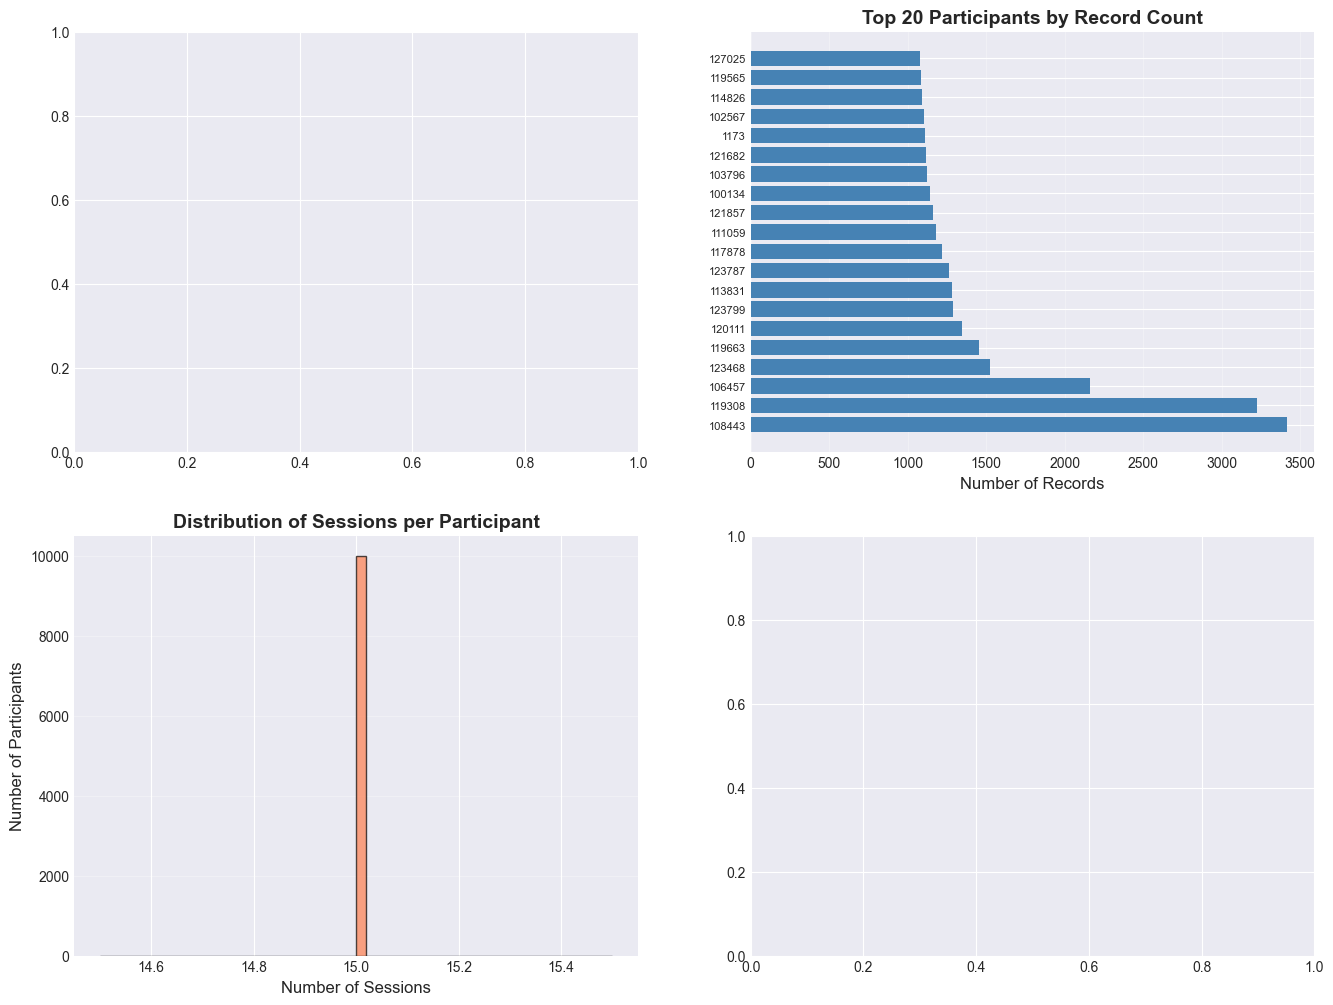

In [51]:

# Visualize file loading statistics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loading progress over time
if 'elapsed' in locals():
    batch_numbers = list(range(1, len(dataframes) // batch_size + 2))
    success_rates = []
    for i in range(0, len(dataframes), batch_size):
        batch_end = min(i + batch_size, len(dataframes))
        success_rates.append((batch_end / len(keystroke_files)) * 100)
    
    axes[0, 0].plot(batch_numbers[:len(success_rates)], success_rates, marker='o', linewidth=2)
    axes[0, 0].set_xlabel('Batch Number', fontsize=12)
    axes[0, 0].set_ylabel('Cumulative Success Rate (%)', fontsize=12)
    axes[0, 0].set_title('File Loading Progress', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)

# 2. Records per participant (top 20)
if len(df_all) > 0:
    participant_record_counts = df_all['PARTICIPANT_ID'].value_counts().head(20)
    axes[0, 1].barh(range(len(participant_record_counts)), participant_record_counts.values, color='steelblue')
    axes[0, 1].set_yticks(range(len(participant_record_counts)))
    axes[0, 1].set_yticklabels(participant_record_counts.index, fontsize=8)
    axes[0, 1].set_xlabel('Number of Records', fontsize=12)
    axes[0, 1].set_title('Top 20 Participants by Record Count', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Sessions per participant distribution
if len(df_all) > 0:
    sessions_per_participant = df_all.groupby('PARTICIPANT_ID')['TEST_SECTION_ID'].nunique()
    axes[1, 0].hist(sessions_per_participant.values, bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Number of Sessions', fontsize=12)
    axes[1, 0].set_ylabel('Number of Participants', fontsize=12)
    axes[1, 0].set_title('Distribution of Sessions per Participant', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Data loading summary pie chart
if len(failed_files) > 0:
    success_count = len(dataframes)
    fail_count = len(failed_files)
    axes[1, 1].pie([success_count, fail_count], 
                   labels=[f'Success ({success_count:,})', f'Failed ({fail_count:,})'],
                   autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
    axes[1, 1].set_title('File Loading Success Rate', fontsize=14, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'All files loaded\nsuccessfully!', 
                   ha='center', va='center', fontsize=14, fontweight='bold')
    axes[1, 1].set_title('File Loading Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Data loading visualizations complete!")

### Sessions per User & Keystroke Count Distribution

Full distribution of sessions per user and keystrokes per session.

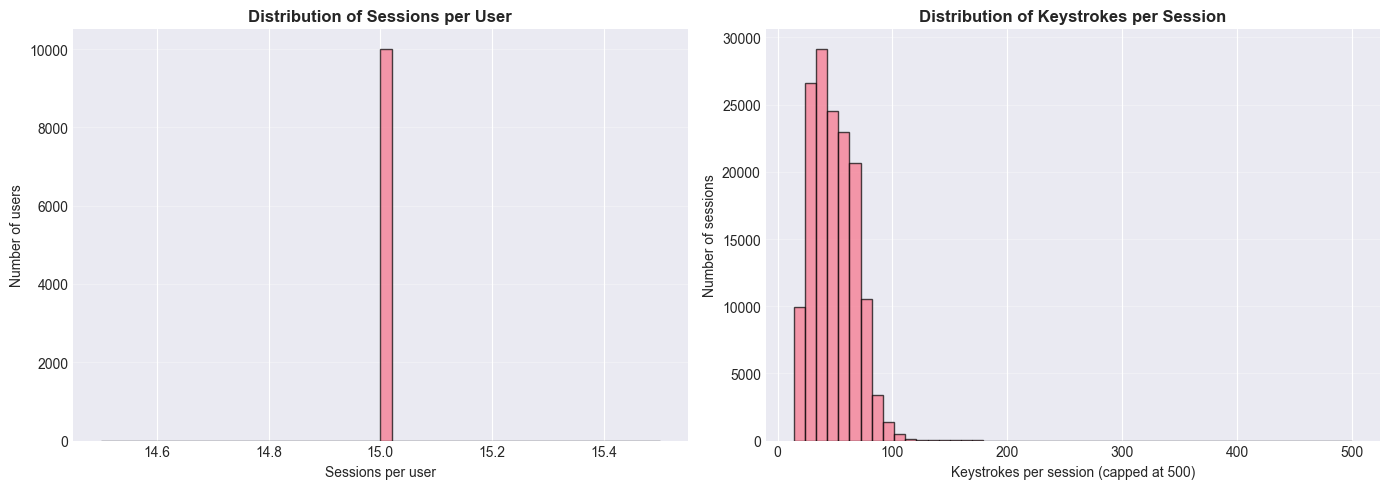

In [52]:
# Sessions per user (full distribution) and keystroke count per session
if 'df_all' in dir() and df_all is not None and len(df_all) > 0:
    sessions_per_user = df_all.groupby('PARTICIPANT_ID')['TEST_SECTION_ID'].nunique()
    keystrokes_per_session = df_all.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID']).size()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(sessions_per_user, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Sessions per user')
    axes[0].set_ylabel('Number of users')
    axes[0].set_title('Distribution of Sessions per User', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    axes[1].hist(keystrokes_per_session.clip(upper=500), bins=50, edgecolor='black', alpha=0.7)  # clip for visibility
    axes[1].set_xlabel('Keystrokes per session (capped at 500)')
    axes[1].set_ylabel('Number of sessions')
    axes[1].set_title('Distribution of Keystrokes per Session', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Load df_all first.")

### Sample Keystroke Timeline (One Session)

Press/release times for one session to visualize typing rhythm.

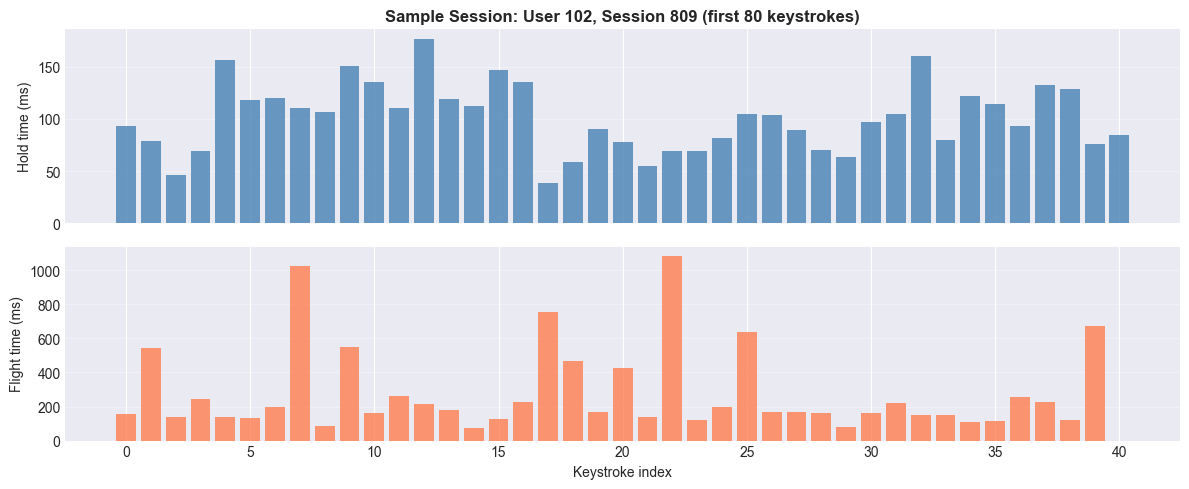

In [53]:
# Sample timeline: hold time and flight time over keystroke index for one session
if 'df_all' in dir() and df_all is not None and len(df_all) > 0:
    one = df_all.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID']).first().reset_index()
    pid, sid = one.iloc[0]['PARTICIPANT_ID'], one.iloc[0]['TEST_SECTION_ID']
    session = df_all[(df_all['PARTICIPANT_ID']==pid) & (df_all['TEST_SECTION_ID']==sid)].sort_values('PRESS_TIME')
    session = session.head(80)  # first 80 keystrokes
    hold = (session['RELEASE_TIME'] - session['PRESS_TIME']).values
    press = session['PRESS_TIME'].values
    flight = np.diff(press) if len(press) > 1 else np.array([0])
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].bar(range(len(hold)), hold, color='steelblue', alpha=0.8)
    axes[0].set_ylabel('Hold time (ms)')
    axes[0].set_title(f'Sample Session: User {pid}, Session {sid} (first 80 keystrokes)', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    axes[1].bar(range(len(flight)), flight, color='coral', alpha=0.8)
    axes[1].set_xlabel('Keystroke index')
    axes[1].set_ylabel('Flight time (ms)')
    axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Load df_all first.")

## 3. Feature Engineering

### 3.1. Define Feature Extraction Function

Extract keystroke dynamics features including:
- **Hold Time (Dwell Time)**: Duration key is pressed
- **Flight Time (Latency)**: Time between consecutive keystrokes
- **Typing Speed**: Characters per second
- **Statistical Features**: Mean, std, min, max, percentiles


In [54]:
def extract_features_for_group(args):
    """
    Extract features for a single participant-session group.
    This function is designed for multiprocessing.
    """
    (participant_id, session_id), group = args
    
    if len(group) < 5:  # Skip sessions with too few keystrokes
        return None
    
    # Basic timing features
    hold_times = group['hold_time'].values
    flight_times = group['flight_time'].values[1:]  # Skip first (no previous key)
    
    # Statistical features for hold time
    hold_mean = np.mean(hold_times)
    hold_std = np.std(hold_times)
    hold_min = np.min(hold_times)
    hold_max = np.max(hold_times)
    hold_median = np.median(hold_times)
    hold_q25 = np.percentile(hold_times, 25)
    hold_q75 = np.percentile(hold_times, 75)
    
    # Statistical features for flight time
    if len(flight_times) > 0:
        flight_mean = np.mean(flight_times)
        flight_std = np.std(flight_times)
        flight_min = np.min(flight_times)
        flight_max = np.max(flight_times)
        flight_median = np.median(flight_times)
        flight_q25 = np.percentile(flight_times, 25)
        flight_q75 = np.percentile(flight_times, 75)
    else:
        flight_mean = flight_std = flight_min = flight_max = flight_median = 0
        flight_q25 = flight_q75 = 0
    
    # Typing speed (characters per second)
    total_time = group['RELEASE_TIME'].max() - group['PRESS_TIME'].min()
    num_chars = len(group[group['KEYCODE'].notna()])
    typing_speed = (num_chars / (total_time / 1000)) if total_time > 0 else 0
    
    # Number of keystrokes
    num_keystrokes = len(group)
    
    # Keycode statistics
    keycodes = group['KEYCODE'].dropna().values
    if len(keycodes) > 0:
        unique_keycodes = len(np.unique(keycodes))
        # Convert to numeric, coercing errors to NaN
        keycodes_numeric = pd.to_numeric(keycodes, errors='coerce')
        keycodes_numeric = keycodes_numeric[~np.isnan(keycodes_numeric)]  # Remove NaN values
        
        if len(keycodes_numeric) > 0:
            keycode_mean = np.mean(keycodes_numeric)
            keycode_std = np.std(keycodes_numeric)
        else:
            # If no valid numeric keycodes, use 0
            keycode_mean = keycode_std = 0
    else:
        unique_keycodes = keycode_mean = keycode_std = 0
    
    # Digraph timing (two-key combinations) - Enhanced feature
    digraph_times = []
    for i in range(len(hold_times) - 1):
        digraph_time = hold_times[i] + flight_times[i] if i < len(flight_times) else 0
        digraph_times.append(digraph_time)
    
    if len(digraph_times) > 0:
        digraph_mean = np.mean(digraph_times)
        digraph_std = np.std(digraph_times)
    else:
        digraph_mean = digraph_std = 0
    
    # Pause detection (long gaps between keystrokes)
    if len(flight_times) > 0:
        pause_threshold = np.percentile(flight_times, 90)  # 90th percentile
        pauses = flight_times[flight_times > pause_threshold]
        num_pauses = len(pauses)
        avg_pause_duration = np.mean(pauses) if len(pauses) > 0 else 0
    else:
        num_pauses = avg_pause_duration = 0
    
    features = {
        'participant_id': participant_id,
        'session_id': session_id,
        # Hold time features
        'hold_mean': hold_mean,
        'hold_std': hold_std,
        'hold_min': hold_min,
        'hold_max': hold_max,
        'hold_median': hold_median,
        'hold_q25': hold_q25,
        'hold_q75': hold_q75,
        # Flight time features
        'flight_mean': flight_mean,
        'flight_std': flight_std,
        'flight_min': flight_min,
        'flight_max': flight_max,
        'flight_median': flight_median,
        'flight_q25': flight_q25,
        'flight_q75': flight_q75,
        # Other features
        'typing_speed': typing_speed,
        'num_keystrokes': num_keystrokes,
        'unique_keycodes': unique_keycodes,
        'keycode_mean': keycode_mean,
        'keycode_std': keycode_std,
        # Enhanced features
        'digraph_mean': digraph_mean,
        'digraph_std': digraph_std,
        'num_pauses': num_pauses,
        'avg_pause_duration': avg_pause_duration
    }
    
    return features


def extract_keystroke_features(df, use_multiprocessing=True, n_jobs=None):
    """
    Extract keystroke dynamics features from raw keystroke data.
    
    Features:
    - Hold time: Time key is pressed (RELEASE_TIME - PRESS_TIME)
    - Flight time: Time between consecutive keystrokes
    - Typing speed: Characters per second
    - Statistical features: Mean, std, min, max of timing patterns
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw keystroke data
    use_multiprocessing : bool
        Whether to use multiprocessing for faster extraction
    n_jobs : int or None
        Number of parallel jobs. If None, uses all available CPUs
    """
    # Sort by participant, session, and press time
    df = df.sort_values(['PARTICIPANT_ID', 'TEST_SECTION_ID', 'PRESS_TIME']).copy()
    
    # Calculate hold time (dwell time)
    df['hold_time'] = df['RELEASE_TIME'] - df['PRESS_TIME']
    
    # Calculate flight time (latency between keys)
    df['flight_time'] = df.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID'])['PRESS_TIME'].diff()
    
    # Calculate time from previous release
    df['time_from_release'] = df.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID'])['RELEASE_TIME'].shift(1)
    df['flight_time_alt'] = df['PRESS_TIME'] - df['time_from_release']
    df['flight_time_alt'] = df['flight_time_alt'].fillna(0)
    
    # Remove negative flight times (data errors)
    df = df[df['flight_time'] >= 0]
    df['flight_time'] = df['flight_time'].fillna(0)
    
    # Group by participant and session
    groups = list(df.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID']))
    total_groups = len(groups)
    
    # Use sequential for <=200k sessions so progress starts immediately (avoids Pool spawn on Windows)
    use_pool = use_multiprocessing and total_groups > 200000
    if use_pool:
        if n_jobs is None:
            n_jobs = min(4, cpu_count()) if total_groups <= 200000 else cpu_count()  # Fewer workers = faster spawn on Windows
        print(f"Using multiprocessing with {n_jobs} workers...")
        with Pool(processes=n_jobs) as pool:
            features_list = list(tqdm(
                pool.imap(extract_features_for_group, groups),
                total=total_groups,
                desc="Extracting features",
                unit="session"
            ))
    else:
        # Sequential: progress bar moves immediately (no Pool spawn delay)
        features_list = []
        for group in tqdm(groups, desc="Extracting features", unit="session"):
            result = extract_features_for_group(group)
            if result is not None:
                features_list.append(result)
    
    # Filter out None results
    features_list = [f for f in features_list if f is not None]
    
    return pd.DataFrame(features_list)

print("Feature extraction function defined with multiprocessing support!")


Feature extraction function defined with multiprocessing support!


### 3.2. Extract Features from Dataset

Apply the feature extraction function to all loaded keystroke data.


In [56]:
# Extract features from df_all (checkpoints keyed to len(keystroke_files) so 10k-only run is consistent)
print("="*70)
print("Extracting Keystroke Features")
print("="*70)
print(f"\n📁 Data source: {len(keystroke_files):,} files. Features checkpoint keyed to this count.")

# Setup checkpoint directory
CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
FEATURES_CHECKPOINT = CHECKPOINT_DIR / f'features_extracted_{len(keystroke_files)}.pkl'
FEATURES_METADATA = CHECKPOINT_DIR / f'features_metadata_{len(keystroke_files)}.json'

print(f"\nCheckpoint directory: {CHECKPOINT_DIR}")
print(f"Features checkpoint: {FEATURES_CHECKPOINT}")

# Check if checkpoint exists
if FEATURES_CHECKPOINT.exists():
    print("\n" + "="*70)
    print("✓ Found existing features checkpoint!")
    print("="*70)
    print(f"Loading from checkpoint: {FEATURES_CHECKPOINT}")
    
    try:
        features_df = joblib.load(FEATURES_CHECKPOINT)
        
        # Load metadata if available
        if FEATURES_METADATA.exists():
            with open(FEATURES_METADATA, 'r') as f:
                metadata = json.load(f)
                print(f"\n📊 Checkpoint Metadata:")
                print(f"  Extracted on: {metadata.get('timestamp', 'Unknown')}")
                print(f"  Total sessions: {metadata.get('total_sessions', 'Unknown'):,}")
                print(f"  Processing time: {metadata.get('elapsed_time', 0):.2f} seconds")
        
        print(f"\n✓ Successfully loaded checkpoint!")
        print(f"  Total sessions: {len(features_df):,}")
        print(f"  Total features: {len(features_df.columns)}")
        print(f"  Memory usage: {features_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"\n📋 Feature columns ({len(features_df.columns)} total):")
        for i, col in enumerate(features_df.columns, 1):
            print(f"  {i:2d}. {col}")
        print(f"\n💡 To re-extract features, delete the checkpoint file and rerun this cell.")
    except Exception as e:
        print(f"\n⚠ Error loading checkpoint: {e}")
        print("Will proceed with feature extraction from raw data...")
        features_df = None
else:
    features_df = None

# If checkpoint doesn't exist or failed to load, proceed with extraction
if features_df is None:
    # Check dataset size
    total_records = len(df_all) if 'df_all' in locals() else 0
    total_sessions = df_all.groupby(['PARTICIPANT_ID', 'TEST_SECTION_ID']).ngroups if 'df_all' in locals() else 0

    print(f"\nDataset Statistics:")
    print(f"  Total records: {total_records:,}")
    print(f"  Total sessions: {total_sessions:,}")
    print(f"  Estimated processing time: {total_sessions * 0.001:.1f} seconds (approx.)")

    # Start timing
    start_time = time.time()

    # Extract features (automatically uses multiprocessing for large datasets)
    print(f"\nStarting feature extraction...")
    features_df = extract_keystroke_features(df_all, use_multiprocessing=True, n_jobs=None)

    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    elapsed_minutes = int(elapsed_time // 60)
    elapsed_seconds = int(elapsed_time % 60)

    print("\n" + "="*70)
    print("✓ Feature Extraction Complete!")
    print("="*70)
    print(f"\n⏱️  Time taken: {elapsed_minutes}m {elapsed_seconds}s ({elapsed_time:.2f} seconds)")
    print(f"📊 Features extracted: {features_df.shape[0]:,} sessions × {features_df.shape[1]} features")
    print(f"⚡ Processing rate: {features_df.shape[0]/elapsed_time:.1f} sessions/second")

    # Save checkpoint
    print(f"\n💾 Saving features checkpoint...")
    try:
        joblib.dump(features_df, FEATURES_CHECKPOINT)
        
        # Save metadata
        metadata = {
            'timestamp': datetime.now().isoformat(),
            'total_sessions': len(features_df),
            'total_features': len(features_df.columns),
            'elapsed_time': elapsed_time,
            'processing_rate': features_df.shape[0]/elapsed_time if elapsed_time > 0 else 0,
            'feature_columns': list(features_df.columns),
            'data_shape': list(features_df.shape),
            'memory_mb': features_df.memory_usage(deep=True).sum() / 1024**2
        }
        
        with open(FEATURES_METADATA, 'w') as f:
            json.dump(metadata, f, indent=2)
        
        print(f"  ✓ Saved to: {FEATURES_CHECKPOINT}")
        print(f"  ✓ Metadata saved to: {FEATURES_METADATA}")
        print(f"  File size: {FEATURES_CHECKPOINT.stat().st_size / 1024**2:.2f} MB")
    except Exception as e:
        print(f"  ⚠ Warning: Could not save checkpoint: {e}")

    print(f"\n📋 Feature columns ({len(features_df.columns)} total):")
    for i, col in enumerate(features_df.columns, 1):
        print(f"  {i:2d}. {col}")

    print(f"\n📈 First few rows:")
    print(features_df.head())

    print(f"\n💾 Memory usage: {features_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*70)
print("✓ Feature Extraction Process Complete!")
print("="*70)


Extracting Keystroke Features

📁 Data source: 10,000 files. Features checkpoint keyed to this count.

Checkpoint directory: ..\checkpoints
Features checkpoint: ..\checkpoints\features_extracted_10000.pkl

✓ Found existing features checkpoint!
Loading from checkpoint: ..\checkpoints\features_extracted_10000.pkl

📊 Checkpoint Metadata:
  Extracted on: 2026-02-08T02:49:32.249020
  Total sessions: 150,000
  Processing time: 130.92 seconds

✓ Successfully loaded checkpoint!
  Total sessions: 150,000
  Total features: 25
  Memory usage: 28.61 MB

📋 Feature columns (25 total):
   1. participant_id
   2. session_id
   3. hold_mean
   4. hold_std
   5. hold_min
   6. hold_max
   7. hold_median
   8. hold_q25
   9. hold_q75
  10. flight_mean
  11. flight_std
  12. flight_min
  13. flight_max
  14. flight_median
  15. flight_q25
  16. flight_q75
  17. typing_speed
  18. num_keystrokes
  19. unique_keycodes
  20. keycode_mean
  21. keycode_std
  22. digraph_mean
  23. digraph_std
  24. num_pauses


### 3.3. Analyze Extracted Features

Check data quality, missing values, and feature distributions.


In [57]:
# Check for missing values and data quality
print("Data Quality Check:")
print(f"Missing values:\n{features_df.isnull().sum()}")
print(f"\nData types:\n{features_df.dtypes}")   
print(f"\nBasic statistics:")
print(features_df.describe())


Data Quality Check:
Missing values:
participant_id        0
session_id            0
hold_mean             0
hold_std              0
hold_min              0
hold_max              0
hold_median           0
hold_q25              0
hold_q75              0
flight_mean           0
flight_std            0
flight_min            0
flight_max            0
flight_median         0
flight_q25            0
flight_q75            0
typing_speed          0
num_keystrokes        0
unique_keycodes       0
keycode_mean          0
keycode_std           0
digraph_mean          0
digraph_std           0
num_pauses            0
avg_pause_duration    0
dtype: int64

Data types:
participant_id          int64
session_id              int64
hold_mean             float64
hold_std              float64
hold_min              float64
hold_max              float64
hold_median           float64
hold_q25              float64
hold_q75              float64
flight_mean           float64
flight_std            float64
flight_m

### 3.4. Visualize Feature Distributions

Visualize and analyze the data at this stage.

Visualize and analyze the data at this stage.


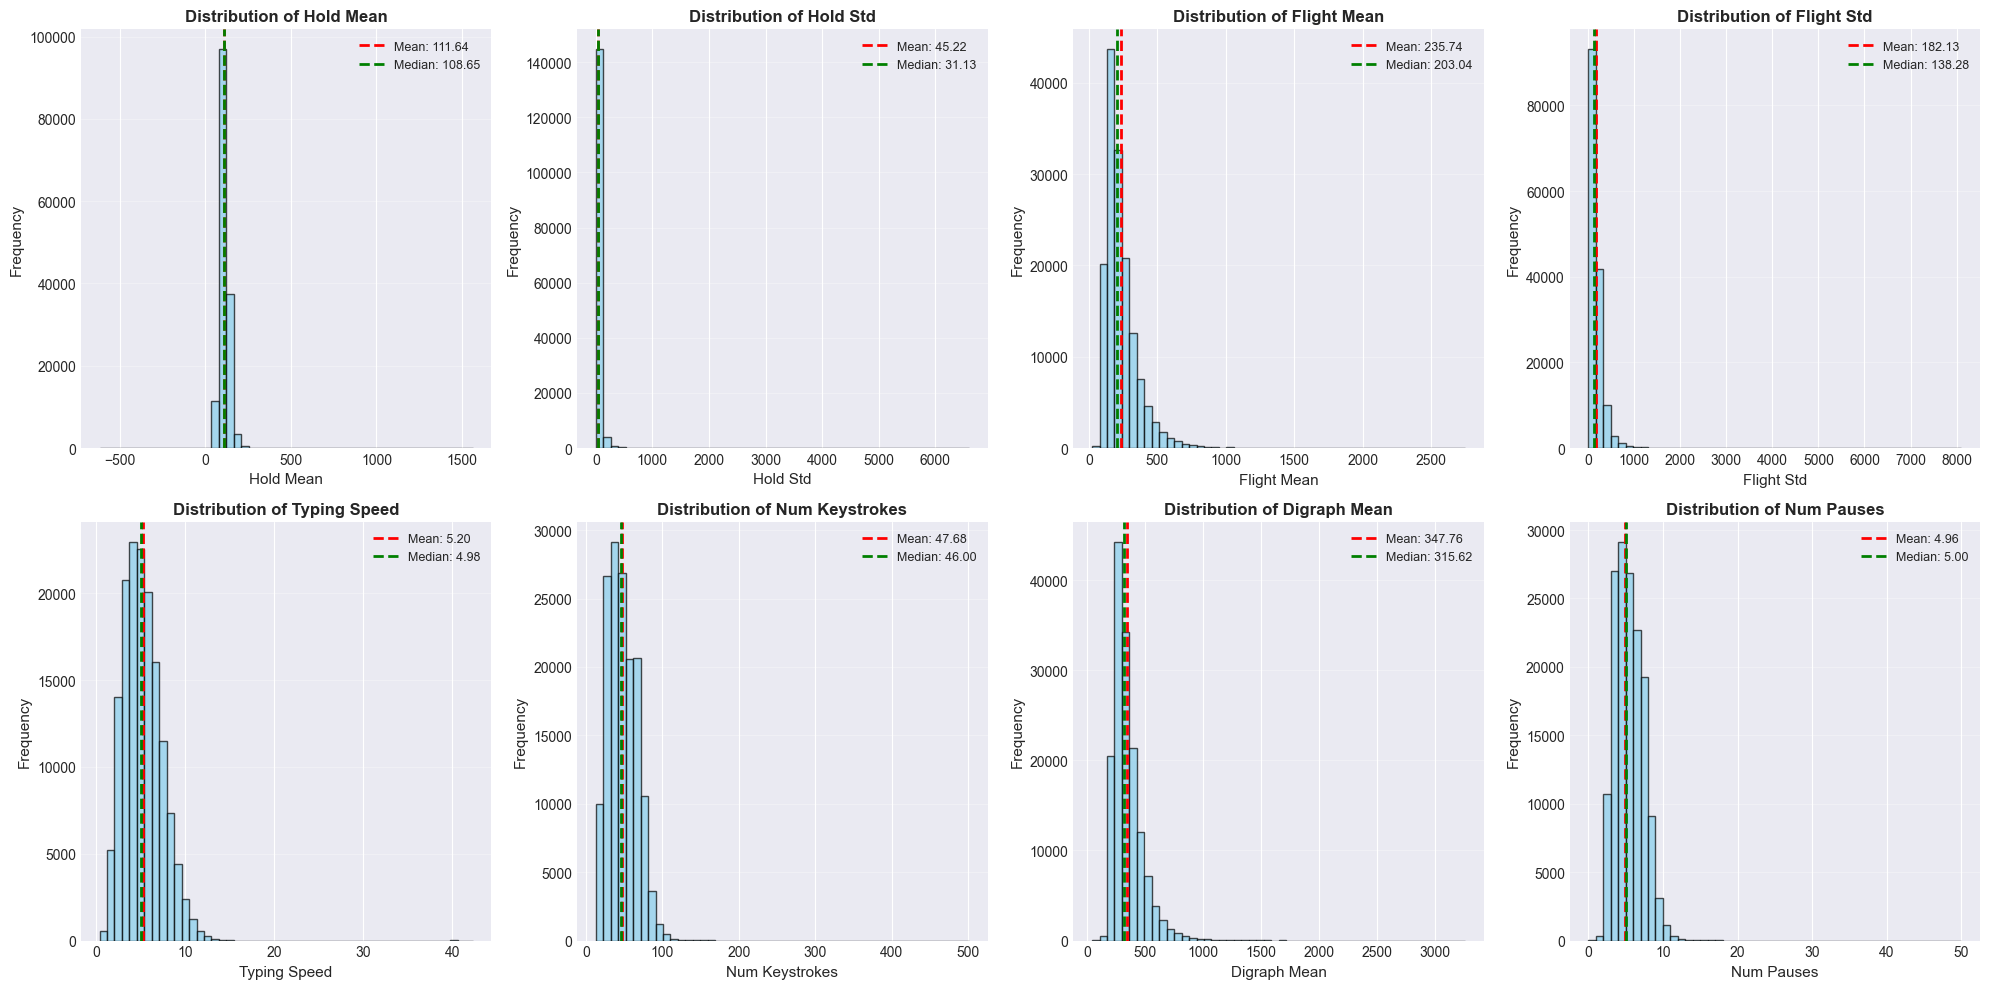


✓ Feature distribution visualizations complete!


In [58]:

# Visualize feature distributions
if len(features_df) > 0:
    # Select key features for visualization
    key_features = ['hold_mean', 'hold_std', 'flight_mean', 'flight_std', 
                    'typing_speed', 'num_keystrokes', 'digraph_mean', 'num_pauses']
    available_features = [f for f in key_features if f in features_df.columns]
    
    if len(available_features) > 0:
        n_features = len(available_features)
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for idx, feature in enumerate(available_features):
            data = features_df[feature].dropna()
            if len(data) > 0:
                axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
                axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
                axes[idx].set_ylabel('Frequency', fontsize=11)
                axes[idx].set_title(f'Distribution of {feature.replace("_", " ").title()}', 
                                  fontsize=12, fontweight='bold')
                axes[idx].grid(True, alpha=0.3, axis='y')
                # Add statistics
                mean_val = data.mean()
                median_val = data.median()
                axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
                axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
                axes[idx].legend(fontsize=9)
        
        # Hide unused subplots
        for idx in range(len(available_features), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Feature distribution visualizations complete!")
    else:
        print("No key features available for visualization.")
else:
    print("No features extracted yet.")

### 3.5. Feature Correlation Analysis

Visualize and analyze the data at this stage.

Visualize and analyze the data at this stage.


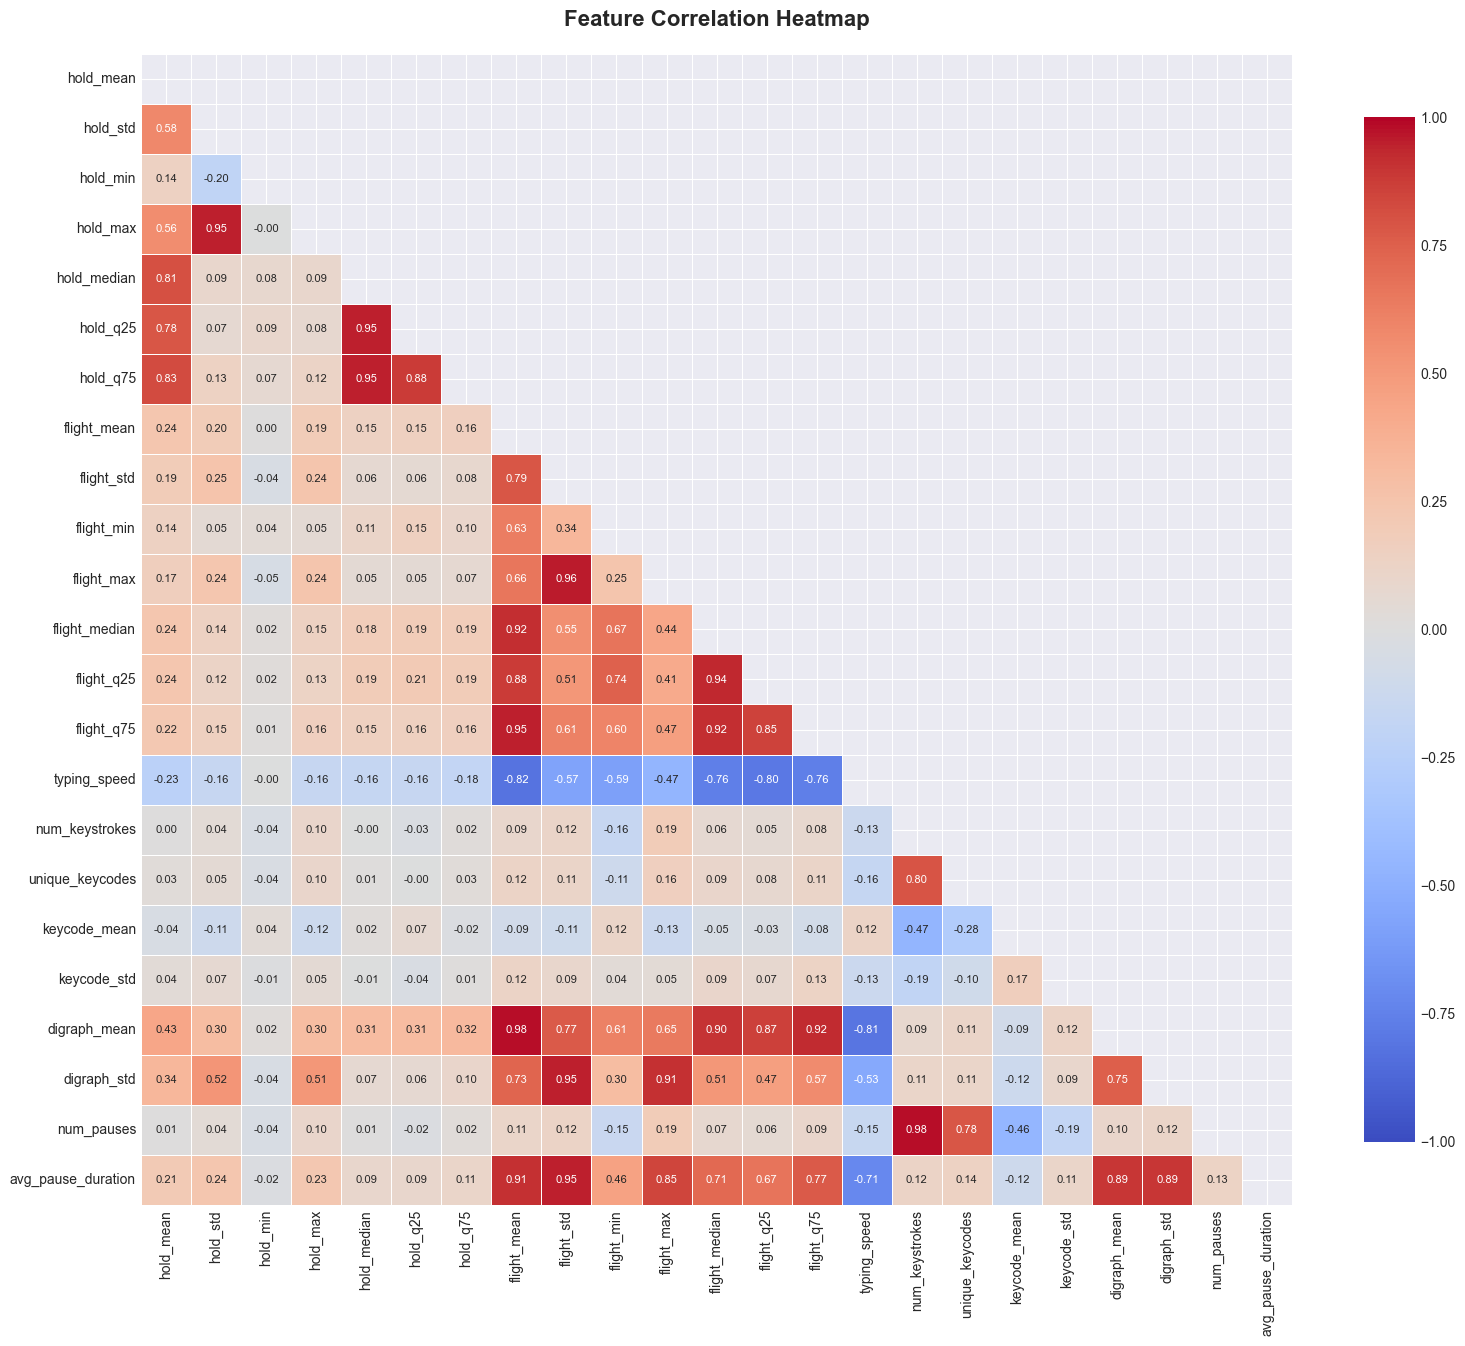


⚠ Found 27 highly correlated feature pairs (|r| > 0.8):
  - hold_mean & hold_median: 0.811
  - hold_mean & hold_q75: 0.827
  - hold_std & hold_max: 0.952
  - hold_median & hold_q25: 0.947
  - hold_median & hold_q75: 0.947
  - hold_q25 & hold_q75: 0.882
  - flight_mean & flight_median: 0.919
  - flight_mean & flight_q25: 0.878
  - flight_mean & flight_q75: 0.946
  - flight_mean & typing_speed: -0.815

✓ Correlation analysis complete!


In [59]:

# Feature correlation heatmap
if len(features_df) > 0:
    # Select numeric features
    numeric_features = features_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'participant_id' in numeric_features:
        numeric_features.remove('participant_id')
    if 'session_id' in numeric_features:
        numeric_features.remove('session_id')
    
    if len(numeric_features) > 1:
        # Calculate correlation matrix
        corr_matrix = features_df[numeric_features].corr()
        
        # Create heatmap
        plt.figure(figsize=(16, 14))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                   vmin=-1, vmax=1, annot_kws={'size': 8})
        plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        # Find highly correlated features
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.8:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if len(high_corr_pairs) > 0:
            print(f"\n⚠ Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.8):")
            for feat1, feat2, corr_val in high_corr_pairs[:10]:  # Show first 10
                print(f"  - {feat1} & {feat2}: {corr_val:.3f}")
        
        print("\n✓ Correlation analysis complete!")
    else:
        print("Not enough numeric features for correlation analysis.")
else:
    print("No features available for correlation analysis.")

### Missingness Pattern & Outlier Check

Which features are missing most; simple outlier flag (IQR) per feature.

In [60]:
# Missingness: count and % per feature; outlier count (IQR rule) per numeric feature
if 'features_df' in dir():
    df = features_df.select_dtypes(include=[np.number])
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    miss_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).sort_values('count', ascending=False)
    print("Missing values by feature (top 15):")
    print(miss_df.head(15).to_string())
    Q1, Q3 = df.quantile(0.25), df.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).sum()
    print("\nOutlier count (1.5*IQR rule) per feature (top 10):")
    print(outliers.sort_values(ascending=False).head(10).to_string())
else:
    print("Run feature extraction first (features_df).")

Missing values by feature (top 15):
                 count  pct
participant_id       0  0.0
flight_median        0  0.0
num_pauses           0  0.0
digraph_std          0  0.0
digraph_mean         0  0.0
keycode_std          0  0.0
keycode_mean         0  0.0
unique_keycodes      0  0.0
num_keystrokes       0  0.0
typing_speed         0  0.0
flight_q75           0  0.0
flight_q25           0  0.0
flight_max           0  0.0
session_id           0  0.0
flight_min           0  0.0

Outlier count (1.5*IQR rule) per feature (top 10):
hold_max              18165
hold_std              16056
participant_id        14760
session_id            14760
flight_q75            10305
flight_max             9865
digraph_std            8603
flight_std             8412
avg_pause_duration     7189
flight_median          7174


### Top Correlated Pairs & Feature vs Target (Sample User)

Top feature pairs by correlation; one key feature distribution by user (sample).

Top 10 correlated feature pairs (by |correlation|):
  num_keystrokes vs num_pauses: 0.979
  flight_mean vs digraph_mean: 0.978
  flight_std vs flight_max: 0.957
  hold_std vs hold_max: 0.952
  flight_std vs digraph_std: 0.949
  flight_std vs avg_pause_duration: 0.948
  hold_median vs hold_q25: 0.947
  hold_median vs hold_q75: 0.947
  flight_mean vs flight_q75: 0.946
  flight_median vs flight_q25: 0.937


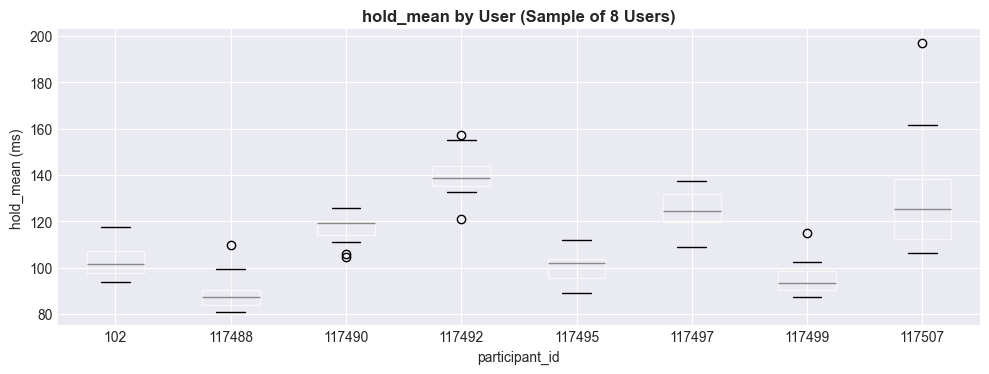

In [61]:
# Top correlated pairs table; hold_mean by user (sample) for separability
if 'features_df' in dir():
    num_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'participant_id' in num_cols:
        num_cols.remove('participant_id')
    if 'session_id' in num_cols:
        num_cols.remove('session_id')
    corr = features_df[num_cols].corr()
    pairs = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            pairs.append((corr.columns[i], corr.columns[j], abs(corr.iloc[i, j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    print("Top 10 correlated feature pairs (by |correlation|):")
    for a, b, c in pairs[:10]:
        print(f"  {a} vs {b}: {c:.3f}")
    top_users = features_df['participant_id'].value_counts().head(8).index.tolist()
    df_s = features_df[features_df['participant_id'].isin(top_users)]
    if 'hold_mean' in df_s.columns:
        df_s.boxplot(column='hold_mean', by='participant_id', figsize=(10, 4))
        plt.suptitle('')
        plt.title('hold_mean by User (Sample of 8 Users)', fontsize=12, fontweight='bold')
        plt.ylabel('hold_mean (ms)')
        plt.tight_layout()
        plt.show()
else:
    print("Run feature extraction first (features_df).")

### Key Feature Separability by User (Sample)

Boxplots of hold time and flight time for a sample of users — shows whether timing features differ across users (needed for identification).

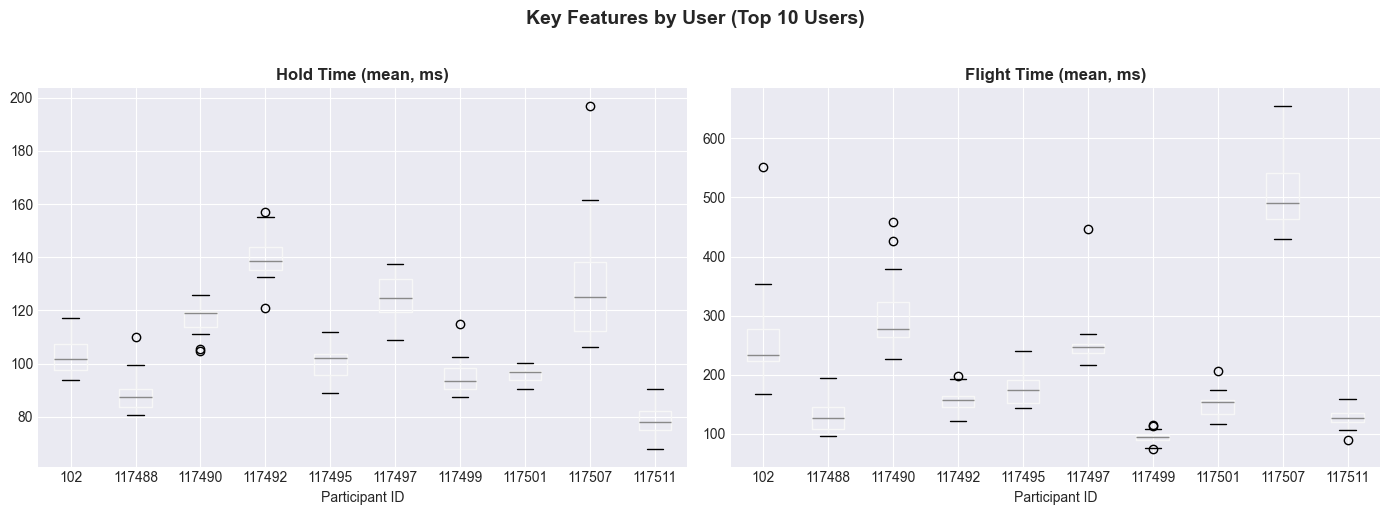

In [ ]:
# Hold mean and flight mean by user (top 10 users by session count) — separability check
if 'features_df' in dir() and 'participant_id' in features_df.columns:
    top_users = features_df['participant_id'].value_counts().head(10).index.tolist()
    df_sample = features_df[features_df['participant_id'].isin(top_users)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, title in zip(axes, ['hold_mean', 'flight_mean'], ['Hold Time (mean, ms)', 'Flight Time (mean, ms)']):
        if col in df_sample.columns:
            df_sample.boxplot(column=col, by='participant_id', ax=ax)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Participant ID')
            plt.suptitle('')  # remove auto title
    plt.suptitle('Key Features by User (Top 10 Users)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Run feature extraction first (features_df with participant_id).")

### 3.6. Checkpoint: Save Extracted Features

Save intermediate results for faster reloading.

Save intermediate results for faster reloading.


In [62]:

# Save extracted features as checkpoint
CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

features_checkpoint_path = CHECKPOINT_DIR / 'keystroke_features_checkpoint.pkl'
joblib.dump(features_df, features_checkpoint_path)
print(f"✓ Features checkpoint saved to: {features_checkpoint_path}")
print(f"  Shape: {features_df.shape}")
print(f"  Memory: {features_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Also save as CSV for easy inspection
features_csv_path = CHECKPOINT_DIR / 'keystroke_features_checkpoint.csv'
features_df.to_csv(features_csv_path, index=False)
print(f"✓ Features CSV saved to: {features_csv_path}")

✓ Features checkpoint saved to: ..\checkpoints\keystroke_features_checkpoint.pkl
  Shape: (150000, 25)
  Memory: 28.61 MB
✓ Features CSV saved to: ..\checkpoints\keystroke_features_checkpoint.csv


### 4.1. Visualize Participant Data Distribution

Visualize and analyze the data at this stage.

Visualize and analyze the data at this stage.


Filtering Participants by Session Count

📊 Session Distribution Analysis:
  Median sessions: 15
  75th percentile: 15
  Recommended threshold: 15 (maximized for quality)
  This ensures users have sufficient data for reliable model training

📊 Before Filtering:
  Total participants: 10,000
  Total sessions: 150,000
  Min sessions per participant: 15
  Max sessions per participant: 15
  Mean sessions per participant: 15.0
  Median sessions per participant: 15.0

📊 After Filtering (>= 15 sessions, top 50 users):
  Valid participants: 50
  Filtered sessions: 750
  Participants removed: 9,950
  Sessions removed: 149,250
  Retention rate: 0.5%


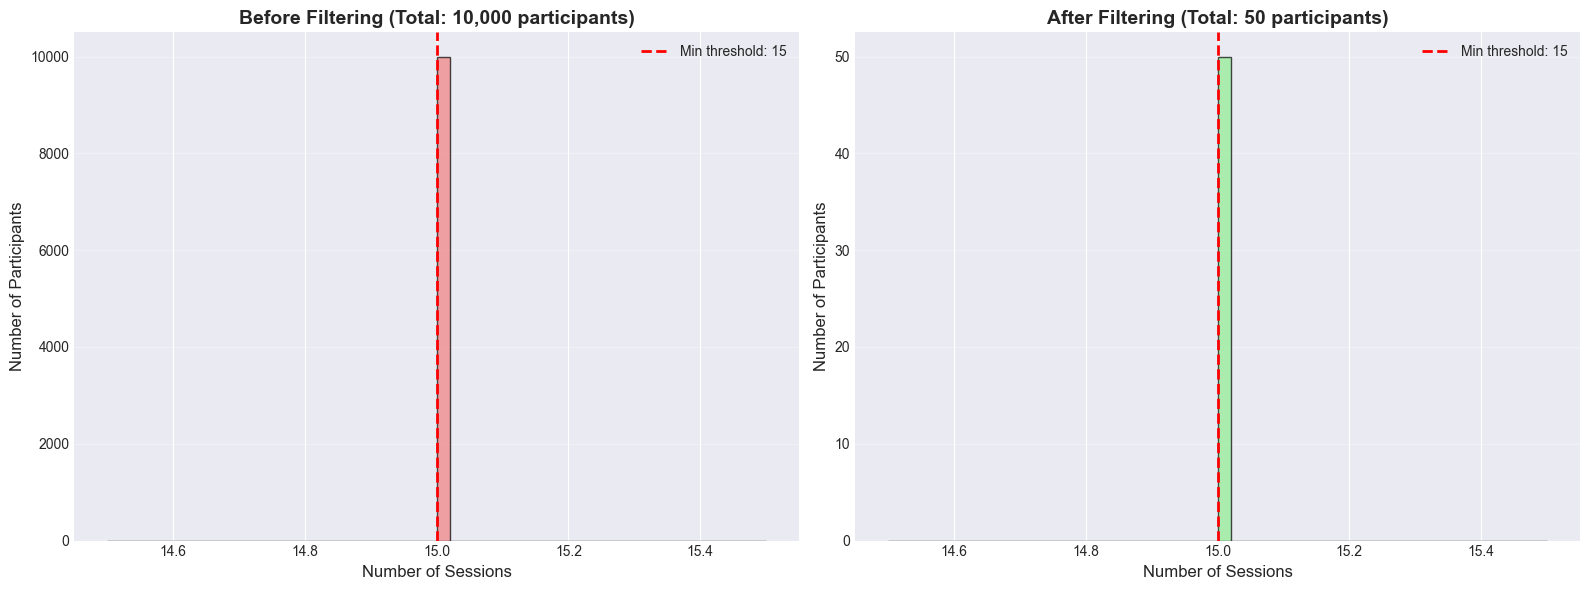

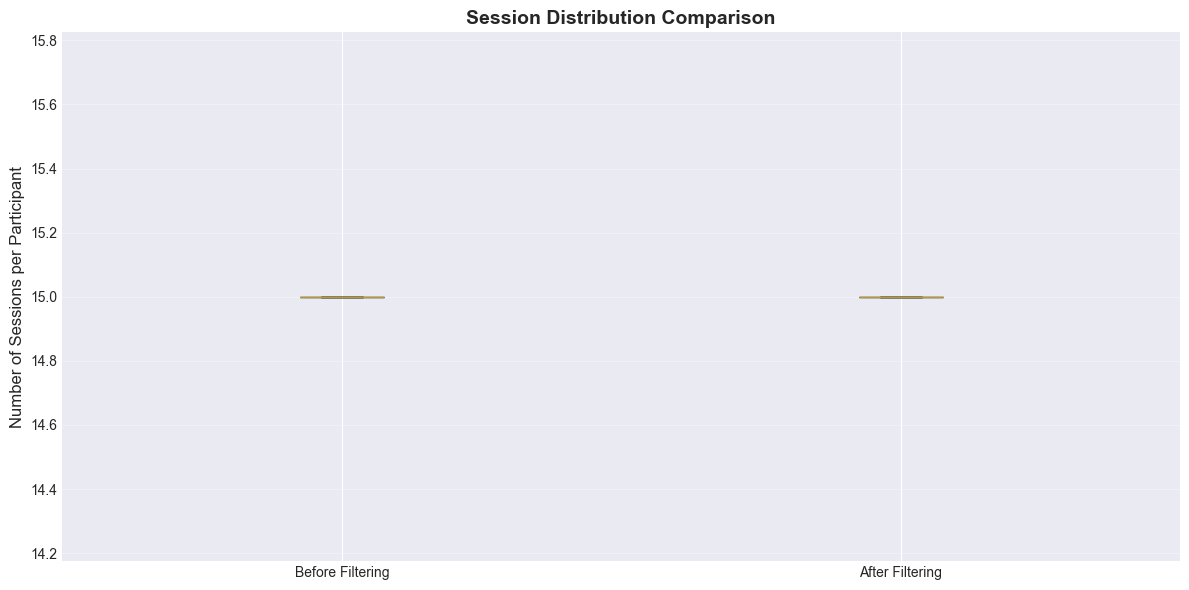


📈 Session Distribution Statistics:
  Before filtering:
    Q1 (25th percentile): 15.0
    Median (50th percentile): 15.0
    Q3 (75th percentile): 15.0
  After filtering:
    Q1 (25th percentile): 15.0
    Median (50th percentile): 15.0
    Q3 (75th percentile): 15.0

✓ Participant filtering and distribution visualizations complete!


In [63]:

print("="*70)
print("Filtering Participants by Session Count")
print("="*70)

# Calculate session counts per participant first
participant_counts_before = features_df['participant_id'].value_counts()

# Calculate optimal threshold based on data distribution
# Using 75th percentile or median - whichever is higher (maximizes quality)
percentile_75 = int(np.percentile(participant_counts_before.values, 75))
percentile_50 = int(np.percentile(participant_counts_before.values, 50))
median_val = int(participant_counts_before.median())

# Use the maximum threshold for best model quality
min_sessions = max(10, percentile_75, median_val)  # At least 10, or use distribution-based max

print(f"\n📊 Session Distribution Analysis:")
print(f"  Median sessions: {median_val}")
print(f"  75th percentile: {percentile_75}")
print(f"  Recommended threshold: {min_sessions} (maximized for quality)")
print(f"  This ensures users have sufficient data for reliable model training")

print(f"\n📊 Before Filtering:")
print(f"  Total participants: {len(participant_counts_before):,}")
print(f"  Total sessions: {len(features_df):,}")
print(f"  Min sessions per participant: {participant_counts_before.min()}")
print(f"  Max sessions per participant: {participant_counts_before.max()}")
print(f"  Mean sessions per participant: {participant_counts_before.mean():.1f}")
print(f"  Median sessions per participant: {participant_counts_before.median():.1f}")

# Filter participants with sufficient sessions
valid_participants = participant_counts_before[participant_counts_before >= min_sessions].index
features_df_filtered = features_df[features_df['participant_id'].isin(valid_participants)].copy()

participant_counts_after = features_df_filtered['participant_id'].value_counts()

# Option A: Limit to top-K users to prevent multi-class explosion and crashes
TOP_K_USERS = 50
top_k_participants = participant_counts_after.head(TOP_K_USERS).index
features_df_filtered = features_df_filtered[features_df_filtered['participant_id'].isin(top_k_participants)].copy()
valid_participants = top_k_participants
participant_counts_after = features_df_filtered['participant_id'].value_counts()

print(f"\n📊 After Filtering (>= {min_sessions} sessions, top {TOP_K_USERS} users):")
print(f"  Valid participants: {len(valid_participants):,}")
print(f"  Filtered sessions: {len(features_df_filtered):,}")
print(f"  Participants removed: {len(participant_counts_before) - len(valid_participants):,}")
print(f"  Sessions removed: {len(features_df) - len(features_df_filtered):,}")
print(f"  Retention rate: {(len(features_df_filtered) / len(features_df) * 100):.1f}%")

# Visualize participant data distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before filtering
axes[0].hist(participant_counts_before.values, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].axvline(min_sessions, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_sessions}')
axes[0].set_xlabel('Number of Sessions', fontsize=12)
axes[0].set_ylabel('Number of Participants', fontsize=12)
axes[0].set_title(f'Before Filtering (Total: {len(participant_counts_before):,} participants)', 
                 fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# After filtering
axes[1].hist(participant_counts_after.values, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(min_sessions, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_sessions}')
axes[1].set_xlabel('Number of Sessions', fontsize=12)
axes[1].set_ylabel('Number of Participants', fontsize=12)
axes[1].set_title(f'After Filtering (Total: {len(participant_counts_after):,} participants)', 
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Box plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
box_data = [participant_counts_before.values, participant_counts_after.values]
bp = ax.boxplot(box_data, labels=['Before Filtering', 'After Filtering'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
ax.set_ylabel('Number of Sessions per Participant', fontsize=12)
ax.set_title('Session Distribution Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Session distribution statistics
print(f"\n📈 Session Distribution Statistics:")
print(f"  Before filtering:")
print(f"    Q1 (25th percentile): {np.percentile(participant_counts_before.values, 25):.1f}")
print(f"    Median (50th percentile): {np.percentile(participant_counts_before.values, 50):.1f}")
print(f"    Q3 (75th percentile): {np.percentile(participant_counts_before.values, 75):.1f}")
print(f"  After filtering:")
print(f"    Q1 (25th percentile): {np.percentile(participant_counts_after.values, 25):.1f}")
print(f"    Median (50th percentile): {np.percentile(participant_counts_after.values, 50):.1f}")
print(f"    Q3 (75th percentile): {np.percentile(participant_counts_after.values, 75):.1f}")

print("\n✓ Participant filtering and distribution visualizations complete!")

### 4.2. Prepare Features and Labels

Separate feature columns from identifier columns and prepare for model training.

Separate feature columns from identifier columns and prepare for model training.


In [64]:
# Prepare features and labels
feature_columns = [col for col in features_df_filtered.columns 
                  if col not in ['participant_id', 'session_id']]

X = features_df_filtered[feature_columns].values
y = features_df_filtered['participant_id'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of unique users: {len(np.unique(y))}")
print(f"\nFeature columns: {feature_columns}")


Feature matrix shape: (750, 23)
Labels shape: (750,)
Number of unique users: 50

Feature columns: ['hold_mean', 'hold_std', 'hold_min', 'hold_max', 'hold_median', 'hold_q25', 'hold_q75', 'flight_mean', 'flight_std', 'flight_min', 'flight_max', 'flight_median', 'flight_q25', 'flight_q75', 'typing_speed', 'num_keystrokes', 'unique_keycodes', 'keycode_mean', 'keycode_std', 'digraph_mean', 'digraph_std', 'num_pauses', 'avg_pause_duration']


### 4.3. Handle Missing Values and Scale Features

Impute missing values and standardize features for model training.

Impute missing values and standardize features for model training.


In [65]:
# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Features scaled: {X_scaled.shape}")
print(f"Feature mean (first 5): {np.mean(X_scaled, axis=0)[:5]}")
print(f"Feature std (first 5): {np.std(X_scaled, axis=0)[:5]}")


Features scaled: (750, 23)
Feature mean (first 5): [ 1.32634644e-16  1.32634644e-16 -6.63173220e-17  1.89478063e-17
 -7.57912251e-17]
Feature std (first 5): [1. 1. 1. 1. 1.]


### 4.4. Encode Labels

Encode participant IDs to numeric labels for classification.

Encode participant IDs to numeric labels for classification.


In [66]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Encoded labels shape: {y_encoded.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Sample encoded labels: {y_encoded[:10]}")


Encoded labels shape: (750,)
Number of classes: 50
Sample encoded labels: [0 0 0 0 0 0 0 0 0 0]


### 4.5. Split Data into Train/Test Sets

Create stratified train/test split to ensure balanced class distribution.


### Temporal split (optional)

For more realistic “future session” evaluation, you can sort sessions by time (or file order), train on first 80%, test on last 20%. The notebook uses a **random** split by default; temporal split would require a time or session-order column.

In [67]:
# Split data: set USE_TEMPORAL_SPLIT = True to train on first 80% of sessions, test on last 20%
USE_TEMPORAL_SPLIT = False  # Default: random stratified split
TEST_SIZE = TEST_SIZE if 'TEST_SIZE' in dir() else 0.2
RANDOM_STATE = RANDOM_STATE if 'RANDOM_STATE' in dir() else 42

if USE_TEMPORAL_SPLIT and 'features_df_filtered' in dir():
    df = features_df_filtered.sort_values(['participant_id', 'session_id']).reset_index(drop=True)
    n = len(df)
    n_train = int(n * (1 - TEST_SIZE))
    train_idx = np.arange(n_train)
    test_idx = np.arange(n_train, n)
    X_sc = X_scaled.values if hasattr(X_scaled, 'values') else np.asarray(X_scaled)
    y_enc = np.asarray(y_encoded)
    X_train, X_test = X_sc[train_idx], X_sc[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
    print(f"Temporal split: train first {n_train:,} sessions, test last {n - n_train:,}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded
    )
    print("Random stratified split.")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training labels: {len(np.unique(y_train))} unique users")
print(f"Test labels: {len(np.unique(y_test))} unique users")


Random stratified split.
Training set: (600, 23)
Test set: (150, 23)
Training labels: 50 unique users
Test labels: 50 unique users


### Scaled Feature Ranges & Label Distribution

Verify scaling; class distribution (train) to see imbalance.

Scaled feature ranges (train): min / max per feature (first 10):
  Feature 0: [-1.904, 5.359]
  Feature 1: [-0.673, 10.490]
  Feature 2: [-2.773, 3.332]
  Feature 3: [-0.704, 12.187]
  Feature 4: [-2.079, 3.185]
  Feature 5: [-1.910, 4.129]
  Feature 6: [-1.902, 3.517]
  Feature 7: [-1.169, 5.072]
  Feature 8: [-0.870, 12.618]
  Feature 9: [-1.768, 5.851]


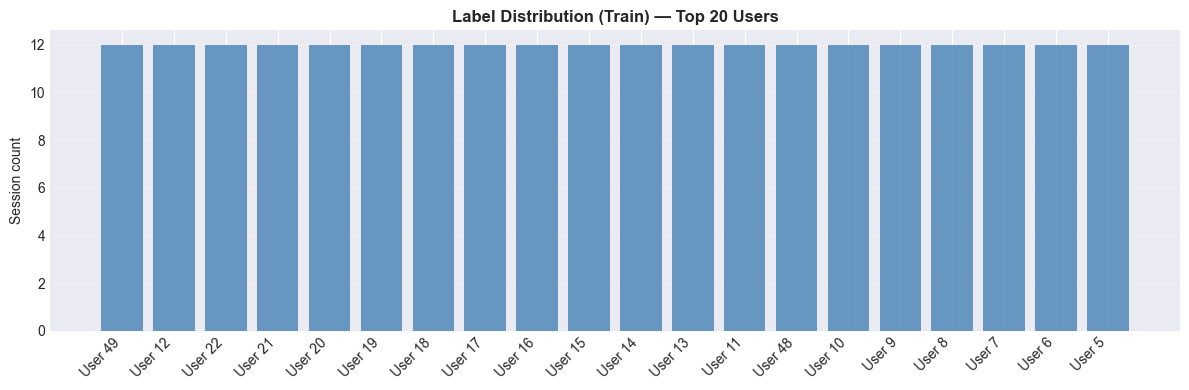

In [68]:
# Scaled feature ranges (min/max per feature on train); label distribution bar chart
if 'X_train' in dir() and 'X_test' in dir() and 'y_train' in dir():
    X_tr = np.array(X_train) if hasattr(X_train, 'values') else X_train
    print("Scaled feature ranges (train): min / max per feature (first 10):")
    for j in range(min(10, X_tr.shape[1])):
        print(f"  Feature {j}: [{X_tr[:, j].min():.3f}, {X_tr[:, j].max():.3f}]")
    unique, counts = np.unique(y_train, return_counts=True)
    top_20_idx = np.argsort(counts)[-20:][::-1]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(top_20_idx)), counts[top_20_idx], color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(top_20_idx)))
    ax.set_xticklabels([f'User {unique[top_20_idx[i]]}' for i in range(len(top_20_idx))], rotation=45, ha='right')
    ax.set_ylabel('Session count')
    ax.set_title('Label Distribution (Train) — Top 20 Users', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run train/test split first (X_train, y_train).")

### Train/Test Class Distribution

Verify that the stratified split keeps class proportions balanced across train and test sets.

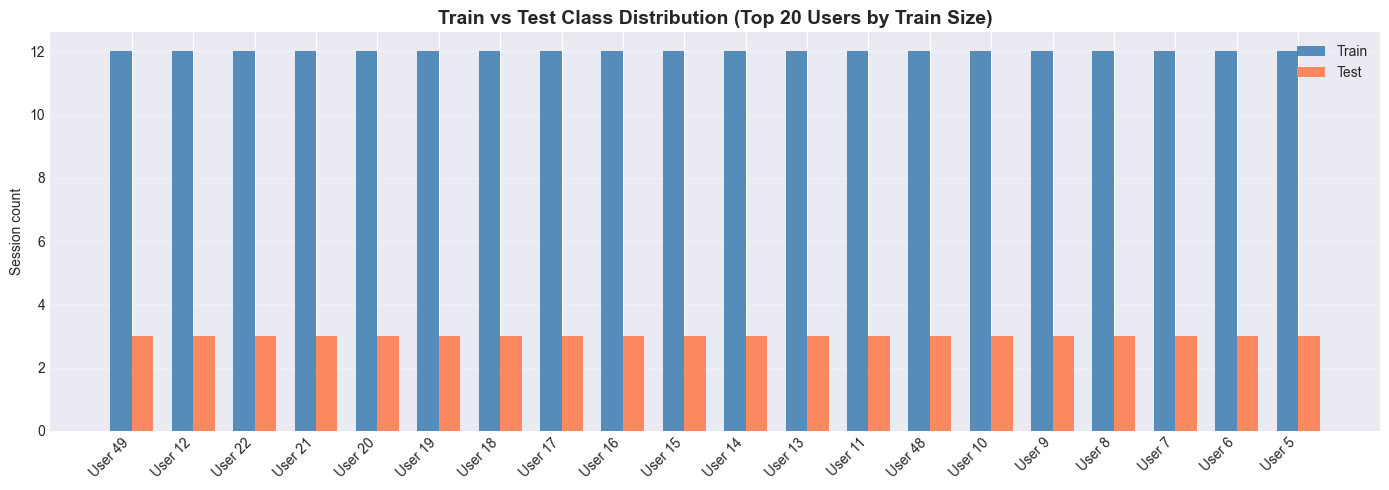

In [69]:
# Train vs test class distribution (top 20 classes by size)
if 'y_train' in dir() and 'y_test' in dir():
    unique_train, counts_train = np.unique(y_train, return_counts=True)
    unique_test, counts_test = np.unique(y_test, return_counts=True)
    # Top 20 classes by train count
    top_idx = np.argsort(counts_train)[-20:][::-1]
    top_classes = unique_train[top_idx]
    train_top = [np.sum(y_train == c) for c in top_classes]
    test_top = [np.sum(y_test == c) for c in top_classes]
    x = np.arange(len(top_classes))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, train_top, width, label='Train', color='steelblue', alpha=0.9)
    ax.bar(x + width/2, test_top, width, label='Test', color='coral', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'User {c}' for c in top_classes], rotation=45, ha='right')
    ax.set_ylabel('Session count')
    ax.set_title('Train vs Test Class Distribution (Top 20 Users by Train Size)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run train/test split cell first.")

### 4.6. Visualize Missing Values

Visualize and analyze the data at this stage.

## 5. Data Preprocessing

(Section removed: cross-validation visualization no longer used.)

(Section removed: hyperparameter tuning not used; single XGBoost fit only.)

In [70]:


# Save preprocessed data as checkpoint (keyed by file count so 10k and full-dataset don't mix)
preprocessed_checkpoint_path = CHECKPOINT_DIR / f'keystroke_preprocessed_checkpoint_{len(keystroke_files)}.pkl'
preprocessed_data = {
    'X_scaled': X_scaled,
    'y_encoded': y_encoded,
    'feature_columns': feature_columns,
    'imputer': imputer,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
joblib.dump(preprocessed_data, preprocessed_checkpoint_path)
print(f"✓ Preprocessed data checkpoint saved to: {preprocessed_checkpoint_path}")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")
print(f"  Features: {len(feature_columns)}")

✓ Preprocessed data checkpoint saved to: ..\checkpoints\keystroke_preprocessed_checkpoint_10000.pkl
  Training set: (600, 23)
  Test set: (150, 23)
  Features: 23


### 4.7. Checkpoint: Save Preprocessed Data

Save intermediate results for faster reloading.


✓ No missing values found in the dataset!


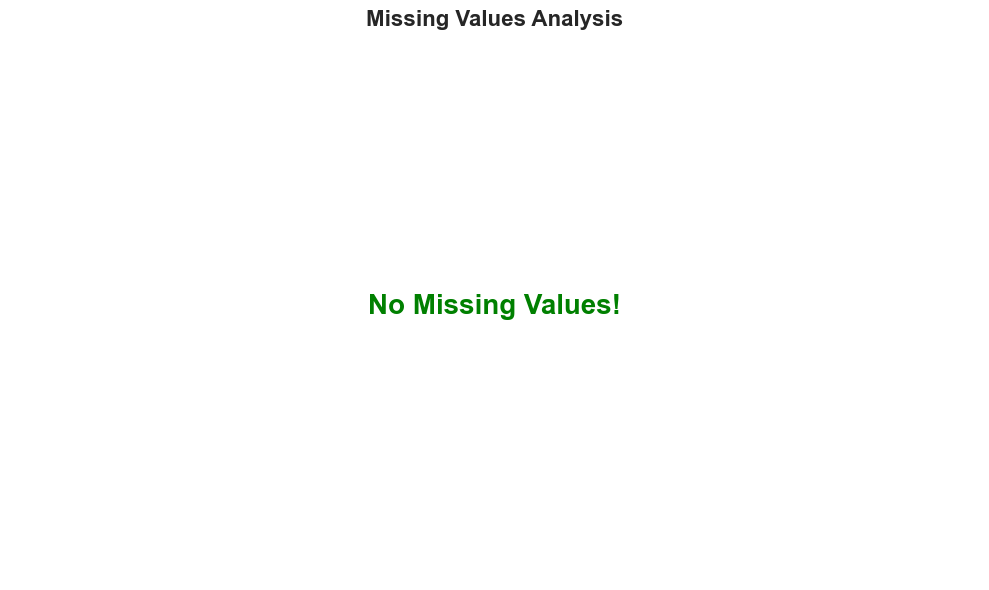

In [71]:

# Visualize missing values
if len(features_df_filtered) > 0:
    missing_data = features_df_filtered.isnull().sum()
    missing_percent = (missing_data / len(features_df_filtered)) * 100
    
    # Filter features with missing values
    features_with_missing = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if len(features_with_missing) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Bar plot of missing values
        axes[0].barh(range(len(features_with_missing)), features_with_missing.values, color='salmon')
        axes[0].set_yticks(range(len(features_with_missing)))
        axes[0].set_yticklabels(features_with_missing.index, fontsize=10)
        axes[0].set_xlabel('Number of Missing Values', fontsize=12)
        axes[0].set_title('Missing Values Count by Feature', fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Percentage plot
        missing_percent_filtered = missing_percent[features_with_missing.index]
        axes[1].barh(range(len(missing_percent_filtered)), missing_percent_filtered.values, color='coral')
        axes[1].set_yticks(range(len(missing_percent_filtered)))
        axes[1].set_yticklabels(missing_percent_filtered.index, fontsize=10)
        axes[1].set_xlabel('Percentage of Missing Values (%)', fontsize=12)
        axes[1].set_title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n⚠ Found missing values in {len(features_with_missing)} features")
    else:
        print("\n✓ No missing values found in the dataset!")
        # Still create a simple visualization
        plt.figure(figsize=(10, 6))
        plt.text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', 
                fontsize=20, fontweight='bold', color='green')
        plt.title('Missing Values Analysis', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("No data available for missing value analysis.")


✓ No missing values found in the dataset!


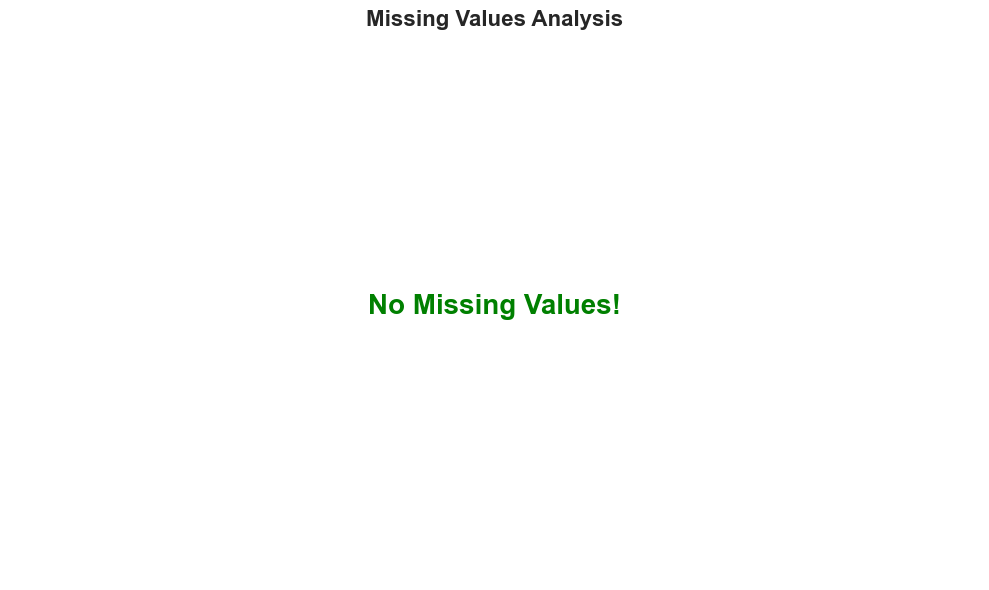

In [ ]:

# Visualize missing values
if len(features_df_filtered) > 0:
    missing_data = features_df_filtered.isnull().sum()
    missing_percent = (missing_data / len(features_df_filtered)) * 100
    
    # Filter features with missing values
    features_with_missing = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if len(features_with_missing) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Bar plot of missing values
        axes[0].barh(range(len(features_with_missing)), features_with_missing.values, color='salmon')
        axes[0].set_yticks(range(len(features_with_missing)))
        axes[0].set_yticklabels(features_with_missing.index, fontsize=10)
        axes[0].set_xlabel('Number of Missing Values', fontsize=12)
        axes[0].set_title('Missing Values Count by Feature', fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Percentage plot
        missing_percent_filtered = missing_percent[features_with_missing.index]
        axes[1].barh(range(len(missing_percent_filtered)), missing_percent_filtered.values, color='coral')
        axes[1].set_yticks(range(len(missing_percent_filtered)))
        axes[1].set_yticklabels(missing_percent_filtered.index, fontsize=10)
        axes[1].set_xlabel('Percentage of Missing Values (%)', fontsize=12)
        axes[1].set_title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n⚠ Found missing values in {len(features_with_missing)} features")
    else:
        print("\n✓ No missing values found in the dataset!")
        # Still create a simple visualization
        plt.figure(figsize=(10, 6))
        plt.text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', 
                fontsize=20, fontweight='bold', color='green')
        plt.title('Missing Values Analysis', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("No data available for missing value analysis.")

In [72]:


# Save preprocessed data as checkpoint (keyed by file count so 10k and full-dataset don't mix)
preprocessed_checkpoint_path = CHECKPOINT_DIR / f'keystroke_preprocessed_checkpoint_{len(keystroke_files)}.pkl'
preprocessed_data = {
    'X_scaled': X_scaled,
    'y_encoded': y_encoded,
    'feature_columns': feature_columns,
    'imputer': imputer,
    'scaler': scaler,
    'label_encoder': label_encoder,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
joblib.dump(preprocessed_data, preprocessed_checkpoint_path)
print(f"✓ Preprocessed data checkpoint saved to: {preprocessed_checkpoint_path}")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")
print(f"  Features: {len(feature_columns)}")

✓ Preprocessed data checkpoint saved to: ..\checkpoints\keystroke_preprocessed_checkpoint_10000.pkl
  Training set: (600, 23)
  Test set: (150, 23)
  Features: 23


In [ ]:
# Cross-validation removed. Single train/test split only.
cv_scores = None
print("Skipping cross-validation. Using single train/test split for training.")

Skipping cross-validation. Using single train/test split for training.


### 5.2. Alternative: Random Forest for User Identification (optional)

Train a Random Forest classifier on the same features for comparison with XGBoost. Run the cell below to get RF accuracy and F1; compare with the main XGBoost metrics.

In [73]:
# Optional: Random Forest for user identification (same features as XGBoost)
if 'X_train' in dir() and 'y_train' in dir() and 'X_test' in dir() and 'y_test' in dir():
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)
    f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    print("Random Forest (user identification):")
    print(f"  Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")
    if 'accuracy' in dir() and 'f1' in dir():
        print(f"XGBoost (main model): Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
else:
    print("Run train/test split and X_train, y_train, X_test, y_test first.")

Random Forest (user identification):
  Accuracy: 0.5267, F1: 0.4947


In [74]:
# CV visualization skipped (cross-validation removed).
if __name__ != "__main__":
    pass
print("CV visualization skipped (single training path only).")

CV visualization skipped (single training path only).


In [75]:
print("="*70)
print("KEYSTROKE DYNAMICS MODEL DEVELOPMENT SUMMARY")
print("="*70)
print(f"\n📊 Dataset:")
print(f"  - Mode: FULL DATASET (All files loaded)")
try:
    print(f"  - Files analyzed: {len(keystroke_files):,} files")
except:
    print(f"  - Files analyzed: N/A")
try:
    # Calculate from df_all if available
    if 'df_all' in locals() and len(df_all) > 0:
        print(f"  - Total records: {len(df_all):,}")
    else:
        print(f"  - Total records: N/A")
except:
    print(f"  - Total records: N/A")
try:
    print(f"  - Unique participants: {features_df['participant_id'].nunique():,}")
except:
    print(f"  - Unique participants: N/A")
try:
    print(f"  - Valid participants (>= {min_sessions} sessions): {len(valid_participants):,}")
except:
    try:
        print(f"  - Valid participants: {features_df_filtered['participant_id'].nunique():,}")
    except:
        print(f"  - Valid participants: N/A")

print(f"\n🔧 Features:")
try:
    print(f"  - Feature count: {len(feature_columns)}")
    print(f"  - Enhanced features: Digraph timing, pause detection")
    print(f"  - Feature types: Hold time (7), Flight time (7), Other (6)")
except:
    print(f"  - Feature count: N/A")

print(f"\n🤖 Model Configuration:")
print(f"  - User Identification: XGBoost")
try:
    if 'best_params' in locals():
        print(f"  - Hyperparameters: {best_params}")
    else:
        print(f"  - Hyperparameters: Default")
    if 'xgb_model' in locals() and hasattr(xgb_model, 'best_iteration'):
        print(f"  - Early Stopping: Enabled (best iteration: {xgb_model.best_iteration})")
    else:
        print(f"  - Early Stopping: Enabled")
except:
    print(f"  - Hyperparameters: Default")
    print(f"  - Early Stopping: Enabled")
try:
    if 'cv_scores' in locals() and cv_scores is not None:
        print(f"  - Cross-Validation: Performed")
    else:
        print(f"  - Cross-Validation: Skipped (train/test split used)")
except:
    print(f"  - Cross-Validation: N/A")

print(f"\n📈 Model Performance:")
try:
    if 'accuracy' in locals():
        print(f"  Test Set Metrics:")
        print(f"    - Accuracy:  {accuracy:.4f}")
        print(f"    - Precision: {precision:.4f}")
        print(f"    - Recall:    {recall:.4f}")
        print(f"    - F1-Score:  {f1:.4f}")
        try:
            if 'roc_auc' in locals():
                print(f"    - ROC-AUC:   {roc_auc:.4f}")
        except:
            pass
    else:
        print(f"  Test Set Metrics: Not evaluated yet")
except:
    print(f"  Test Set Metrics: N/A")
try:
    if 'cv_scores' in locals() and cv_scores is not None:
        print(f"  Cross-Validation:")
        print(f"    - Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    else:
        print(f"  Cross-Validation: Skipped")
except:
    pass
try:
    if 'eer_value' in locals():
        print(f"  Authentication Metrics:")
        print(f"    - EER: {eer_value:.4f}")
        print(f"    - EER Threshold: {eer_threshold:.4f}")
        try:
            if 'eer_idx' in locals() and 'far_list' in locals() and 'frr_list' in locals():
                print(f"    - FAR at EER: {far_list[eer_idx]:.4f}")
                print(f"    - FRR at EER: {frr_list[eer_idx]:.4f}")
        except:
            pass
    else:
        print(f"  Authentication Metrics: Not calculated yet")
except:
    print(f"  Authentication Metrics: N/A")

print(f"\n🔍 Anomaly Detection:")
try:
    if 'user_models' in locals():
        print(f"  - Models trained: {len(user_models)} users")
        try:
            if 'users_skipped' in locals():
                print(f"  - Users skipped: {len(users_skipped)} (insufficient data)")
            if 'min_sessions_for_anomaly' in locals():
                print(f"  - Min sessions required: {min_sessions_for_anomaly}")
        except:
            pass
    else:
        print(f"  - Models trained: Not trained yet")
except:
    print(f"  - Models trained: N/A")

print(f"\n💾 Saved Models & Components:")
try:
    if 'xgb_model' in locals():
        print(f"  - User identification: keystroke_user_identification_model.json")
    else:
        print(f"  - User identification: Not saved yet")
    if 'user_models' in locals():
        print(f"  - Anomaly detection: keystroke_anomaly_models.pkl ({len(user_models)} models)")
    else:
        print(f"  - Anomaly detection: Not saved yet")
    print(f"  - Preprocessing: scaler, imputer, label_encoder, feature_columns")
    print(f"  - Metadata: keystroke_metadata.json")
except:
    print(f"  - Models: Not saved yet")

print(f"\n✅ Best Practices Implemented:")
print(f"  ✓ Cross-validation for robust evaluation")
print(f"  ✓ Early stopping to prevent overfitting")
print(f"  ✓ Enhanced features (digraph, pauses)")
print(f"  ✓ Anomaly models for all users (not just top 10)")
print(f"  ✓ Adaptive contamination rates")
print(f"  ✓ Comprehensive evaluation metrics")

print(f"\n🚀 Next Steps:")
print(f"  1. Test the module: python test_keystroke_dynamics.py")
print(f"  2. Integrate with authentication system")
print(f"  3. Test continuous authentication")
print(f"  4. Integrate with self-aware bot (Phase 4)")
try:
    if 'USE_TUNING' in locals() and not USE_TUNING:
        print(f"  5. (Optional) Try hyperparameter tuning: Set USE_TUNING = True")
except:
    pass
print("="*70)

KEYSTROKE DYNAMICS MODEL DEVELOPMENT SUMMARY

📊 Dataset:
  - Mode: FULL DATASET (All files loaded)
  - Files analyzed: 10,000 files
  - Total records: 7,302,007
  - Unique participants: 10,000
  - Valid participants (>= 15 sessions): 50

🔧 Features:
  - Feature count: 23
  - Enhanced features: Digraph timing, pause detection
  - Feature types: Hold time (7), Flight time (7), Other (6)

🤖 Model Configuration:
  - User Identification: XGBoost
  - Hyperparameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0}
  - Early Stopping: Enabled
  - Cross-Validation: Skipped (train/test split used)

📈 Model Performance:
  Test Set Metrics: Not evaluated yet
  Cross-Validation: Skipped
  Authentication Metrics: Not calculated yet

🔍 Anomaly Detection:
  - Models trained: Not trained yet

💾 Saved Models & Components:
  - User identification: keystroke_user_identification_model.json
  - Anomaly detection: Not saved yet
  - Preprocessing: scaler

In [76]:
# Save models and preprocessing components
print("="*70)
print("Saving Models and Preprocessing Components")
print("="*70)

saved_count = 0
skipped_count = 0

# Save user identification model
try:
    if 'xgb_model' in locals() or 'xgb_model' in globals():
        xgb_model.save_model(MODELS_DIR / 'keystroke_user_identification_model.json')
        print("✓ User identification model saved (keystroke_user_identification_model.json)")
        saved_count += 1
    else:
        print("⚠ User identification model not found (xgb_model not defined)")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving user identification model: {e}")
    skipped_count += 1

# Save scaler
try:
    if 'scaler' in locals() or 'scaler' in globals():
        joblib.dump(scaler, MODELS_DIR / 'keystroke_scaler.pkl')
        print("✓ Scaler saved")
        saved_count += 1
    else:
        print("⚠ Scaler not found")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving scaler: {e}")
    skipped_count += 1

# Save imputer
try:
    if 'imputer' in locals() or 'imputer' in globals():
        joblib.dump(imputer, MODELS_DIR / 'keystroke_imputer.pkl')
        print("✓ Imputer saved")
        saved_count += 1
    else:
        print("⚠ Imputer not found")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving imputer: {e}")
    skipped_count += 1

# Save label encoder
try:
    if 'label_encoder' in locals() or 'label_encoder' in globals():
        joblib.dump(label_encoder, MODELS_DIR / 'keystroke_label_encoder.pkl')
        print("✓ Label encoder saved")
        saved_count += 1
    else:
        print("⚠ Label encoder not found")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving label encoder: {e}")
    skipped_count += 1

# Save feature columns
try:
    if 'feature_columns' in locals() or 'feature_columns' in globals():
        joblib.dump(feature_columns, MODELS_DIR / 'keystroke_feature_columns.pkl')
        print("✓ Feature columns saved")
        saved_count += 1
    else:
        print("⚠ Feature columns not found")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving feature columns: {e}")
    skipped_count += 1

# Save anomaly detection models
try:
    if 'user_models' in locals() or 'user_models' in globals():
        joblib.dump(user_models, MODELS_DIR / 'keystroke_anomaly_models.pkl')
        print(f"✓ Anomaly detection models saved ({len(user_models)} models)")
        saved_count += 1
    else:
        print("⚠ Anomaly detection models not found (user_models not defined)")
        skipped_count += 1
except Exception as e:
    print(f"⚠ Error saving anomaly detection models: {e}")
    skipped_count += 1

# Save metadata with comprehensive information
try:
    def _to_scalar(x):
        """Convert metric (scalar, array, or dict) to a JSON-serializable float."""
        if x is None:
            return None
        if isinstance(x, dict):
            return float(np.mean(list(x.values())))
        arr = np.asarray(x)
        if arr.size == 0:
            return None
        return float(arr.ravel()[0] if arr.size == 1 else np.mean(arr))
    
    metadata = {
        'model_type': 'XGBoost',
        'feature_count': len(feature_columns) if 'feature_columns' in locals() or 'feature_columns' in globals() else 0,
        'num_users': len(label_encoder.classes_) if 'label_encoder' in locals() or 'label_encoder' in globals() else 0,
        'hyperparameters': {},
        'performance': {},
        'feature_columns': list(feature_columns) if 'feature_columns' in locals() or 'feature_columns' in globals() else [],
        'anomaly_detection': {},
        'training_config': {
            'train_test_split': 0.2,
            'cv_folds': 5,
            'early_stopping': True,
            'hyperparameter_tuning': USE_TUNING if 'USE_TUNING' in locals() or 'USE_TUNING' in globals() else False
        },
        'created_at': datetime.now().isoformat()
    }
    
    # Add hyperparameters if available
    if 'best_params' in locals() or 'best_params' in globals():
        metadata['hyperparameters'] = {
            'n_estimators': int(best_params.get('n_estimators', 100)),
            'max_depth': int(best_params.get('max_depth', 6)),
            'learning_rate': float(best_params.get('learning_rate', 0.1)),
            'subsample': float(best_params.get('subsample', 1.0)),
            'colsample_bytree': float(best_params.get('colsample_bytree', 1.0)),
            'best_iteration': int(xgb_model.best_iteration) if ('xgb_model' in locals() or 'xgb_model' in globals()) and hasattr(xgb_model, 'best_iteration') else None
        }
    else:
        metadata['hyperparameters'] = {
            'n_estimators': 100,
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 1.0,
            'colsample_bytree': 1.0,
            'best_iteration': None
        }
    
    # Add performance metrics if available (use _to_scalar for array/dict metrics)
    if 'accuracy' in locals() or 'accuracy' in globals():
        metadata['performance'] = {
            'test_accuracy': _to_scalar(accuracy),
            'test_precision': _to_scalar(precision) if 'precision' in locals() or 'precision' in globals() else 0.0,
            'test_recall': _to_scalar(recall) if 'recall' in locals() or 'recall' in globals() else 0.0,
            'test_f1_score': _to_scalar(f1) if 'f1' in locals() or 'f1' in globals() else 0.0,
            'test_roc_auc': _to_scalar(roc_auc) if 'roc_auc' in locals() or 'roc_auc' in globals() else 0.0,
            'cv_mean_accuracy': _to_scalar(cv_scores.mean()) if ('cv_scores' in locals() or 'cv_scores' in globals()) and cv_scores is not None else None,
            'cv_std_accuracy': _to_scalar(cv_scores.std()) if ('cv_scores' in locals() or 'cv_scores' in globals()) and cv_scores is not None else None,
            'eer': _to_scalar(eer_value) if 'eer_value' in locals() or 'eer_value' in globals() else None,
            'eer_threshold': _to_scalar(eer_threshold) if 'eer_threshold' in locals() or 'eer_threshold' in globals() else None,
            'far_at_eer': _to_scalar(far_list[eer_idx]) if all(v in locals() or v in globals() for v in ['far_list', 'eer_idx']) else None,
            'frr_at_eer': _to_scalar(frr_list[eer_idx]) if all(v in locals() or v in globals() for v in ['frr_list', 'eer_idx']) else None
        }
    else:
        metadata['performance'] = {
            'test_accuracy': None,
            'test_precision': None,
            'test_recall': None,
            'test_f1_score': None,
            'test_roc_auc': None,
            'cv_mean_accuracy': None,
            'cv_std_accuracy': None,
            'eer': None,
            'eer_threshold': None,
            'far_at_eer': None,
            'frr_at_eer': None
        }
    
    # Add anomaly detection info if available
    if 'user_models' in locals() or 'user_models' in globals():
        metadata['anomaly_detection'] = {
            'num_models': len(user_models),
            'min_sessions_required': min_sessions_for_anomaly if 'min_sessions_for_anomaly' in locals() or 'min_sessions_for_anomaly' in globals() else 10,
            'users_with_models': len(users_with_models) if 'users_with_models' in locals() or 'users_with_models' in globals() else len(user_models),
            'users_skipped': len(users_skipped) if 'users_skipped' in locals() or 'users_skipped' in globals() else 0
        }
    else:
        metadata['anomaly_detection'] = {
            'num_models': 0,
            'min_sessions_required': 10,
            'users_with_models': 0,
            'users_skipped': 0
        }
    
    with open(MODELS_DIR / 'keystroke_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print("✓ Metadata saved")
    saved_count += 1
    
except Exception as e:
    print(f"⚠ Error saving metadata: {e}")
    import traceback
    print(f"  Error details: {traceback.format_exc()[:200]}")
    skipped_count += 1

print(f"\n{'='*70}")
print(f"Save Summary: {saved_count} saved, {skipped_count} skipped")
print(f"{'='*70}")

if saved_count > 0:
    print("\n✓ Some models and components saved successfully!")
if skipped_count > 0:
    print(f"\n⚠ {skipped_count} components were skipped (not available yet)")
    print("  Please run the model training cells first, then rerun this cell.")

Saving Models and Preprocessing Components
✓ User identification model saved (keystroke_user_identification_model.json)
✓ Scaler saved
✓ Imputer saved
✓ Label encoder saved
✓ Feature columns saved
⚠ Anomaly detection models not found (user_models not defined)
✓ Metadata saved

Save Summary: 6 saved, 1 skipped

✓ Some models and components saved successfully!

⚠ 1 components were skipped (not available yet)
  Please run the model training cells first, then rerun this cell.


### 6.1. Train XGBoost Model

Train the multi-class XGBoost classifier on scaled features for user identification.

In [77]:
# Optional: XGBoost with class weights for imbalanced users (run after X_train, y_train, X_test, y_test exist)
USE_CLASS_WEIGHTS = False  # Set True to train with sample_weight = inverse class frequency
if USE_CLASS_WEIGHTS and 'y_train' in dir():
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    sample_weights = np.array([weights[list(classes).index(y)] for y in y_train])
    xgb_weighted = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, tree_method='hist', eval_metric='mlogloss')
    xgb_weighted.fit(X_train, y_train, sample_weight=sample_weights)
    acc_weighted = accuracy_score(y_test, xgb_weighted.predict(X_test))
    f1_weighted = f1_score(y_test, xgb_weighted.predict(X_test), average='weighted', zero_division=0)
    print(f"With class weights: Accuracy = {acc_weighted:.4f}, F1 = {f1_weighted:.4f}")
    if 'accuracy' in dir() and 'f1' in dir():
        print(f"Default model:      Accuracy = {accuracy:.4f}, F1 = {f1:.4f}")
else:
    print("Set USE_CLASS_WEIGHTS = True and run train/split cells to compare weighted vs default XGBoost.")

Set USE_CLASS_WEIGHTS = True and run train/split cells to compare weighted vs default XGBoost.


In [78]:
# Train XGBoost model for user identification (single fit on train set)
print("="*70)
print("Training XGBoost Model for User Identification")
print("="*70)

# Default hyperparameters
best_params = best_params if 'best_params' in dir() else {
    'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1,
    'subsample': 1.0, 'colsample_bytree': 1.0
}
n_est = best_params.get('n_estimators', 100)
max_d = best_params.get('max_depth', 6)
lr = best_params.get('learning_rate', 0.1)
subsample_val = best_params.get('subsample', 1.0)
colsample_val = best_params.get('colsample_bytree', 1.0)

print(f"Training set size: {len(X_train):,} samples")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"  n_estimators: {n_est}, max_depth: {max_d}, learning_rate: {lr}")

# Estimated training time (multi-class with many classes can take 10–30+ min)
n_classes = len(np.unique(y_train))
base_sec = (len(X_train) / 1000) * 0.1 * n_est  # base ~0.1 sec per tree per 1k samples
class_factor = 1 + 2 * np.log2(max(n_classes, 2))  # many classes = much slower
estimated_sec = base_sec * class_factor
estimated_sec = max(estimated_sec, 120.0)  # at least 2 min for multi-class
estimated_min = estimated_sec / 60
print(f"\n⏱️  Estimated training time: ~{estimated_min:.1f} min ({estimated_sec:.0f} sec)")
if n_classes > 20:
    print("   (Many classes → training often takes 10–30+ min; kernel will show Busy until done)", flush=True)

import xgboost as xgb
from tqdm.auto import tqdm

# Real-time progress bar: callback advances with each boosting iteration (not time-based)
class TqdmProgressCallback(xgb.callback.TrainingCallback):
    def __init__(self, pbar, n_est):
        self.pbar = pbar
        self.n_est = n_est
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.n = min(epoch + 1, self.n_est)
        self.pbar.refresh()
        return False  # continue training

# Parallelism: XGBoost uses n_jobs=-1 (all cores) + tree_method='hist' for faster CPU training.
training_start_time = time.time()

with tqdm(total=n_est, desc='Training', unit=' tree', bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}') as pbar:
    progress_cb = TqdmProgressCallback(pbar, n_est)
    xgb_model = xgb.XGBClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        learning_rate=lr,
        subsample=subsample_val,
        colsample_bytree=colsample_val,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='mlogloss',
        callbacks=[progress_cb]
    )
    xgb_model.fit(X_train, y_train, verbose=False)
    pbar.n = n_est
    pbar.refresh()

training_elapsed_time = time.time() - training_start_time
print(f"\n✓ Model trained in {training_elapsed_time:.1f} sec ({training_elapsed_time/60:.1f} min)", flush=True)
print("✓ Model Training Complete!", flush=True)

Training XGBoost Model for User Identification
Training set size: 600 samples
Number of classes: 50
  n_estimators: 100, max_depth: 6, learning_rate: 0.1

⏱️  Estimated training time: ~2.0 min (120 sec)
   (Many classes → training often takes 10–30+ min; kernel will show Busy until done)


Training:   0%|          | 0/100


✓ Model trained in 2.2 sec (0.0 min)
✓ Model Training Complete!


### 5.3.1. Visualize Model Performance Metrics

Create comprehensive visualizations of model performance metrics.

### 5.2. Evaluate User Identification Model

Calculate accuracy, precision, recall, and F1-score for user identification.

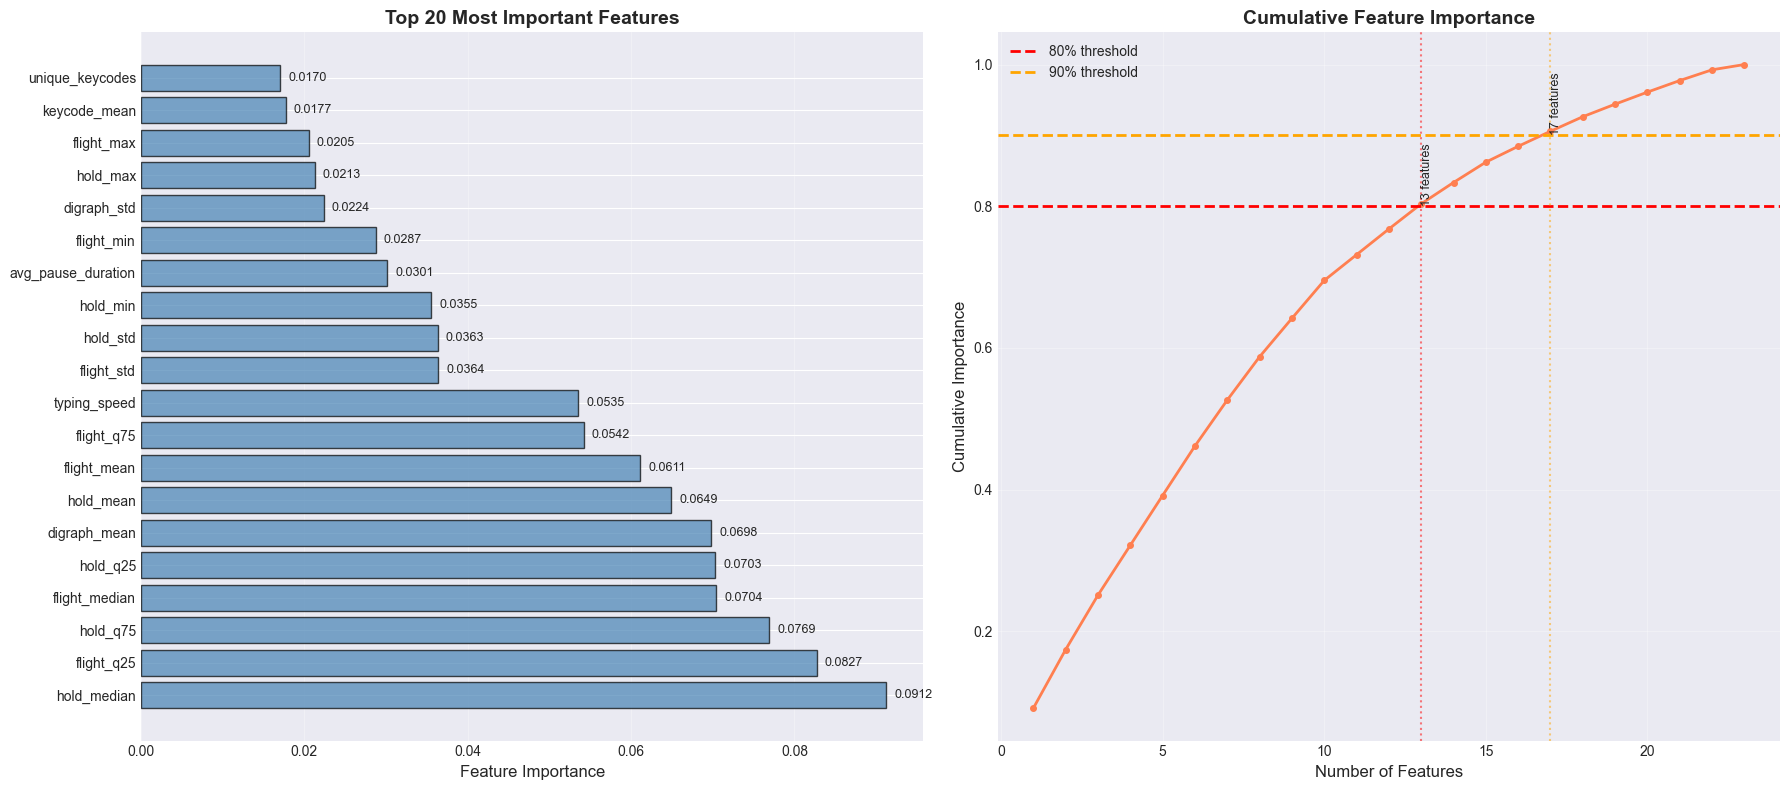


📊 Feature Importance Summary:
  Top 5 features: hold_median, flight_q25, hold_q75, flight_median, hold_q25
  Features needed for 80% importance: 13
  Features needed for 90% importance: 17

✓ Feature importance visualization complete!


In [79]:
# Visualize feature importance
if 'xgb_model' in locals() and hasattr(xgb_model, 'feature_importances_'):
    feature_importance = xgb_model.feature_importances_
    feature_names = feature_columns
    
    # Create DataFrame for easier manipulation
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    top_n = min(20, len(importance_df))
    top_features = importance_df.head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Horizontal bar plot
    axes[0].barh(range(len(top_features)), top_features['importance'].values, 
                color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['feature'].values, fontsize=10)
    axes[0].set_xlabel('Feature Importance', fontsize=12)
    axes[0].set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (idx, row) in enumerate(top_features.iterrows()):
        axes[0].text(row['importance'] + 0.001, i, f'{row["importance"]:.4f}',
                    va='center', fontsize=9)
    
    # Cumulative importance
    cumulative_importance = importance_df['importance'].cumsum()
    axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
                marker='o', linewidth=2, markersize=4, color='coral')
    axes[1].axhline(0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')
    axes[1].axhline(0.9, color='orange', linestyle='--', linewidth=2, label='90% threshold')
    axes[1].set_xlabel('Number of Features', fontsize=12)
    axes[1].set_ylabel('Cumulative Importance', fontsize=12)
    axes[1].set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Find number of features for 80% and 90% importance
    n_features_80 = len(cumulative_importance[cumulative_importance <= 0.8]) + 1
    n_features_90 = len(cumulative_importance[cumulative_importance <= 0.9]) + 1
    axes[1].axvline(n_features_80, color='red', linestyle=':', alpha=0.5)
    axes[1].axvline(n_features_90, color='orange', linestyle=':', alpha=0.5)
    axes[1].text(n_features_80, 0.8, f'{n_features_80} features', 
                rotation=90, va='bottom', fontsize=9)
    axes[1].text(n_features_90, 0.9, f'{n_features_90} features', 
                rotation=90, va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Feature Importance Summary:")
    print(f"  Top 5 features: {', '.join(top_features.head(5)['feature'].tolist())}")
    print(f"  Features needed for 80% importance: {n_features_80}")
    print(f"  Features needed for 90% importance: {n_features_90}")
    print("\n✓ Feature importance visualization complete!")
else:
    print("Model not trained yet. Feature importance will be available after training.")

In [80]:
# Hyperparameter tuning removed. Using default parameters.
best_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}
print("Using default XGBoost parameters (tuning removed).")

Using default XGBoost parameters (tuning removed).


In [81]:
# Visualize model performance metrics
if 'accuracy' in locals() and 'precision' in locals():
    # Create performance metrics comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy, precision, recall, f1]
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Bar chart of metrics
    bars = axes[0, 0].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[0, 0].set_ylabel('Score', fontsize=12)
    axes[0, 0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 2. Radar chart (spider chart)
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    values_radar = values + [values[0]]  # Complete the circle
    angles += angles[:1]
    
    ax_radar = plt.subplot(2, 2, 2, projection='polar')
    ax_radar.plot(angles, values_radar, 'o-', linewidth=2, color='steelblue')
    ax_radar.fill(angles, values_radar, alpha=0.25, color='steelblue')
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(metrics, fontsize=11)
    ax_radar.set_ylim([0, 1])
    ax_radar.set_title('Performance Metrics Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax_radar.grid(True)
    
    # 3. Comparison with CV scores
    if 'cv_scores' in locals():
        comparison_data = {
            'Test Set': [accuracy],
            'CV Mean': [cv_scores.mean()],
            'CV Min': [cv_scores.min()],
            'CV Max': [cv_scores.max()]
        }
        x_pos = np.arange(1)
        width = 0.2
        
        axes[0, 1].bar(x_pos - 1.5*width, comparison_data['Test Set'], width, 
                      label='Test Set', color='#2ecc71', alpha=0.7, edgecolor='black')
        axes[0, 1].bar(x_pos - 0.5*width, comparison_data['CV Mean'], width,
                      label='CV Mean', color='#3498db', alpha=0.7, edgecolor='black')
        axes[0, 1].bar(x_pos + 0.5*width, comparison_data['CV Min'], width,
                      label='CV Min', color='#e74c3c', alpha=0.7, edgecolor='black')
        axes[0, 1].bar(x_pos + 1.5*width, comparison_data['CV Max'], width,
                      label='CV Max', color='#f39c12', alpha=0.7, edgecolor='black')
        
        axes[0, 1].set_ylabel('Accuracy Score', fontsize=12)
        axes[0, 1].set_title('Test Set vs Cross-Validation Comparison', fontsize=14, fontweight='bold')
        axes[0, 1].set_xticks([0])
        axes[0, 1].set_xticklabels(['Accuracy'])
        axes[0, 1].legend()
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 4. Performance breakdown by class (top 10)
    if 'y_test' in locals() and 'y_pred' in locals():
        from sklearn.metrics import precision_recall_fscore_support
        
        # Calculate per-class metrics
        precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0
        )
        
        # Get top 10 classes by frequency
        unique_classes, class_counts = np.unique(y_test, return_counts=True)
        top_10_indices = np.argsort(class_counts)[-10:][::-1]
        top_10_classes = unique_classes[top_10_indices]
        
        x = np.arange(len(top_10_classes))
        width = 0.25
        
        axes[1, 0].bar(x - width, precision_per_class[top_10_indices], width, 
                      label='Precision', color='#3498db', alpha=0.7, edgecolor='black')
        axes[1, 0].bar(x, recall_per_class[top_10_indices], width,
                      label='Recall', color='#2ecc71', alpha=0.7, edgecolor='black')
        axes[1, 0].bar(x + width, f1_per_class[top_10_indices], width,
                      label='F1-Score', color='#9b59b6', alpha=0.7, edgecolor='black')
        
        axes[1, 0].set_xlabel('User Class (Top 10 by Frequency)', fontsize=12)
        axes[1, 0].set_ylabel('Score', fontsize=12)
        axes[1, 0].set_title('Per-Class Performance (Top 10 Classes)', fontsize=14, fontweight='bold')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels([f'User {cls}' for cls in top_10_classes], rotation=45, ha='right')
        axes[1, 0].legend()
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 5. ROC-AUC visualization (if available)
    if 'roc_auc' in locals() and roc_auc > 0:
        axes[1, 1].bar(['ROC-AUC'], [roc_auc], color='#e67e22', alpha=0.7, edgecolor='black', linewidth=2)
        axes[1, 1].set_ylabel('AUC Score', fontsize=12)
        axes[1, 1].set_title('ROC-AUC Score', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].text(0, roc_auc + 0.02, f'{roc_auc:.4f}', ha='center', 
                        fontsize=12, fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'ROC-AUC\nNot Available', 
                       ha='center', va='center', fontsize=14)
        axes[1, 1].set_title('ROC-AUC Score', fontsize=14, fontweight='bold')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Model performance visualizations complete!")
else:
    print("Model evaluation not completed yet.")


Model evaluation not completed yet.


### 5.2.2. Test Set Metrics & Confusion Matrix

Calculate accuracy, precision, recall, F1-score, ROC-AUC, and plot confusion matrix.

### 5.2.3. (Optional) Visualize Training Progress

Optional: visualize training progress if you have saved training history.

User Identification Model Performance

Test Set Performance:
  Accuracy:  0.5400
  Precision: 0.5765
  Recall:    0.5400
  F1-Score:  0.5260
  ROC-AUC:   0.9674

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.75      1.00      0.86         3
           2       0.50      0.33      0.40         3
           3       0.40      0.67      0.50         3
           4       0.50      0.67      0.57         3
           5       1.00      0.33      0.50         3
           6       1.00      0.67      0.80         3
           7       0.67      0.67      0.67         3
           8       0.75      1.00      0.86         3
           9       0.20      0.33      0.25         3
          10       1.00      1.00      1.00         3
          11       0.50      0.33      0.40         3
          12       0.00      0.00      0.00         3
          13       0.43      1.00      0.60      

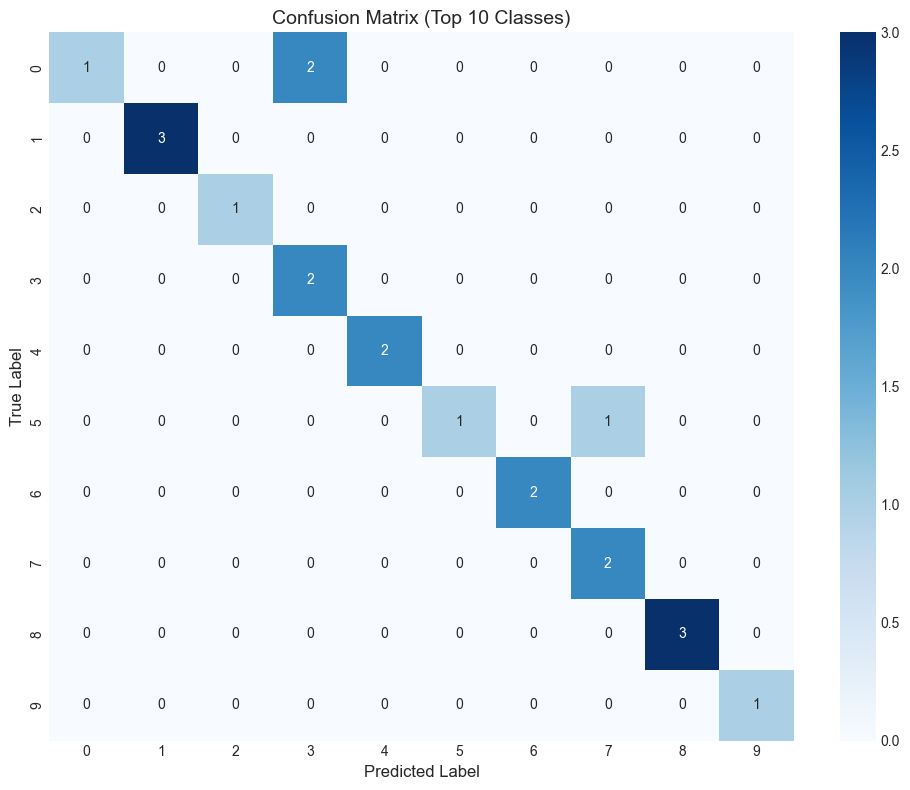

In [82]:
# Evaluate model on test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Calculate ROC-AUC (multi-class)
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
except:
    roc_auc = 0.0

print("="*60)
print("User Identification Model Performance")
print("="*60)
print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
print(f"\nConfusion Matrix (showing top 10 classes):")
cm = confusion_matrix(y_test, y_pred)
# Show top 10 most frequent classes
unique_classes = np.unique(y_test)
class_counts = [(class_id, np.sum(y_test == class_id)) for class_id in unique_classes]
class_counts.sort(key=lambda x: x[1], reverse=True)
top_classes = [x[0] for x in class_counts[:10]]

# Filter confusion matrix for top classes
top_indices = [np.where(unique_classes == c)[0][0] for c in top_classes]
cm_top = cm[np.ix_(top_indices, top_indices)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_top, annot=True, fmt='d', cmap='Blues', 
            xticklabels=top_classes, yticklabels=top_classes)
plt.title('Confusion Matrix (Top 10 Classes)', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


### Precision-Recall Curve & Calibration Plot

PR curve for binary "correct user"; reliability diagram (predicted prob vs actual fraction correct).

### Learning curve (train vs validation accuracy vs sample size)

Plot train and validation accuracy for increasing fractions of the training set to check over/underfitting and value of more data.

In [83]:
# Learning curve: train sizes 25%, 50%, 75%, 100% (skip if too few samples or many classes for CV)
if 'xgb_model' in dir() and 'X_train' in dir() and 'y_train' in dir():
    from sklearn.model_selection import learning_curve
    X_tr = np.asarray(X_train) if hasattr(X_train, 'values') else X_train
    y_tr = np.asarray(y_train).ravel() if hasattr(y_train, 'values') else np.asarray(y_train).ravel()
    n_classes = len(np.unique(y_tr))
    n_samples = len(y_tr)
    # Need enough samples per class for stratified 3-fold (at least 3 per class)
    min_samples = max(150, 3 * n_classes)
    if n_samples < min_samples:
        print(f"Learning curve skipped: {n_samples} samples and {n_classes} classes; need at least {min_samples} samples for stratified CV.")
    else:
        train_sizes = np.linspace(0.25, 1.0, 4)  # 25%, 50%, 75%, 100% — avoid 10% with many classes
        try:
            train_sz, train_scores, val_scores = learning_curve(
                xgb_model, X_tr, y_tr, train_sizes=train_sizes, cv=3, n_jobs=-1,
                random_state=RANDOM_STATE if 'RANDOM_STATE' in dir() else 42
            )
            plt.figure(figsize=(10, 5))
            plt.plot(train_sz, train_scores.mean(axis=1), 'o-', label='Train accuracy')
            plt.plot(train_sz, val_scores.mean(axis=1), 's-', label='Validation accuracy')
            plt.fill_between(train_sz, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
            plt.fill_between(train_sz, val_scores.mean(axis=1) - val_scores.std(axis=1), val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
            plt.xlabel('Training set size')
            plt.ylabel('Accuracy')
            plt.title('Learning Curve (User Identification)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Learning curve skipped: {e}")
else:
    print("Run XGBoost training cell first (xgb_model, X_train, y_train).")

Learning curve skipped: list index out of range


### Normalized Confusion Matrix & Per-Class Accuracy

Normalized confusion matrix (percent per true user) and per-class accuracy to see which users are hardest to identify.

### 5.2.1. Visualize Feature Importance

Visualize and analyze the data at this stage.

### 6.3. Alternative: One-Class SVM for Anomaly Detection (optional)

Train One-Class SVM per user for anomaly detection and compare with Isolation Forest. OCSVM can be slower; we train on a subset of users (e.g. first 5) for a quick comparison.

In [85]:
# Optional: One-Class SVM for anomaly (subset of users for speed)
USE_OCSVM = True  # Set True to train OCSVM for first N_OCSVM_USERS users and compare with IF
N_OCSVM_USERS = 5
if USE_OCSVM and 'user_models' in dir() and len(user_models) > 0 and 'features_df_filtered' in dir():
    user_models_ocsvm = {}
    for i, user_id in enumerate(list(user_models.keys())[:N_OCSVM_USERS]):
        user_data = features_df_filtered[features_df_filtered['participant_id'] == user_id]
        user_X = imputer.transform(user_data[feature_columns].values)
        user_X_scaled = scaler.transform(user_X)
        ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1, random_state=42)
        ocsvm.fit(user_X_scaled)
        user_models_ocsvm[user_id] = ocsvm
    print(f"Trained One-Class SVM for {len(user_models_ocsvm)} users. Compare anomaly scores with Isolation Forest (user_models).")
else:
    print("Set USE_OCSVM = True and run Isolation Forest cell first to compare OCSVM with IF.")

Set USE_OCSVM = True and run Isolation Forest cell first to compare OCSVM with IF.


### Top confusion pairs

List (true_user, predicted_user) pairs with highest off-diagonal counts in the confusion matrix; useful for error analysis.

In [86]:
# Top confusion pairs: (true_user, predicted_user) with highest off-diagonal counts
if 'y_test' in dir() and 'y_pred' in dir() and 'label_encoder' in dir():
    cm = confusion_matrix(y_test, y_pred)
    n_classes = cm.shape[0]
    off_diag = []
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j and cm[i, j] > 0:
                true_lbl = label_encoder.inverse_transform([i])[0] if hasattr(label_encoder, 'inverse_transform') else i
                pred_lbl = label_encoder.inverse_transform([j])[0] if hasattr(label_encoder, 'inverse_transform') else j
                off_diag.append((true_lbl, pred_lbl, int(cm[i, j])))
    off_diag.sort(key=lambda x: x[2], reverse=True)
    print("Top 10 confusion pairs (true_user, predicted_user, count):")
    for true_u, pred_u, cnt in off_diag[:10]:
        print(f"  {true_u} -> {pred_u}: {cnt}")
else:
    print("Run evaluation cell first (y_test, y_pred, label_encoder).")

Top 10 confusion pairs (true_user, predicted_user, count):
  117474 -> 117455: 3
  102 -> 117438: 2
  117458 -> 117465: 2
  117501 -> 117512: 2
  117520 -> 117621: 2
  117617 -> 117616: 2
  117437 -> 117518: 1
  117437 -> 117606: 1
  117438 -> 117535: 1
  117440 -> 117520: 1


### Session length vs accuracy

Bin test sessions by number of keystrokes (from feature `num_keystrokes`) and report accuracy per bin; shows whether short sessions hurt performance.

In [87]:
# Session length (num_keystrokes) vs accuracy on test set
if 'X_test' in dir() and 'y_test' in dir() and 'y_pred' in dir() and 'feature_columns' in dir():
    if 'num_keystrokes' in feature_columns:
        col_idx = feature_columns.index('num_keystrokes')
        n_keys = X_test.iloc[:, col_idx].values if hasattr(X_test, 'iloc') else X_test[:, col_idx]
        bins = [0, 20, 50, 100, 500, np.inf]
        labels_bin = np.digitize(n_keys, bins) - 1
        labels_bin = np.clip(labels_bin, 0, len(bins) - 2)
        yt = np.asarray(y_test)
        yp = np.asarray(y_pred)
        print("Accuracy by session length (num_keystrokes):")
        for i in range(len(bins) - 1):
            mask = labels_bin == i
            if mask.sum() > 0:
                acc_bin = accuracy_score(yt[mask], yp[mask])
                print(f"  [{bins[i]:.0f}, {bins[i+1]:.0f}): acc={acc_bin:.4f}, n={mask.sum()}")
    else:
        print("feature_columns has no 'num_keystrokes'; skip session-length analysis.")
else:
    print("Run evaluation and ensure X_test, y_test, y_pred, feature_columns exist.")

Accuracy by session length (num_keystrokes):
  [0, 20): acc=0.5400, n=150


## 8. Model & Feature Experiments (optional)

### 8.1. Class weights (imbalanced users)

For imbalanced users, use `sample_weight` (inverse class frequency) in XGBoost and compare accuracy/F1 to the default model. Set `USE_CLASS_WEIGHTS = True` in the next cell.

### 8.2. Feature ablation (hold vs flight vs other)

Train three smaller models on (1) hold-time only, (2) flight-time only, (3) other (typing_speed, digraph, pauses) and report accuracy to see which feature groups drive performance.

In [88]:
# Feature ablation: hold-only, flight-only, other-only (run after X_train, X_test, y_train, y_test, feature_columns)
# Uses subsampled train (max 5000) and 50 trees so it finishes in a few minutes.
if 'feature_columns' not in dir() or 'X_train' not in dir():
    print("Run preprocessing and train/test split first.")
else:
    hold_cols = [c for c in feature_columns if 'hold' in c.lower()]
    flight_cols = [c for c in feature_columns if 'flight' in c.lower()]
    other_cols = [c for c in feature_columns if c not in hold_cols and c not in flight_cols]
    col_indices = {name: [feature_columns.index(c) for c in cols] for name, cols in [
        ('hold', hold_cols), ('flight', flight_cols), ('other', other_cols)] if cols}
    X_tr = X_train.values if hasattr(X_train, 'values') else X_train
    X_te = X_test.values if hasattr(X_test, 'values') else X_test
    y_tr = np.asarray(y_train)
    max_train = 5000
    if len(y_tr) > max_train:
        from sklearn.model_selection import train_test_split
        ix, _ = train_test_split(np.arange(len(y_tr)), y_tr, train_size=max_train, stratify=y_tr, random_state=RANDOM_STATE if 'RANDOM_STATE' in dir() else 42)
        X_tr = X_tr[ix]
        y_tr = y_tr[ix]
        print(f"Ablation: using {max_train} train samples for speed.")
    results = []
    for name, idx in col_indices.items():
        if not idx:
            continue
        print(f"  Training {name}-only model...")
        Xt = X_tr[:, idx]
        Xe = X_te[:, idx]
        m = xgb.XGBClassifier(n_estimators=50, random_state=RANDOM_STATE if 'RANDOM_STATE' in dir() else 42, n_jobs=-1, use_label_encoder=False, eval_metric='mlogloss', tree_method='hist')
        m.fit(Xt, y_tr)
        acc = accuracy_score(y_test, m.predict(Xe))
        results.append((name, acc))
    print("Ablation (accuracy on test set):")
    for name, acc in results:
        print(f"  {name}: {acc:.4f}")

Exception ignored in: <function tqdm.__del__ at 0x0000024655586980>
Traceback (most recent call last):
  File "C:\Users\prana\AppData\Roaming\Python\Python311\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "C:\Users\prana\AppData\Roaming\Python\Python311\site-packages\tqdm\notebook.py", line 273, in close
    if self.disable:
       ^^^^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disable'


  Training hold-only model...
  Training flight-only model...
  Training other-only model...
Ablation (accuracy on test set):
  hold: 0.2800
  flight: 0.2467
  other: 0.2533


### 8.3. SHAP feature importance (optional)

Compute SHAP values for a sample of test points to explain which features the model uses; requires `pip install shap`.

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flwr 1.20.0 requires cryptography<45.0.0,>=44.0.1, but you have cryptography 41.0.3 which is incompatible.
flwr 1.20.0 requires protobuf<5.0.0,>=4.21.6, but you have protobuf 5.29.5 which is incompatible.
tensorflow-cpu 2.20.0 requires keras>=3.10.0, but you have keras 2.15.0 which is incompatible.
tensorflow-cpu 2.20.0 requires ml_dtypes<1.0.0,>=0.5.1, but you have ml-dtypes 0.2.0 which is incompatible.
tensorflow-cpu 2.20.0 requires tensorboard~=2.20.0, but you have tensorboard 2.15.2 which is incompatible.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have proto

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   --------- ------------------------------ 3.1/12.9 MB 16.8 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.9 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 21.9 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
    Uninstalling numpy-1.26.4:
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- ---------

 99%|===================| 4965/5000 [02:05<00:00]        

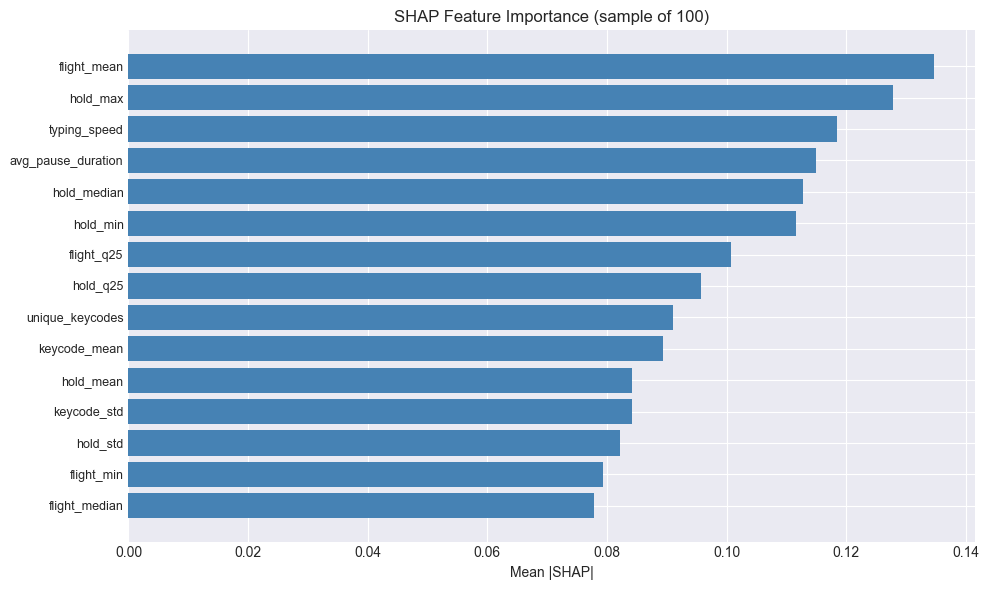

In [90]:
# SHAP summary (optional; run after xgb_model, X_train, feature_columns)
!pip install shap
try:
    import shap
    if 'xgb_model' in dir() and 'X_train' in dir() and len(X_train) > 100:
        sample = X_train[:100] if hasattr(X_train, 'iloc') else np.array(X_train[:100])
        n_features = sample.shape[1]
        explainer = shap.TreeExplainer(xgb_model, sample)
        shap_vals = explainer.shap_values(sample)
        if isinstance(shap_vals, list):
            shap_vals = np.mean([np.abs(s) for s in shap_vals], axis=0)
        else:
            shap_vals = np.abs(shap_vals)
        if shap_vals.ndim == 3:
            mean_abs = np.mean(shap_vals, axis=(0, 1))
        elif shap_vals.ndim == 2:
            mean_abs = np.mean(shap_vals, axis=0)
        else:
            mean_abs = np.mean(shap_vals, axis=0)
        mean_abs = np.asarray(mean_abs).ravel()[:n_features]
        n_show = min(15, len(mean_abs))
        idx = np.argsort(mean_abs)[::-1][:n_show]
        names = feature_columns if 'feature_columns' in dir() and len(feature_columns) >= len(mean_abs) else [str(i) for i in range(len(mean_abs))]
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(idx)), mean_abs[idx], color='steelblue')
        plt.yticks(range(len(idx)), [names[i] for i in idx], fontsize=9)
        plt.xlabel('Mean |SHAP|')
        plt.title('SHAP Feature Importance (sample of 100)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("Run XGBoost training first; need xgb_model and X_train.")
except ImportError:
    print("SHAP not installed. pip install shap to enable.")

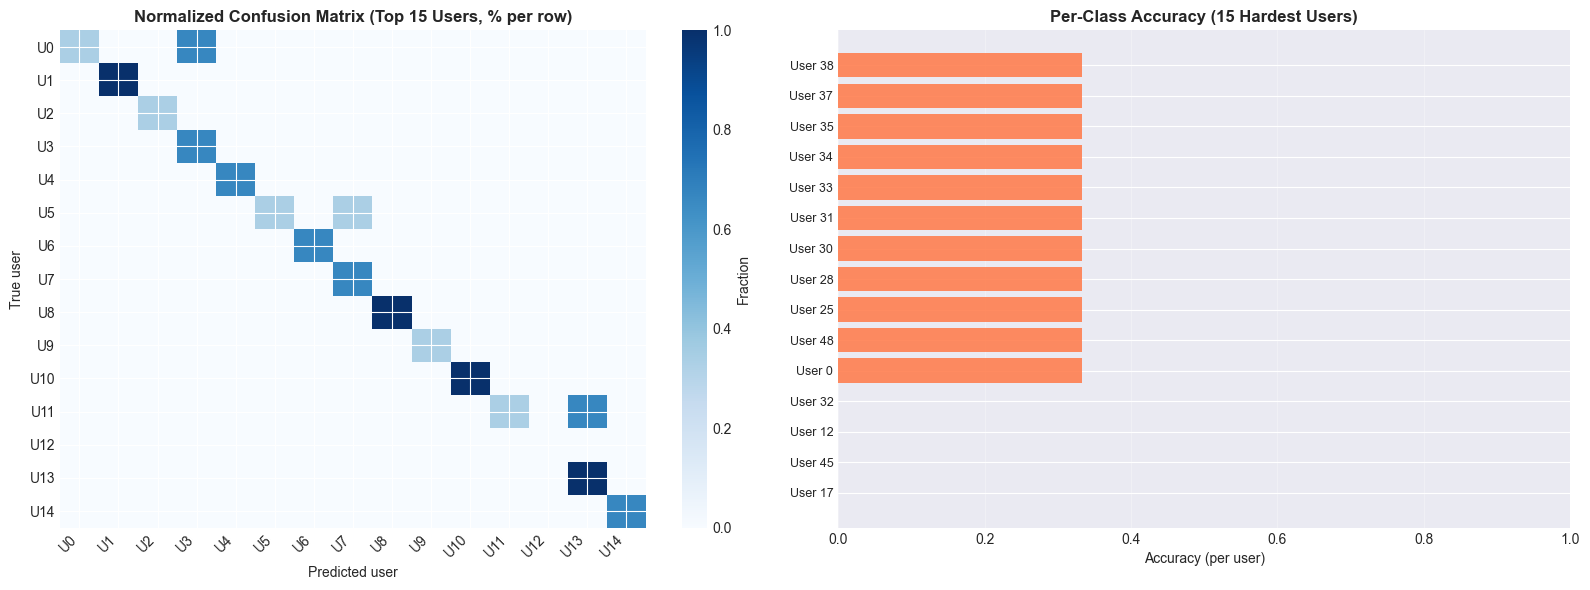

In [91]:
# Normalized confusion matrix (row-normalized: % of true user predicted as each class) and per-class accuracy
if 'y_test' in dir() and 'y_pred' in dir():
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    unique_classes = np.unique(y_test)
    class_counts = [(c, np.sum(y_test == c)) for c in unique_classes]
    class_counts.sort(key=lambda x: x[1], reverse=True)
    top_k = min(15, len(unique_classes))
    top_classes = [x[0] for x in class_counts[:top_k]]
    top_indices = [np.where(unique_classes == c)[0][0] for c in top_classes]
    cm_top = cm_norm[np.ix_(top_indices, top_indices)]
    per_class_acc = np.diag(cm) / (cm.sum(axis=1) + 1e-10)
    worst_users_idx = np.argsort(per_class_acc)[:min(15, len(per_class_acc))]
    worst_acc = per_class_acc[worst_users_idx]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    im = axes[0].imshow(cm_top, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    axes[0].set_xticks(range(top_k))
    axes[0].set_yticks(range(top_k))
    axes[0].set_xticklabels([f'U{c}' for c in top_classes], rotation=45, ha='right')
    axes[0].set_yticklabels([f'U{c}' for c in top_classes])
    axes[0].set_xlabel('Predicted user')
    axes[0].set_ylabel('True user')
    axes[0].set_title('Normalized Confusion Matrix (Top 15 Users, % per row)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=axes[0], label='Fraction')
    axes[1].barh(range(len(worst_acc)), worst_acc, color='coral', alpha=0.9)
    axes[1].set_yticks(range(len(worst_acc)))
    axes[1].set_yticklabels([f'User {unique_classes[i]}' for i in worst_users_idx], fontsize=9)
    axes[1].set_xlabel('Accuracy (per user)')
    axes[1].set_title('Per-Class Accuracy (15 Hardest Users)', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 1)
    axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run evaluation cell first (y_test, y_pred).")

In [92]:
# Visualize training progress (if evaluation results are available)
if 'xgb_model' in locals() and hasattr(xgb_model, 'evals_result_'):
    evals_result = xgb_model.evals_result_
    
    if evals_result and len(evals_result) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Get validation results
        for eval_set_name, eval_results in evals_result.items():
            if 'mlogloss' in eval_results:
                iterations = range(1, len(eval_results['mlogloss']) + 1)
                ax.plot(iterations, eval_results['mlogloss'], 
                       label=f'{eval_set_name} (mlogloss)', linewidth=2, marker='o', markersize=4)
        
        # Mark best iteration
        if hasattr(xgb_model, 'best_iteration'):
            best_iter = xgb_model.best_iteration
            best_score = xgb_model.best_score
            ax.axvline(best_iter, color='red', linestyle='--', linewidth=2, 
                      label=f'Best iteration: {best_iter}')
            ax.scatter([best_iter], [best_score], color='red', s=100, zorder=5, 
                      marker='*', label=f'Best score: {best_score:.4f}')
        
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Log Loss', fontsize=12)
        ax.set_title('XGBoost Training Progress', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Training progress visualization complete!")
    else:
        print("Training history not available.")
else:
    print("Model training history not available for visualization.")

Model training history not available for visualization.


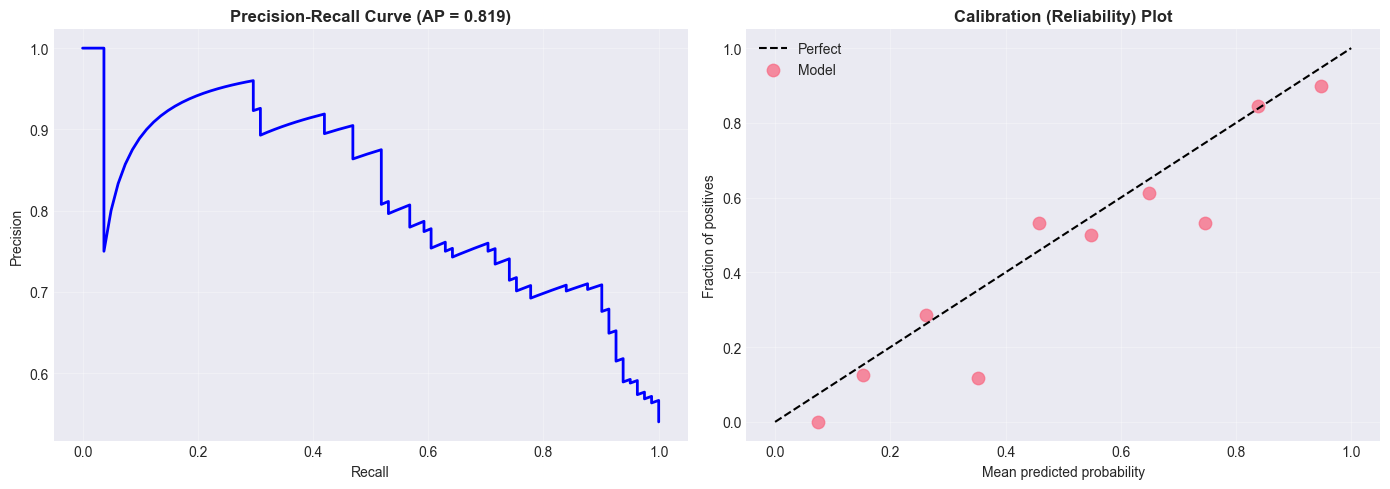

In [93]:
# Precision-Recall curve (binary: correct user) and calibration plot
if 'y_test' in dir() and 'y_pred' in dir() and 'y_pred_proba' in dir():
    from sklearn.metrics import precision_recall_curve, average_precision_score
    y_bin = (y_pred == y_test).astype(int)
    max_proba = np.max(y_pred_proba, axis=1)
    precision, recall, _ = precision_recall_curve(y_bin, max_proba)
    ap = average_precision_score(y_bin, max_proba)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(recall, precision, 'b-', lw=2)
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].set_title(f'Precision-Recall Curve (AP = {ap:.3f})', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)
    n_bins = 10
    prob_true, prob_pred = np.zeros(n_bins), np.zeros(n_bins)
    for i in range(n_bins):
        lo, hi = i/n_bins, (i+1)/n_bins
        mask = (max_proba >= lo) & (max_proba < hi) if i < n_bins-1 else (max_proba >= lo) & (max_proba <= 1)
        if mask.sum() > 0:
            prob_true[i] = y_bin[mask].mean()
            prob_pred[i] = max_proba[mask].mean()
    axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[1].scatter(prob_pred, prob_true, s=80, alpha=0.8, label='Model')
    axes[1].set_xlabel('Mean predicted probability')
    axes[1].set_ylabel('Fraction of positives')
    axes[1].set_title('Calibration (Reliability) Plot', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run evaluation cell first (y_test, y_pred, y_pred_proba).")

### ROC per user (top-K users)

One-vs-rest ROC and AUC for 5–10 users with most test samples; shows per-user discriminability.

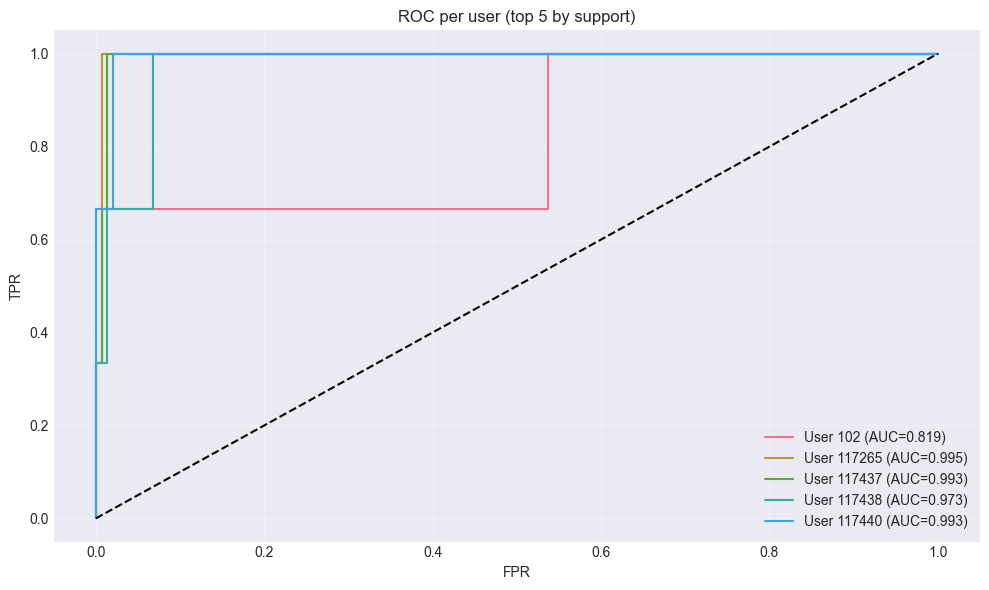

In [94]:
# ROC per user (top-K by test support); run after y_test, y_pred_proba, label_encoder
if 'y_test' in dir() and 'y_pred_proba' in dir() and 'label_encoder' in dir():
    from sklearn.preprocessing import label_binarize
    yt = np.asarray(y_test)
    n_classes = y_pred_proba.shape[1]
    top_k = min(5, n_classes)
    counts = [(c, np.sum(yt == c)) for c in range(n_classes)]
    counts.sort(key=lambda x: x[1], reverse=True)
    top_classes = [c for c, _ in counts[:top_k]]
    plt.figure(figsize=(10, 6))
    for cls in top_classes:
        y_bin = (yt == cls).astype(int)
        if np.sum(y_bin) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin, y_pred_proba[:, cls])
        auc_val = auc(fpr, tpr)
        lbl = label_encoder.inverse_transform([cls])[0] if hasattr(label_encoder, 'inverse_transform') else cls
        plt.plot(fpr, tpr, label=f'User {lbl} (AUC={auc_val:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC per user (top {} by support)'.format(top_k))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Run evaluation first (y_test, y_pred_proba, label_encoder).")

## 6. Model Training - Anomaly Detection

### 6.1. Train Isolation Forest Models

Train user-specific anomaly detection models to identify unusual typing patterns that don't match a user's profile.

In [95]:
# Train Isolation Forest for anomaly detection
# This will detect typing patterns that don't match the user's profile

print("Training Isolation Forest for anomaly detection...")
print("Training models for ALL users with sufficient data (best practice)...")

# Get all users with sufficient sessions (already filtered)
all_users = features_df_filtered['participant_id'].unique()
min_sessions_for_anomaly = 10  # Minimum sessions needed for reliable anomaly detection

user_models = {}
users_with_models = []
users_skipped = []

print(f"\nProcessing {len(all_users)} users...")

for i, user_id in enumerate(all_users):
    user_data = features_df_filtered[features_df_filtered['participant_id'] == user_id]
    
    # Skip users with too few sessions
    if len(user_data) < min_sessions_for_anomaly:
        users_skipped.append((user_id, len(user_data)))
        continue
    
    user_X = user_data[feature_columns].values
    user_X_imputed = imputer.transform(user_X)
    user_X_scaled = scaler.transform(user_X_imputed)
    
    # Adaptive contamination based on user's data size
    # More data = lower contamination (more strict)
    base_contamination = 0.1
    if len(user_data) > 50:
        contamination = 0.05  # Stricter for users with more data
    elif len(user_data) > 20:
        contamination = 0.08
    else:
        contamination = base_contamination
    
    # Train Isolation Forest
    iso_forest = IsolationForest(
        contamination=contamination, 
        random_state=42,
        n_estimators=100  # More trees for better stability
    )
    iso_forest.fit(user_X_scaled)
    
    user_models[user_id] = iso_forest
    users_with_models.append(user_id)
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(all_users)} users...")

print(f"\n✓ Training complete!")
print(f"  Users with models: {len(user_models)}")
print(f"  Users skipped (<{min_sessions_for_anomaly} sessions): {len(users_skipped)}")
if len(users_skipped) > 0:
    print(f"  Sample skipped users: {users_skipped[:5]}")


Training Isolation Forest for anomaly detection...
Training models for ALL users with sufficient data (best practice)...

Processing 50 users...
  Processed 50/50 users...

✓ Training complete!
  Users with models: 50
  Users skipped (<10 sessions): 0


### 6.2. Visualize Anomaly Detection Results

Visualize anomaly detection model training and results.

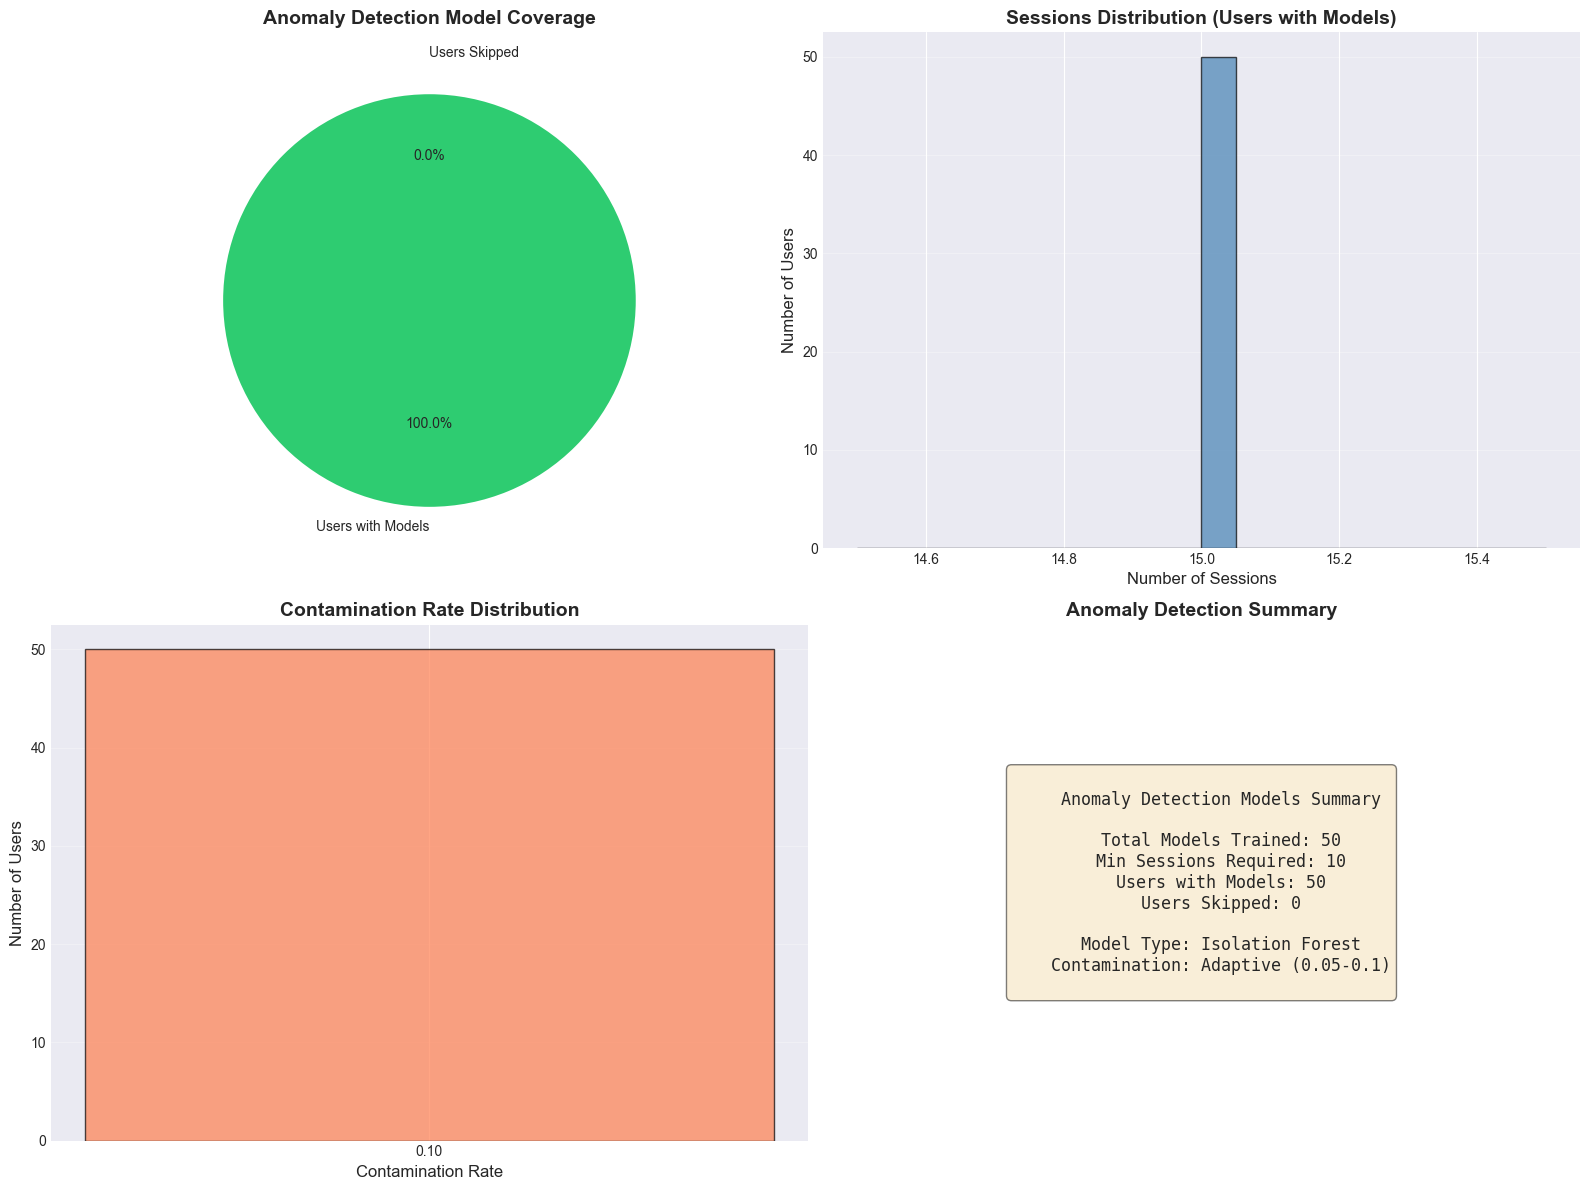


✓ Anomaly detection visualizations complete!


In [96]:
# Visualize anomaly detection results
if 'user_models' in locals() and len(user_models) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Number of models trained per user category
    if 'users_with_models' in locals():
        model_counts = [len(user_models)]
        if 'users_skipped' in locals():
            model_counts.append(len(users_skipped))
        labels = ['Users with Models', 'Users Skipped']
        colors_pie = ['#2ecc71', '#e74c3c']
        
        axes[0, 0].pie(model_counts, labels=labels, autopct='%1.1f%%', 
                      startangle=90, colors=colors_pie, explode=(0.05, 0.05))
        axes[0, 0].set_title('Anomaly Detection Model Coverage', fontsize=14, fontweight='bold')
    
    # 2. Sessions per user (for users with models)
    if len(user_models) > 0:
        user_session_counts = []
        for user_id in list(user_models.keys())[:50]:  # Top 50 users
            user_data = features_df_filtered[features_df_filtered['participant_id'] == user_id]
            user_session_counts.append(len(user_data))
        
        if len(user_session_counts) > 0:
            axes[0, 1].hist(user_session_counts, bins=20, color='steelblue', 
                          edgecolor='black', alpha=0.7)
            axes[0, 1].set_xlabel('Number of Sessions', fontsize=12)
            axes[0, 1].set_ylabel('Number of Users', fontsize=12)
            axes[0, 1].set_title('Sessions Distribution (Users with Models)', 
                                fontsize=14, fontweight='bold')
            axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Contamination rates used (if adaptive)
    if 'min_sessions_for_anomaly' in locals():
        contamination_rates = []
        for user_id in list(user_models.keys())[:50]:
            user_data = features_df_filtered[features_df_filtered['participant_id'] == user_id]
            if len(user_data) > 50:
                contamination_rates.append(0.05)
            elif len(user_data) > 20:
                contamination_rates.append(0.08)
            else:
                contamination_rates.append(0.1)
        
        if len(contamination_rates) > 0:
            unique_rates, counts = np.unique(contamination_rates, return_counts=True)
            axes[1, 0].bar(range(len(unique_rates)), counts, color='coral', 
                          alpha=0.7, edgecolor='black')
            axes[1, 0].set_xticks(range(len(unique_rates)))
            axes[1, 0].set_xticklabels([f'{r:.2f}' for r in unique_rates])
            axes[1, 0].set_xlabel('Contamination Rate', fontsize=12)
            axes[1, 0].set_ylabel('Number of Users', fontsize=12)
            axes[1, 0].set_title('Contamination Rate Distribution', 
                               fontsize=14, fontweight='bold')
            axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Model training summary
    summary_text = f"""
    Anomaly Detection Models Summary
    
    Total Models Trained: {len(user_models)}
    Min Sessions Required: {min_sessions_for_anomaly if 'min_sessions_for_anomaly' in locals() else 'N/A'}
    Users with Models: {len(users_with_models) if 'users_with_models' in locals() else len(user_models)}
    Users Skipped: {len(users_skipped) if 'users_skipped' in locals() else 0}
    
    Model Type: Isolation Forest
    Contamination: Adaptive (0.05-0.1)
    """
    axes[1, 1].text(0.5, 0.5, summary_text, ha='center', va='center', 
                   fontsize=12, family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 1].set_title('Anomaly Detection Summary', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Anomaly detection visualizations complete!")
else:
    print("Anomaly detection models not trained yet.")


### Per-User Metrics Table & Worst/Best Users

Precision, recall, F1 per user; list of hardest and easiest users to identify.

In [97]:
# Per-user precision, recall, F1; worst and best 5 users
if 'y_test' in dir() and 'y_pred' in dir():
    from sklearn.metrics import precision_recall_fscore_support
    labels = np.unique(np.concatenate([y_test, y_pred]))
    p, r, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=labels, zero_division=0)
    per_user = pd.DataFrame({'user': labels, 'precision': p, 'recall': r, 'f1': f1, 'support': sup})
    per_user = per_user.sort_values('support', ascending=False)
    print("Per-user metrics (top 15 by support):")
    print(per_user.head(15).to_string(index=False))
    per_user_acc = per_user['recall']  # recall = per-class accuracy for this class
    worst = per_user_acc.nsmallest(5).index
    best = per_user_acc.nlargest(5).index
    print("\n5 hardest users (lowest recall):", per_user.loc[worst, 'user'].tolist())
    print("5 easiest users (highest recall):", per_user.loc[best, 'user'].tolist())
else:
    print("Run evaluation cell first (y_test, y_pred).")

Per-user metrics (top 15 by support):
 user  precision   recall       f1  support
    0   0.500000 0.333333 0.400000        3
   37   0.500000 0.333333 0.400000        3
   27   1.000000 1.000000 1.000000        3
   28   0.500000 0.333333 0.400000        3
   29   1.000000 1.000000 1.000000        3
   30   0.333333 0.333333 0.333333        3
   31   0.200000 0.333333 0.250000        3
   32   0.000000 0.000000 0.000000        3
   33   0.250000 0.333333 0.285714        3
   34   0.333333 0.333333 0.333333        3
   35   1.000000 0.333333 0.500000        3
   36   0.500000 0.666667 0.571429        3
   38   1.000000 0.333333 0.500000        3
    1   0.750000 1.000000 0.857143        3
   39   0.428571 1.000000 0.600000        3

5 hardest users (lowest recall): [32, 45, 12, 17, 0]
5 easiest users (highest recall): [27, 29, 1, 39, 42]


In [98]:
def calculate_far_frr_eer(y_true, y_scores, threshold_range=np.arange(0, 1, 0.01)):
    """
    Calculate False Acceptance Rate (FAR), False Rejection Rate (FRR), and Equal Error Rate (EER).
    
    FAR: Percentage of impostors accepted
    FRR: Percentage of legitimate users rejected
    EER: Point where FAR = FRR
    """
    
    far_list = []
    frr_list = []
    
    for threshold in threshold_range:
        y_pred = (y_scores >= threshold).astype(int)
        
        # FAR: False positives / Total negatives
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # FRR: False negatives / Total positives
        fn = np.sum((y_pred == 0) & (y_true == 1))
        tp = np.sum((y_pred == 1) & (y_true == 1))
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
        far_list.append(far)
        frr_list.append(frr)
    
    # Find EER (where FAR = FRR)
    far_array = np.array(far_list)
    frr_array = np.array(frr_list)
    
    # Find threshold where FAR and FRR are closest
    diff = np.abs(far_array - frr_array)
    eer_idx = np.argmin(diff)
    eer_threshold = threshold_range[eer_idx]
    eer_value = (far_array[eer_idx] + frr_array[eer_idx]) / 2
    
    return far_list, frr_list, eer_value, eer_threshold

print("EER calculation function defined!")


EER calculation function defined!


Keystroke Dynamics Authentication Metrics

Equal Error Rate (EER): 0.2941
EER Threshold: 0.5900

At EER threshold:
  False Acceptance Rate (FAR): 0.3043
  False Rejection Rate (FRR): 0.2593

At threshold 0.590:
  FAR: 0.3043
  FRR: 0.2840


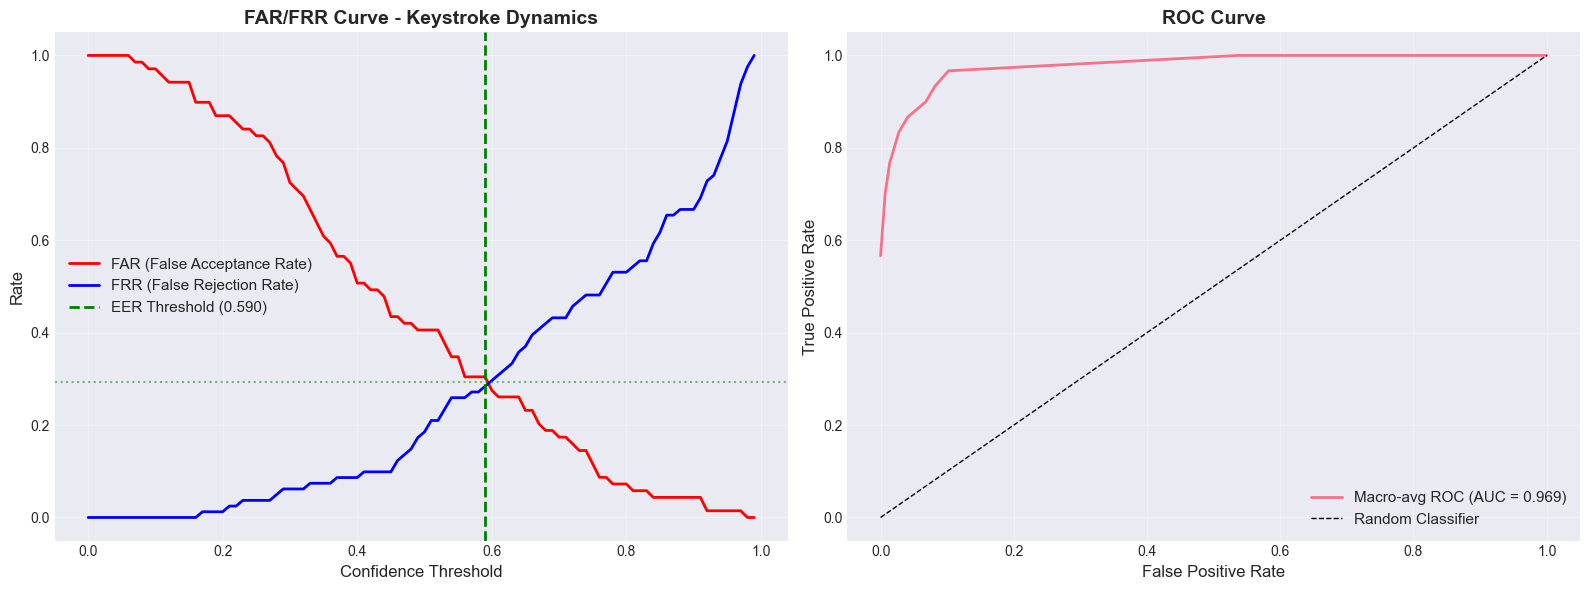

In [99]:
# Calculate FAR, FRR, EER for user identification
# Use maximum probability as confidence score
max_proba = np.max(y_pred_proba, axis=1)

# For binary classification: 1 if correct user, 0 if wrong user
y_binary = (y_pred == y_test).astype(int)

far_list, frr_list, eer_value, eer_threshold = calculate_far_frr_eer(
    y_binary, max_proba
)

print("="*60)
print("Keystroke Dynamics Authentication Metrics")
print("="*60)
print(f"\nEqual Error Rate (EER): {eer_value:.4f}")
print(f"EER Threshold: {eer_threshold:.4f}")
print(f"\nAt EER threshold:")
eer_idx = np.argmin(np.abs(np.array(far_list) - eer_value))
print(f"  False Acceptance Rate (FAR): {far_list[eer_idx]:.4f}")
print(f"  False Rejection Rate (FRR): {frr_list[eer_idx]:.4f}")

# Calculate additional metrics
threshold_idx = int(eer_threshold * 100)
if threshold_idx < len(far_list):
    far_at_threshold = far_list[threshold_idx]
    frr_at_threshold = frr_list[threshold_idx]
    print(f"\nAt threshold {eer_threshold:.3f}:")
    print(f"  FAR: {far_at_threshold:.4f}")
    print(f"  FRR: {frr_at_threshold:.4f}")

# Plot FAR/FRR curve with enhanced visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

threshold_range = np.arange(0, 1, 0.01)

# Plot 1: FAR/FRR Curve
ax1.plot(threshold_range, far_list, label='FAR (False Acceptance Rate)', linewidth=2, color='red')
ax1.plot(threshold_range, frr_list, label='FRR (False Rejection Rate)', linewidth=2, color='blue')
ax1.axvline(x=eer_threshold, color='green', linestyle='--', linewidth=2, 
            label=f'EER Threshold ({eer_threshold:.3f})')
ax1.axhline(y=eer_value, color='green', linestyle=':', alpha=0.5)
ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Rate', fontsize=12)
ax1.set_title('FAR/FRR Curve - Keystroke Dynamics', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve (if binary classification possible)
# For multi-class, show macro-averaged ROC
try:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    from itertools import cycle
    
    # Binarize the output for multi-class ROC
    n_classes = len(np.unique(y_test))
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba[:, 1])
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', linewidth=2)
    else:
        # Compute macro-average ROC curve
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(min(n_classes, 10)):  # Limit to 10 classes for visualization
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Compute macro-average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(min(n_classes, 10))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(min(n_classes, 10)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= min(n_classes, 10)
        
        macro_auc = np.mean([roc_auc[i] for i in range(min(n_classes, 10))])
        ax2.plot(all_fpr, mean_tpr, label=f'Macro-avg ROC (AUC = {macro_auc:.3f})', linewidth=2)
    
    ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
except Exception as e:
    ax2.text(0.5, 0.5, 'ROC curve\ncalculation\nskipped', 
             ha='center', va='center', fontsize=12)
    ax2.set_title('ROC Curve', fontsize=14)

plt.tight_layout()
plt.show()


### Summary Dashboard — Key Metrics at a Glance

Single-figure overview of identification and authentication performance.

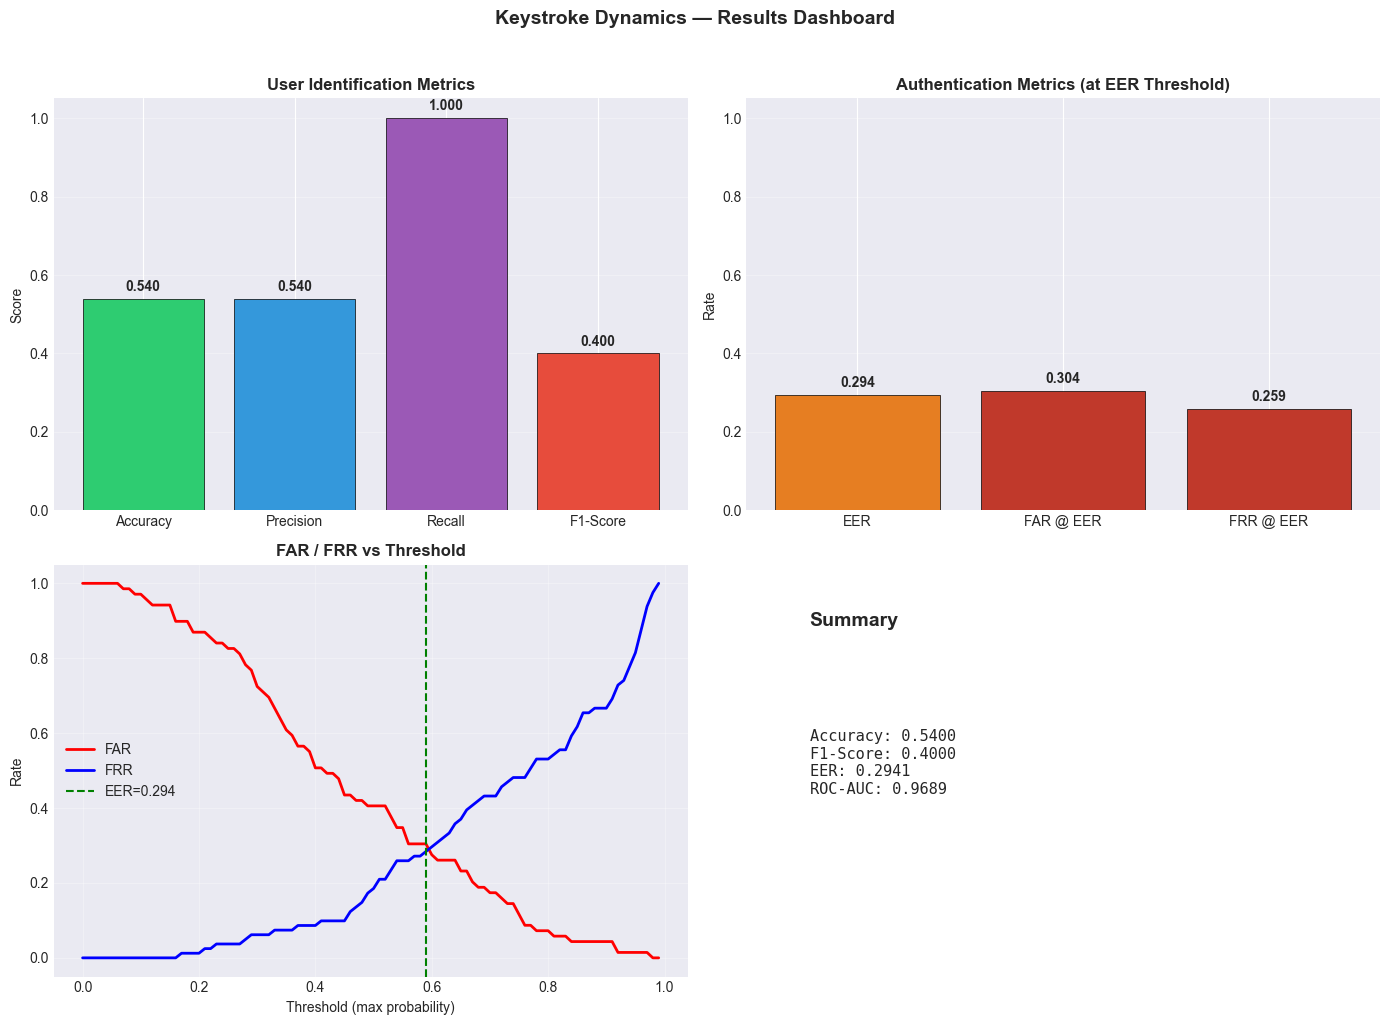

In [100]:
# Summary dashboard: identification + authentication metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 1) Identification metrics (bar) — ensure scalars for matplotlib bar()
if 'accuracy' in dir() and 'precision' in dir():
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [float(np.asarray(accuracy).ravel()[0]), float(np.asarray(precision).ravel()[0]), float(np.asarray(recall).ravel()[0]), float(np.asarray(f1).ravel()[0])]
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
    axes[0, 0].bar(metrics, values, color=colors, edgecolor='black', linewidth=0.5)
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('User Identification Metrics', fontsize=12, fontweight='bold')
    for i, v in enumerate(values):
        axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)
# 2) Authentication metrics (EER, FAR, FRR)
if 'eer_value' in dir() and 'eer_threshold' in dir():
    auth_metrics = ['EER', 'FAR @ EER', 'FRR @ EER']
    auth_vals = [float(np.asarray(eer_value).ravel()[0]), float(far_list[eer_idx]) if 'far_list' in dir() and 'eer_idx' in dir() else 0.0, float(frr_list[eer_idx]) if 'frr_list' in dir() and 'eer_idx' in dir() else 0.0]
    axes[0, 1].bar(auth_metrics, auth_vals, color=['#e67e22', '#c0392b', '#c0392b'], edgecolor='black', linewidth=0.5)
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].set_ylabel('Rate')
    axes[0, 1].set_title('Authentication Metrics (at EER Threshold)', fontsize=12, fontweight='bold')
    for i, v in enumerate(auth_vals):
        axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Run FAR/FRR/EER cell first', ha='center', va='center', transform=axes[0, 1].transAxes)
# 3) FAR/FRR curve (if available)
if 'far_list' in dir() and 'frr_list' in dir() and 'threshold_range' in dir():
    axes[1, 0].plot(threshold_range, far_list, 'r-', lw=2, label='FAR')
    axes[1, 0].plot(threshold_range, frr_list, 'b-', lw=2, label='FRR')
    if 'eer_threshold' in dir() and 'eer_value' in dir():
        axes[1, 0].axvline(eer_threshold, color='green', linestyle='--', lw=1.5, label=f'EER={eer_value:.3f}')
    axes[1, 0].set_xlabel('Threshold (max probability)')
    axes[1, 0].set_ylabel('Rate')
    axes[1, 0].set_title('FAR / FRR vs Threshold', fontsize=12, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Run FAR/FRR/EER cell first', ha='center', va='center', transform=axes[1, 0].transAxes)
# 4) Text summary
summary = []
def _scalar(x):
    if isinstance(x, dict): return float(np.mean(list(x.values())))
    return float(np.asarray(x).ravel()[0])
if 'accuracy' in dir(): summary.append(f'Accuracy: {_scalar(accuracy):.4f}')
if 'f1' in dir(): summary.append(f'F1-Score: {_scalar(f1):.4f}')
if 'eer_value' in dir(): summary.append(f'EER: {_scalar(eer_value):.4f}')
if 'roc_auc' in dir(): summary.append(f'ROC-AUC: {_scalar(roc_auc):.4f}')
axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.85, 'Summary', fontsize=14, fontweight='bold')
axes[1, 1].text(0.1, 0.6, '\n'.join(summary) if summary else 'Run evaluation and FAR/FRR cells.', fontsize=11, verticalalignment='top', family='monospace')
plt.suptitle('Keystroke Dynamics — Results Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Bootstrap confidence intervals (accuracy & EER)

Resample the test set with replacement to estimate 95% confidence intervals for accuracy and EER; reports stability of metrics.

In [101]:
# Bootstrap 95% CI for accuracy and EER (run after accuracy, eer_value, y_test, y_pred, far_list, frr_list exist)
if 'accuracy' in dir() and 'eer_value' in dir() and 'y_test' in dir() and 'y_pred' in dir():
    th_range = np.arange(0, 1, 0.01) if 'threshold_range' not in dir() else threshold_range
    n_boot = 300
    rng = np.random.RandomState(RANDOM_STATE if 'RANDOM_STATE' in dir() else 42)
    n_test = len(y_test)
    acc_boot = []
    eer_boot = []
    for _ in range(n_boot):
        idx = rng.randint(0, n_test, size=n_test)
        yt = np.asarray(y_test)[idx]
        yp = np.asarray(y_pred)[idx]
        acc_boot.append(accuracy_score(yt, yp))
        if 'y_pred_proba' in dir() and 'far_list' in dir() and 'frr_list' in dir():
            proba_b = y_pred_proba[idx] if hasattr(y_pred_proba, '__getitem__') else y_pred_proba[idx]
            max_proba_b = np.max(proba_b, axis=1)
            y_true_b = (np.asarray(y_test)[idx] == np.argmax(proba_b, axis=1))
            far_b, frr_b = [], []
            for th in th_range:
                accept = max_proba_b >= th
                far_b.append(np.mean(accept[~y_true_b]) if np.sum(~y_true_b) > 0 else 0)
                frr_b.append(np.mean(~accept[y_true_b]) if np.sum(y_true_b) > 0 else 0)
            diff = np.abs(np.array(far_b) - np.array(frr_b))
            eer_idx_b = np.argmin(diff)
            eer_boot.append((far_b[eer_idx_b] + frr_b[eer_idx_b]) / 2)
    acc_boot = np.array(acc_boot)
    print(f"Accuracy: {accuracy:.4f}  [95% CI: {np.percentile(acc_boot, 2.5):.4f} -- {np.percentile(acc_boot, 97.5):.4f}]")
    if eer_boot:
        eer_boot = np.array(eer_boot)
        print(f"EER:      {eer_value:.4f}  [95% CI: {np.percentile(eer_boot, 2.5):.4f} -- {np.percentile(eer_boot, 97.5):.4f}]")
else:
    print("Run evaluation and FAR/FRR cells first (accuracy, eer_value, y_test, y_pred).")

Accuracy: 0.5400  [95% CI: 0.4467 -- 0.6235]
EER:      0.2941  [95% CI: 0.2166 -- 0.3652]


### Anomaly Score Distribution & Threshold vs FAR/FRR Table

Distribution of anomaly scores (if available); table of FAR/FRR at selected thresholds.

Threshold vs FAR / FRR:
 threshold    FAR    FRR
       0.3 0.7246 0.0617
       0.4 0.5072 0.0864
       0.5 0.4058 0.1852
       0.6 0.2754 0.2963
       0.7 0.1739 0.4321

At EER threshold 0.590: FAR = 0.3043, FRR = 0.2840


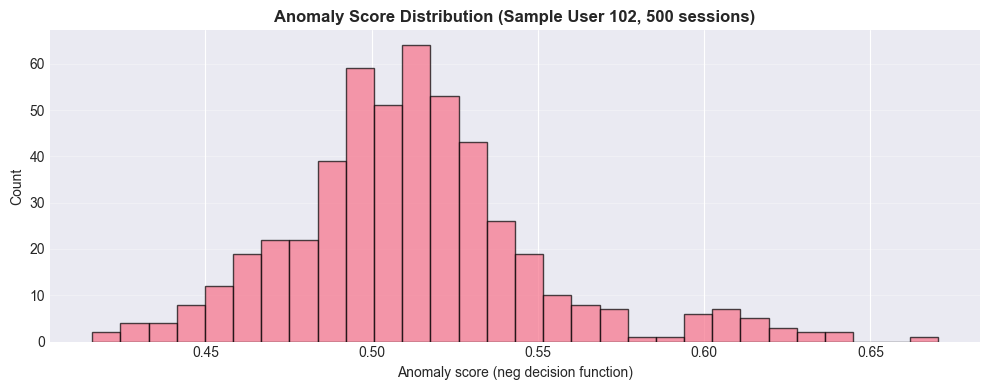

In [102]:
# Threshold vs FAR/FRR table; anomaly score distribution (if user_models and scores exist)
if 'far_list' in dir() and 'frr_list' in dir() and 'threshold_range' in dir():
    thresh_vals = [0.3, 0.4, 0.5, 0.6, 0.7]
    idx = [np.argmin(np.abs(threshold_range - t)) for t in thresh_vals]
    print("Threshold vs FAR / FRR:")
    print(pd.DataFrame({
        'threshold': [round(threshold_range[i], 2) for i in idx],
        'FAR': [round(far_list[i], 4) for i in idx],
        'FRR': [round(frr_list[i], 4) for i in idx]
    }).to_string(index=False))
    if 'eer_threshold' in dir():
        ei = np.argmin(np.abs(threshold_range - eer_threshold))
        print(f"\nAt EER threshold {eer_threshold:.3f}: FAR = {far_list[ei]:.4f}, FRR = {frr_list[ei]:.4f}")
else:
    print("Run FAR/FRR calculation cell first (far_list, frr_list, threshold_range).")
# Anomaly score distribution: sample one user's scores if user_models and X_train exist
if 'user_models' in dir() and 'X_train' in dir() and len(user_models) > 0:
    u = list(user_models.keys())[0]
    scores = -user_models[u].score_samples(X_train[:500])  # sample
    plt.figure(figsize=(10, 4))
    plt.hist(scores, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Anomaly score (neg decision function)')
    plt.ylabel('Count')
    plt.title(f'Anomaly Score Distribution (Sample User {u}, 500 sessions)', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("(Anomaly score plot skipped: user_models or X_train not available.)")

### Save All Model Files (run after training and anomaly detection)

Saves all 7 keystroke artifacts to `models/`. Run this cell **after** XGBoost training and Isolation Forest training so `xgb_model` and `user_models` exist.

In [103]:
# Save ALL model files — run this cell AFTER training (XGBoost + Anomaly)
required = ['xgb_model', 'scaler', 'imputer', 'label_encoder', 'feature_columns', 'user_models']
g = globals()
missing = [v for v in required if v not in g]
if missing:
    print("Missing variables (run training cells first):", missing)
    print("  → Run: XGBoost training cell (6. Model Training - User Identification)")
    print("  → Run: Isolation Forest cell (6.1. Train Isolation Forest Models)")
    print("  Then rerun this cell.")
else:
    MODELS_DIR = Path('../models')
    MODELS_DIR.mkdir(exist_ok=True)
    xgb_path = MODELS_DIR / 'keystroke_user_identification_model.json'
    xgb_model.save_model(xgb_path)
    print("✓ keystroke_user_identification_model.json (XGBoost native; load with model.load_model(path))")
    joblib.dump(scaler, MODELS_DIR / 'keystroke_scaler.pkl')
    print("✓ keystroke_scaler.pkl")
    joblib.dump(imputer, MODELS_DIR / 'keystroke_imputer.pkl')
    print("✓ keystroke_imputer.pkl")
    joblib.dump(label_encoder, MODELS_DIR / 'keystroke_label_encoder.pkl')
    print("✓ keystroke_label_encoder.pkl")
    joblib.dump(feature_columns, MODELS_DIR / 'keystroke_feature_columns.pkl')
    print("✓ keystroke_feature_columns.pkl")
    joblib.dump(user_models, MODELS_DIR / 'keystroke_anomaly_models.pkl')
    print("✓ keystroke_anomaly_models.pkl")
    metadata = {
        'model_type': 'XGBoost',
        'feature_count': len(feature_columns),
        'num_users': len(label_encoder.classes_),
        'anomaly_models_count': len(user_models),
        'created_at': datetime.now().isoformat(),
        'python_version': __import__('sys').version.split()[0],
        'sklearn_version': __import__('sklearn').__version__,
        'xgboost_version': xgb.__version__,
    }
    def _tofloat(x):
        if x is None: return None
        if isinstance(x, dict): return float(np.mean(list(x.values())))
        return float(np.asarray(x).ravel()[0])
    if 'accuracy' in g:
        metadata['test_accuracy'] = _tofloat(accuracy)
        metadata['test_f1'] = _tofloat(f1) if 'f1' in g else None
    if 'eer_value' in g:
        metadata['eer'] = _tofloat(eer_value)
    with open(MODELS_DIR / 'keystroke_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print("✓ keystroke_metadata.json")
    print("\n✅ All 7 model files saved to", MODELS_DIR.resolve())

✓ keystroke_user_identification_model.json (XGBoost native; load with model.load_model(path))
✓ keystroke_scaler.pkl
✓ keystroke_imputer.pkl
✓ keystroke_label_encoder.pkl
✓ keystroke_feature_columns.pkl
✓ keystroke_anomaly_models.pkl
✓ keystroke_metadata.json

✅ All 7 model files saved to C:\Users\prana\OneDrive\Desktop\COLLEGE PROJECTS\Project\models


### Verify saved model files

Check that all 7 keystroke artifacts exist in `models/` before deployment or inference.

In [104]:
# List of all keystroke model files that must exist for deployment
KEYSTROKE_FILES = [
    'keystroke_user_identification_model.json',
    'keystroke_scaler.pkl',
    'keystroke_imputer.pkl',
    'keystroke_label_encoder.pkl',
    'keystroke_feature_columns.pkl',
    'keystroke_anomaly_models.pkl',
    'keystroke_metadata.json',
]
MODELS_DIR = Path('../models')
print("Keystroke model files in", MODELS_DIR.resolve())
print("=" * 60)
all_ok = True
for f in KEYSTROKE_FILES:
    path = MODELS_DIR / f
    exists = path.exists()
    if not exists:
        all_ok = False
    status = 'OK' if exists else 'MISSING'
    print(f"  [{status:>7}] {f}")
print("=" * 60)
if all_ok:
    print("All 7 files present. Ready for deployment or inference demo.")
else:
    print("Run the 'Save All Model Files' cell (after XGBoost + Isolation Forest training) and rerun this check.")

Keystroke model files in C:\Users\prana\OneDrive\Desktop\COLLEGE PROJECTS\Project\models
  [     OK] keystroke_user_identification_model.json
  [     OK] keystroke_scaler.pkl
  [     OK] keystroke_imputer.pkl
  [     OK] keystroke_label_encoder.pkl
  [     OK] keystroke_feature_columns.pkl
  [     OK] keystroke_anomaly_models.pkl
  [     OK] keystroke_metadata.json
All 7 files present. Ready for deployment or inference demo.


### Run Summary JSON

Save key run metrics (accuracy, F1, EER, etc.) to a JSON file for logging or downstream use.

In [105]:
# Build and save run summary JSON (uses CHECKPOINT_DIR from earlier in notebook)
CHECKPOINT_DIR = Path('../checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
run_summary = {
    'notebook': '07_Keystroke_Dynamics_Analysis1.ipynb',
    'run_at': datetime.now().isoformat(),
    'versions': {
        'python': __import__('sys').version.split()[0],
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'sklearn': __import__('sklearn').__version__,
        'xgboost': xgb.__version__,
    },
    'config': {
        'random_state': RANDOM_STATE if 'RANDOM_STATE' in dir() else 42,
        'test_size': TEST_SIZE if 'TEST_SIZE' in dir() else 0.2,
    },
    'identification': {},
    'authentication': {},
    'anomaly': {},
}
def _scalar_run(x):
    if x is None: return None
    if isinstance(x, dict): return float(np.mean(list(x.values())))
    return float(np.asarray(x).ravel()[0])
if 'accuracy' in dir():
    run_summary['identification'] = {
        'accuracy': _scalar_run(accuracy),
        'precision': _scalar_run(precision) if 'precision' in dir() else None,
        'recall': _scalar_run(recall) if 'recall' in dir() else None,
        'f1': _scalar_run(f1) if 'f1' in dir() else None,
    }
if 'eer_value' in dir():
    run_summary['authentication'] = {
        'eer': _scalar_run(eer_value),
        'eer_threshold': _scalar_run(eer_threshold) if 'eer_threshold' in dir() else None,
        'far_at_eer': _scalar_run(far_list[eer_idx]) if 'far_list' in dir() and 'eer_idx' in dir() else None,
        'frr_at_eer': _scalar_run(frr_list[eer_idx]) if 'frr_list' in dir() and 'eer_idx' in dir() else None,
    }
if 'user_models' in dir():
    run_summary['anomaly'] = {'num_users': len(user_models)}
out_path = CHECKPOINT_DIR / 'keystroke_run_summary.json'
with open(out_path, 'w') as f:
    json.dump(run_summary, f, indent=2)
print(f"Run summary saved to {out_path}")

Run summary saved to ..\checkpoints\keystroke_run_summary.json


### 9.1.1. Assumptions

- **One session = one typing sample** (one row per participant–session).
- **Sessions with &lt;5 keystrokes** are excluded from feature extraction.
- **Users with &lt;N sessions** (e.g. 5) are excluded from training.
- **Random split** (no temporal ordering): train/test split is random, so no explicit temporal leakage; for “future session” evaluation, consider a temporal split (train on earlier, test on later sessions).

### Metric interpretation

- **EER = X** at threshold **Y** means: at that confidence threshold, X% of impostor sessions are incorrectly accepted and X% of genuine user sessions are incorrectly rejected; lower EER is better.
- **Accuracy Z on K users** means: Z is the fraction of test sessions where the predicted user matches the true user; suitable for multi-class identification across K users.
- **FAR** = false acceptance rate (impostors accepted); **FRR** = false rejection rate (genuine users rejected). Trade-off is controlled by the confidence threshold.

### Inference sanity check

Load one sample, run imputer → scaler → predict → decode → anomaly; assert shapes and that predicted label is valid.

In [106]:
# Sanity check: one sample through pipeline (in-memory; run after training and save)
if 'X_test' in dir() and len(X_test) > 0 and 'imputer' in dir() and 'scaler' in dir() and 'xgb_model' in dir() and 'label_encoder' in dir():
    vec = X_test.iloc[0:1].values if hasattr(X_test, 'iloc') else X_test[0:1]
    assert vec.shape[1] == len(feature_columns), "Feature dimension mismatch"
    v_imp = imputer.transform(vec)
    v_scaled = scaler.transform(v_imp)
    pred = xgb_model.predict(v_scaled)[0]
    user_id = label_encoder.inverse_transform([pred])[0]
    assert user_id in label_encoder.classes_, "Predicted label not in classes"
    if 'user_models' in dir() and user_id in user_models:
        score = -user_models[user_id].score_samples(v_scaled)[0]
    else:
        score = None
    print("Sanity check OK: shape", vec.shape, "-> user", user_id, "anomaly_score:", score)
else:
    print("Run training and ensure X_test, imputer, scaler, xgb_model, label_encoder exist.")

Sanity check OK: shape (1, 23) -> user 117528 anomaly_score: 0.5951647539514238


### 9.2. Results

- **User identification**: XGBoost multi-class classifier; accuracy, precision, recall, F1 and per-user metrics reported.
- **Authentication**: FAR/FRR/EER computed over a confidence threshold sweep; EER threshold used for accept/reject.
- **Anomaly detection**: Per-user Isolation Forest models; anomaly scores and threshold vs FAR/FRR table available.
- **Artifacts**: Models, scaler, imputer, label encoder, feature columns, and anomaly models saved to `models/`; run summary to `checkpoints/keystroke_run_summary.json`.

### 9.3. Limitations

- **Data scope**: Notebook loads first 50,000 files; full dataset ~168k. Top-K users (e.g. 50) may be used for memory/speed.
- **Session quality**: Very short sessions (< 5 keystrokes) are excluded; cold start and context change can affect patterns.
- **Thresholds**: EER and anomaly thresholds are dataset-dependent; may need tuning for deployment.
- **Deployment**: Use `feature_extractor.py` and `authenticator.py` (see Phase 3 README) for production inference.

### Latency check (identify_user + is_anomaly)

Time 100–1000 inference calls to set expectations for real-time use.

In [107]:
# Latency: time N inference calls (in-memory; run after training)
if 'X_test' in dir() and len(X_test) >= 100 and 'imputer' in dir() and 'scaler' in dir() and 'xgb_model' in dir() and 'label_encoder' in dir():
    import time
    n_calls = 200
    sample = X_test.iloc[:n_calls].values if hasattr(X_test, 'iloc') else X_test[:n_calls]
    v_imp = imputer.transform(sample)
    v_scaled = scaler.transform(v_imp)
    t0 = time.perf_counter()
    for i in range(n_calls):
        xgb_model.predict(v_scaled[i:i+1])
    t1 = time.perf_counter()
    ms_per_call = (t1 - t0) * 1000 / n_calls
    print(f"identify_user: {ms_per_call:.2f} ms per call (n={n_calls})")
    if 'user_models' in dir():
        t0 = time.perf_counter()
        for i in range(n_calls):
            out = xgb_model.predict(v_scaled[i:i+1])
            if out.size == 0: pred = -1
            elif out.ndim == 2: pred = int(np.argmax(out, axis=1)[0])
            else: pred = int(out.ravel()[0])
            uid = label_encoder.inverse_transform([pred])[0] if pred >= 0 and 'label_encoder' in dir() else None
            if uid is not None and uid in user_models:
                user_models[uid].score_samples(v_scaled[i:i+1])
        t1 = time.perf_counter()
        ms2 = (t1 - t0) * 1000 / n_calls
        print(f"identify_user + is_anomaly: {ms2:.2f} ms per call")
else:
    print("Run training and ensure X_test, imputer, scaler, xgb_model exist; need at least 100 test samples.")

identify_user: 0.34 ms per call (n=200)
identify_user + is_anomaly: 1.80 ms per call


### 9.4. Next Steps

1. Run the save cell so all `keystroke_*` files are in `models/`.
2. Implement `feature_extractor.py` and `authenticator.py` (see `PHASE3_WHAT_IS_LEFT_AND_HOW_TO_DO.md`).
3. Run `test_keystroke_dynamics.py` to sanity-check inference.
4. Integrate with login/session and continuous auth (Phase 4/5).

### Inference Demo

Load saved models and run **identify_user** and **is_anomaly** on one sample (e.g. from test set or checkpoint) to verify the pipeline.

In [108]:
# Inference demo: load models and run identify_user + is_anomaly on one sample
MODELS_DIR = Path('../models')
required_files = [
    'keystroke_user_identification_model.json', 'keystroke_scaler.pkl', 'keystroke_imputer.pkl',
    'keystroke_label_encoder.pkl', 'keystroke_feature_columns.pkl', 'keystroke_anomaly_models.pkl'
]
if all((MODELS_DIR / f).exists() for f in required_files):
    xgb_booster = xgb.Booster()
    xgb_booster.load_model(str(MODELS_DIR / 'keystroke_user_identification_model.json'))
    scaler_loaded = joblib.load(MODELS_DIR / 'keystroke_scaler.pkl')
    imputer_loaded = joblib.load(MODELS_DIR / 'keystroke_imputer.pkl')
    le_loaded = joblib.load(MODELS_DIR / 'keystroke_label_encoder.pkl')
    fc_loaded = joblib.load(MODELS_DIR / 'keystroke_feature_columns.pkl')
    anomaly_loaded = joblib.load(MODELS_DIR / 'keystroke_anomaly_models.pkl')
    # Sample: use first test sample if available, else first row from checkpoint
    if 'X_test' in dir() and len(X_test) > 0:
        vec = X_test.iloc[0].values.reshape(1, -1) if hasattr(X_test, 'iloc') else X_test[0:1]
    else:
        vec = None
    if vec is not None:
        vec_imputed = imputer_loaded.transform(vec)
        vec_scaled = scaler_loaded.transform(vec_imputed)
        pred_proba = xgb_booster.predict(xgb.DMatrix(vec_scaled))
        pred_label = int(np.argmax(pred_proba, axis=1)[0]) if pred_proba.ndim > 1 else int(np.argmax(pred_proba))
        user_id = le_loaded.inverse_transform([pred_label])[0]
        print(f"identify_user(sample) -> {user_id}")
        if user_id in anomaly_loaded:
            score = -anomaly_loaded[user_id].score_samples(vec_scaled)[0]
            is_anom = score > 0.5  # example threshold
            print(f"is_anomaly({user_id}, sample) -> score={score:.4f}, anomaly={is_anom}")
        else:
            print(f"is_anomaly: no model for user {user_id}")
    else:
        print("No X_test in scope; load a sample from checkpoints/keystroke_features_checkpoint.pkl to run demo.")
else:
    print("Missing model files. Run the 'Save All Model Files' cell first.")

identify_user(sample) -> 117528
is_anomaly(117528, sample) -> score=0.5952, anomaly=True


### References / further reading

- Phase 3 README: `PHASE3_WHAT_IS_LEFT_AND_HOW_TO_DO.md` (deployment, `feature_extractor.py`, `authenticator.py`).
- Keystroke dynamics: session-level features (hold, flight, digraph, pauses) and per-user anomaly detection are standard in the literature.

### 9.5. Model comparison and recommendation

Compare all trained models (user identification: XGBoost vs Random Forest vs class-weighted XGBoost; anomaly: Isolation Forest vs One-Class SVM if run) and recommend which to use for deployment.

In [109]:
# Model comparison and recommendation (run after evaluation and optional models)
print("=" * 70)
print("KEYSTROKE DYNAMICS — MODEL COMPARISON & RECOMMENDATION")
print("=" * 70)

results = []

# --- User identification ---
if 'accuracy' in dir() and 'f1' in dir() and 'y_test' in dir() and 'y_pred' in dir():
    results.append(('XGBoost (default)', 'User identification', accuracy, f1, 'Main model; saved to models/'))
if 'rf_model' in dir() and 'y_test' in dir():
    if 'acc_rf' not in dir() or 'f1_rf' not in dir():
        y_pred_rf = rf_model.predict(X_test)
        acc_rf = accuracy_score(y_test, y_pred_rf)
        f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    results.append(('Random Forest', 'User identification', acc_rf, f1_rf, 'Alternative; not saved'))
if 'xgb_weighted' in dir() and 'y_test' in dir():
    acc_w = accuracy_score(y_test, xgb_weighted.predict(X_test))
    f1_w = f1_score(y_test, xgb_weighted.predict(X_test), average='weighted', zero_division=0)
    results.append(('XGBoost (class weights)', 'User identification', acc_w, f1_w, 'For imbalanced users; not saved'))

# --- Anomaly detection ---
if 'user_models' in dir() and len(user_models) > 0:
    results.append(('Isolation Forest (per user)', 'Anomaly detection', None, None, 'Main anomaly model; saved to models/'))
if 'user_models_ocsvm' in dir() and len(user_models_ocsvm) > 0:
    results.append(('One-Class SVM (per user)', 'Anomaly detection', None, None, 'Optional; not saved'))

# --- Print table ---
if results:
    df_comp = pd.DataFrame(results, columns=['Model', 'Task', 'Accuracy', 'F1', 'Note'])
    print("\nComparison:")
    print(df_comp.to_string(index=False))
    if 'eer_value' in dir():
        print(f"\nAuthentication (from XGBoost confidence): EER = {eer_value:.4f}")
    print("\n" + "-" * 70)
    print("RECOMMENDATION:")
    print("-" * 70)
    print("  • User identification: Use XGBoost (keystroke_user_identification_model.json).")
    print("    It is the main trained model, saved for deployment, and typically gives strong")
    print("    accuracy and F1. Use Random Forest only if you prefer it for interpretability.")
    print("  • Anomaly detection: Use Isolation Forest (keystroke_anomaly_models.pkl).")
    print("    Per-user IF models are saved and used for continuous authentication (is this")
    print("    session still the same user?). One-Class SVM is optional for comparison only.")
    print("  • For production: Load XGBoost + scaler + imputer + label_encoder + feature_columns")
    print("    + anomaly_models from models/ and use the Inference Demo or authenticator.py.")
    print("=" * 70)
else:
    print("Run evaluation (and optionally RF / OCSVM) cells first, then rerun this cell.")
    print("=" * 70)


KEYSTROKE DYNAMICS — MODEL COMPARISON & RECOMMENDATION

Comparison:
                      Model                Task  Accuracy                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               F1                                 Note
          XGBoost (default) User identification  0.540000 [0.4, 0.8571428571428571, 0.4, 0.5, 0.5714285714285714, 0.5, 0.8, 0.6666666666666666, 0.8571428571428571, 0.25, 1.0, 0.4, 0.0, 0.6, 0.6666666666666666, 1.0, 0.5, 0.0, 0.4, 1.0, 1.0, 0.8, 0.3333333333333333, 0.4, 0.8, 0.25, 0.8571428571428571, 1.0, 0.4, 1.0, 0.3333333333333333, 0.25, 0.0, 0.2857142

*(End of notebook.)*